In [20]:
import sys
sys.path.append("/home/eigenlicht/projects/nano/carbendazim/spek")
from orca_praser import ORCAParser, ORCABatchParser, parse_orca_file, parse_orca_batch

df, states = parse_orca_batch("*.out")

Found files: 103
Parsed: CO2s0.out -> CO2
Parsed: EIZB2.out -> EIZB2
Parsed: H2CO3s0.out -> H2CO3


*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is orca coords)



Parsed: H2Os0.out -> H2O
Parsed: HCO3s0.out -> HCO3
Parsed: HOMes0.out -> HOMe
Parsed: OHs0.out -> OH
Parsed: OMes0.out -> OMe
Parsed: p1as0.out -> p1a
Parsed: p1as0p.out -> p1a
Parsed: p1avg.out -> p1a
Parsed: p1bs0.out -> p1b
Parsed: p1bs0p.out -> p1b
Parsed: p1bvg.out -> p1b
Parsed: p1cs0.out -> p1c
Parsed: p1cs0p.out -> p1c
Parsed: p1cvg.out -> p1c
Parsed: p1ds0.out -> p1d
Parsed: p1ds0p.out -> p1d
Parsed: p1dvg.out -> p1d
Parsed: p1xs0.out -> p1x
Parsed: p1xs0p.out -> p1x
Parsed: p1xvg.out -> p1x
Parsed: p2as0.out -> p2a
Parsed: p2as0p.out -> p2a
Parsed: p2avg.out -> p2a
Parsed: p2bs0.out -> p2b
Parsed: p2bs0p.out -> p2b
Parsed: p2bvg.out -> p2b
Parsed: p2cs0.out -> p2c
Parsed: p2cs0p.out -> p2c
Parsed: p2cvg.out -> p2c
Parsed: p2ds0.out -> p2d
Parsed: p2ds0p.out -> p2d
Parsed: p2dvg.out -> p2d
Parsed: p2xs0.out -> p2x
Parsed: p2xs0p.out -> p2x
Parsed: p2xvg.out -> p2x
Parsed: p3as0.out -> p3a
Parsed: p3as0p.out -> p3a
Parsed: p3avg.out -> p3a
Parsed: p3bs0.out -> p3b
Parsed: p3bs

In [21]:
df.loc[df["molecule_id"] == "p1x"].iloc[0].keys()


Index(['molecule_id', 'energies', 'orbitals', 'geometries', 'internal_coords',
       'smiles', 'cart_coords', 'geometry', 'vibrations', 'ir_spectrum',
       'raman_spectrum', 'nmr_data', 'mulliken_charges', 'tddft_states',
       'electric_dipole_spectrum', 'velocity_dipole_spectrum', 'spectrum_file',
       'internal'],
      dtype='object')

In [22]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from typing import List, Optional, Union
import pandas as pd


def plot_molecule_grid(
    df: pd.DataFrame,
    datasets: Union[List[str], List[List[str]]],
    labels_input: Optional[Union[List[str], List[List[str]]]] = None,
    align_core: Optional[str] = 'c1cccc2c1[nH]c(n2)N',
    flip_vertical: bool = True,
    mols_per_row: Optional[int] = None,
    img_size: tuple = (250, 250),
    padding: float = 0.02,
    legend_font_size: int = 18,
    bond_line_width: float = 1.5,
    fixed_bond_length: float = 20.0
):
    """
    Plot molecules in a grid with optional alignment and flipping.
    
    Examples:
        plot_molecule_grid(df, ["p1x", "p2x", "p3x"])
        plot_molecule_grid(df, [["p1x", "p2x"], ["p3x", "p4x"]], align_core='c1ccccc1')
        plot_molecule_grid(df, ["p1x", "p2x"], align_core=None)  # no alignment
    """
    
    # Parse datasets structure
    is_grouped = isinstance(datasets[0], list) if datasets else False
    flat_datasets = [item for group in datasets for item in group] if is_grouped else datasets
    mols_per_row = mols_per_row or (max(len(row) for row in datasets) if is_grouped else len(datasets))
    
    # Parse labels
    if labels_input is None:
        labels_flat = flat_datasets[:]
    else:
        is_labels_grouped = isinstance(labels_input[0], list) if labels_input else False
        labels_flat = [item for group in labels_input for item in group] if is_labels_grouped else labels_input[:]
        if len(labels_flat) != len(flat_datasets):
            raise ValueError(f"Label count ({len(labels_flat)}) must match molecule count ({len(flat_datasets)})")
    
    # Prepare molecules
    molecules = []
    final_labels = []
    
    for i, mol_id in enumerate(flat_datasets):
        base_name = mol_id.lstrip("*")
        mask = df["molecule_id"].str.contains(base_name, case=False, na=False, regex=False)
        
        if not mask.any():
            molecules.append(None)
            final_labels.append(labels_flat[i])
            continue
        
        smiles = df[mask].iloc[0].get("smiles")
        mol = Chem.MolFromSmiles(smiles) if smiles and not pd.isna(smiles) else None
        
        if mol:
            AllChem.Compute2DCoords(mol)
        
        molecules.append(mol)
        final_labels.append(labels_flat[i])
    
    # Prepare alignment core
    core = None
    if align_core:
        core = Chem.MolFromSmiles(align_core)
        if core:
            AllChem.Compute2DCoords(core)
    
    # Align and flip molecules
    for mol in molecules:
        if mol is None:
            continue
        
        # Align to core
        if core and mol.HasSubstructMatch(core):
            try:
                AllChem.GenerateDepictionMatching2DStructure(mol, core)
            except:
                pass
        
        # Flip vertically
        if flip_vertical:
            try:
                conf = mol.GetConformer()
                for i in range(mol.GetNumAtoms()):
                    pos = conf.GetAtomPosition(i)
                    conf.SetAtomPosition(i, (pos.x, -pos.y, pos.z))
            except:
                pass
    
    # Configure drawing options
    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.padding = padding
    draw_options.legendFontSize = legend_font_size
    draw_options.bondLineWidth = bond_line_width
    draw_options.fixedBondLength = fixed_bond_length
    draw_options.dummiesAreAttachments = True
    
    # Draw and return
    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=mols_per_row,
        subImgSize=img_size,
        legends=final_labels,
        drawOptions=draw_options
    )

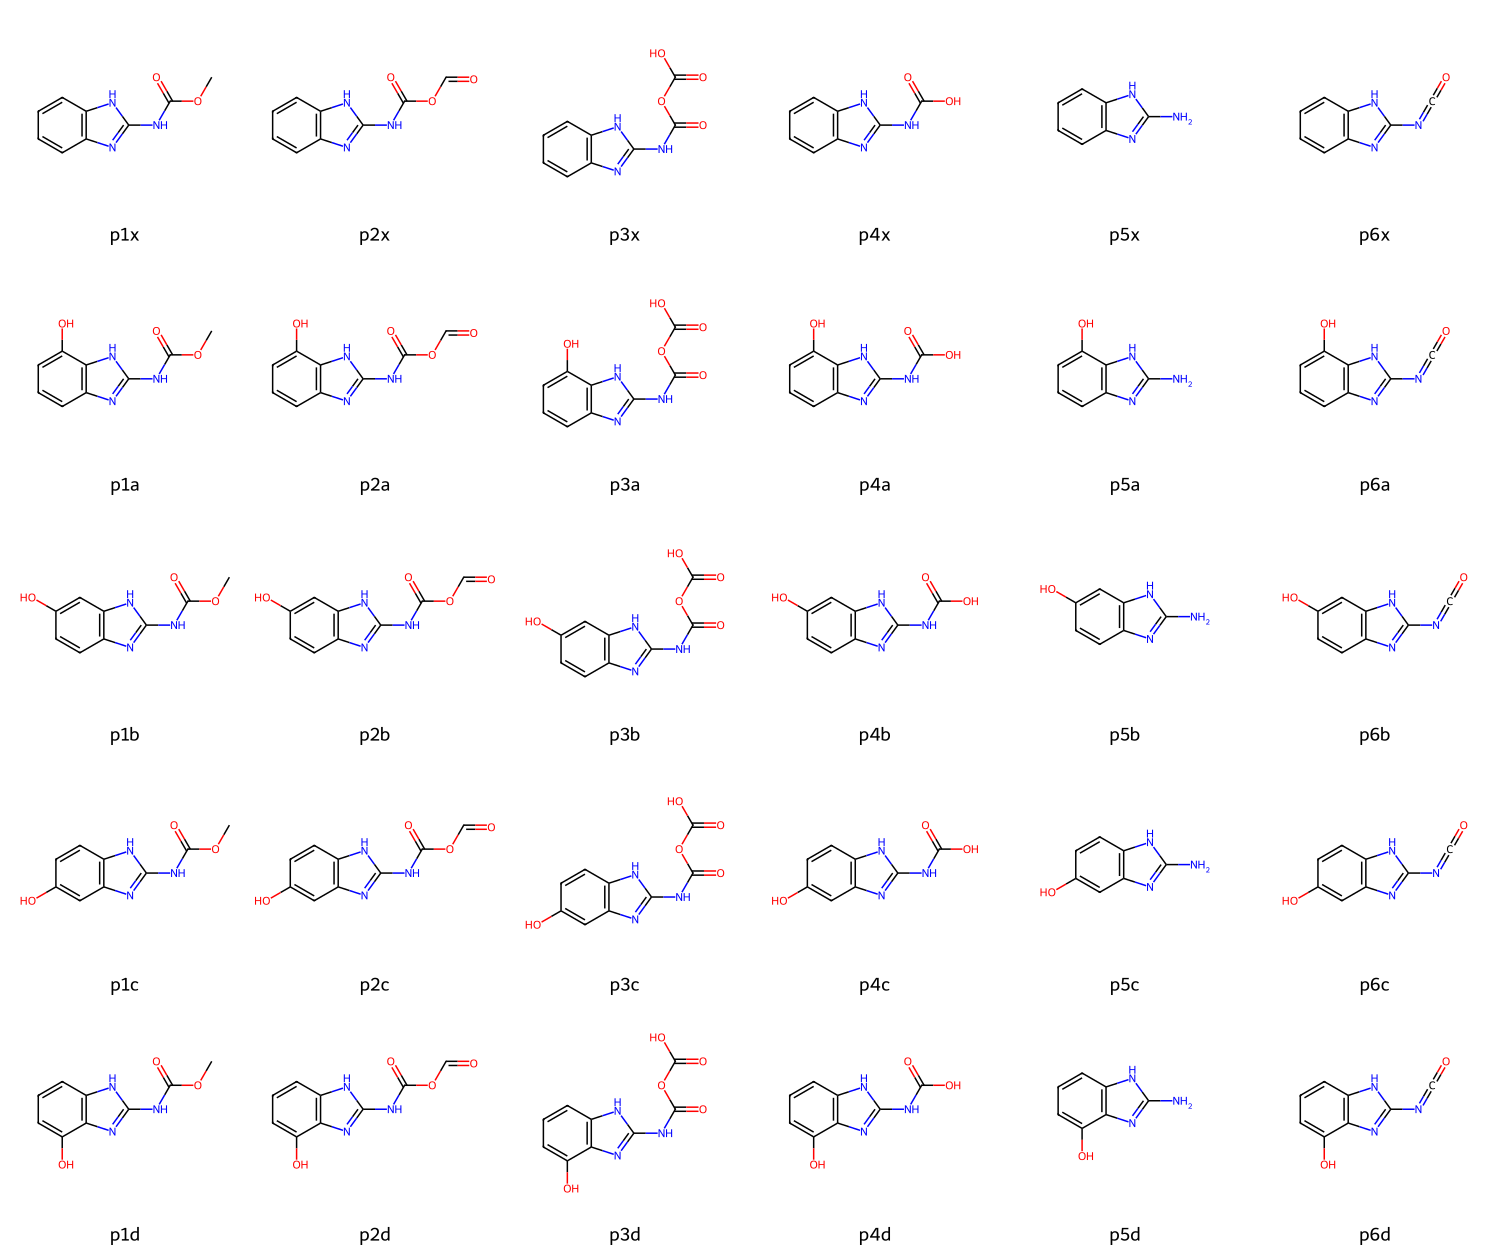

In [23]:
# Flat list
plot_molecule_grid(
    df, 
    [["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"],
     ["p1a", "p2a", "p3a", "p4a", "p5a", "p6a"],
     ["p1b", "p2b", "p3b", "p4b", "p5b", "p6b"],
     ["p1c", "p2c", "p3c", "p4c", "p5c", "p6c"],
     ["p1d", "p2d", "p3d", "p4d", "p5d", "p6d"],],
    align_core='c1cccc2c1[nH]c(n2)N')

In [24]:
import pandas as pd
import re
from typing import List, Optional


def create_internal_coords_comparison_table(
    df: pd.DataFrame,
    molecule_ids: List[str],
    state_key: str = 'S0_OPT',
    coord_filter: str = "BAD",
    coord_types: Optional[List[str]] = None,  # legacy support
    csv: bool = False,
    filename: str = "internal_coords_comparison.csv",
    csv_encoding: str = "utf-8-sig",  # ✅ NEW: Excel-safe default
    atom_indexing: str = 'original'
) -> pd.DataFrame:
    """
    Create a comparison table of internal coordinates across multiple molecules.
    """

    # ---------------------------------------------------------
    # Coordinate filter (B/A/D)
    # ---------------------------------------------------------
    coord_filter = coord_filter.upper()

    filter_map = {'B': 'bonds', 'A': 'angles', 'D': 'dihedrals'}

    if coord_filter in ('ALL', 'BAD'):
        coord_types = ['bonds', 'angles', 'dihedrals']
    else:
        coord_types = []
        for key in coord_filter:
            if key not in filter_map:
                raise ValueError(
                    f"Invalid coord_filter '{coord_filter}'. "
                    "Use B, A, D, combinations, or ALL."
                )
            coord_types.append(filter_map[key])

    # ---------------------------------------------------------
    # Collect molecule data
    # ---------------------------------------------------------
    molecule_data = {}

    for mol_id in molecule_ids:
        mol_row = df[df['molecule_id'] == mol_id]
        if mol_row.empty:
            print(f"Warning: Molecule '{mol_id}' not found")
            molecule_data[mol_id] = []
            continue

        mol = mol_row.iloc[0]

        if state_key not in mol['internal_coords']:
            print(f"Warning: State '{state_key}' not found for '{mol_id}'")
            molecule_data[mol_id] = []
            continue

        internals = mol['internal_coords'][state_key]

        atom_map = None
        if atom_indexing != 'original':
            atom_map = _build_atom_index_map(internals, atom_indexing)

        mol_coords = []

        for coord_type in coord_types:
            if coord_type not in internals:
                continue

            df_coords = internals[coord_type]
            if df_coords.empty:
                continue

            for _, row in df_coords.iterrows():
                name = _standardize_coordinate_name(
                    row['Definition'],
                    row['Atoms'],
                    coord_type,
                    atom_map
                )
                mol_coords.append({
                    'coordinate': name,
                    'value': row['FinalVal']
                })

        molecule_data[mol_id] = mol_coords

    # ---------------------------------------------------------
    # Build wide comparison table
    # ---------------------------------------------------------
    max_len = max(len(v) for v in molecule_data.values()) if molecule_data else 0
    table = {}

    for mol_id in molecule_ids:
        coords = molecule_data.get(mol_id, [])
        names = [c['coordinate'] for c in coords] + [''] * (max_len - len(coords))
        vals = [c['value'] for c in coords] + [None] * (max_len - len(coords))

        table[f'Coordinate_{mol_id}'] = names
        table[mol_id] = vals

    columns = []
    for mol_id in molecule_ids:
        columns += [f'Coordinate_{mol_id}', mol_id]

    result_df = pd.DataFrame(table, columns=columns)

    # ---------------------------------------------------------
    # CSV export (Excel-safe)
    # ---------------------------------------------------------
    if csv:
        result_df.to_csv(
            filename,
            index=False,
            encoding="utf-8-sig",
            sep=";",              # ← IMPORTANT
            decimal=",",          # ← IMPORTANT
        )
        print(f"✓ CSV saved (Excel-safe UTF-8): {filename}")

    return result_df


# =============================================================================
# Helper functions
# =============================================================================

def _build_atom_index_map(internals: dict, indexing_type: str) -> dict:
    atoms = set()

    for ct in ['bonds', 'angles', 'dihedrals']:
        if ct not in internals:
            continue

        for _, row in internals[ct].iterrows():
            m = re.search(r'\((.*?)\)', row['Definition'])
            if not m:
                continue

            for a in m.group(1).split(','):
                ma = re.search(r'([A-Z][a-z]?)\s*(\d+)', a)
                if ma:
                    atoms.add(f"{ma.group(1)}{ma.group(2)}")

    atom_list = sorted(atoms, key=lambda x: int(re.search(r'\d+', x).group()))
    atom_map = {}

    if indexing_type == 'overall':
        for i, a in enumerate(atom_list, 1):
            atom_map[a] = re.sub(r'\d+', str(i), a)

    elif indexing_type == 'by_element':
        counter = {}
        for a in atom_list:
            el = re.match(r'[A-Z][a-z]?', a).group()
            counter.setdefault(el, 1)
            atom_map[a] = f"{el}{counter[el]}"
            counter[el] += 1

    return atom_map


def _standardize_coordinate_name(definition, atoms, coord_type, atom_map=None):
    m = re.search(r'\((.*?)\)', definition)
    if m:
        parts = [p.strip() for p in m.group(1).split(',')]
    else:
        parts = re.split(r'[-,]', atoms.replace(' ', ''))

    clean = []
    for p in parts:
        mp = re.search(r'([A-Z][a-z]?)\s*(\d+)', p)
        if mp:
            key = f"{mp.group(1)}{mp.group(2)}"
            clean.append(atom_map.get(key, key) if atom_map else key)

    prefix = {'bonds': 'r', 'angles': 'θ', 'dihedrals': 'φ'}.get(coord_type, '')
    return prefix + '–'.join(clean)


In [25]:
table = create_internal_coords_comparison_table(
    df, 
    ["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"], 
    atom_indexing='by_element',
    coord_filter= "BA",
    csv=True
    )
table

✓ CSV saved (Excel-safe UTF-8): internal_coords_comparison.csv


,Coordinate_p1x,p1x,Coordinate_p2x,p2x,Coordinate_p3x,p3x,Coordinate_p4x,p4x,Coordinate_p5x,p5x,Coordinate_p6x,p6x
0,rH1–C1,1.0835,rH1–C1,1.0834,rH1–C1,1.0833,rH1–C1,1.0835,rH1–C1,1.0838,rH1–C1,1.0834
1,rC2–C1,1.3952,rC2–C1,1.3939,rC2–C1,1.3936,rC2–C1,1.3948,rC2–C1,1.3982,rC2–C1,1.3927
2,rH2–C2,1.0839,rH2–C2,1.0839,rH2–C2,1.0839,rH2–C2,1.0839,rH2–C2,1.0840,rH2–C2,1.0839
3,rC3–C2,1.4068,rC3–C2,1.4077,rC3–C2,1.4080,rC3–C2,1.4069,rC3–C2,1.4039,rC3–C2,1.4086
4,rH3–C3,1.0841,rH3–C3,1.0841,rH3–C3,1.0840,rH3–C3,1.0841,rH3–C3,1.0844,rH3–C3,1.0840
...,...,...,...,...,...,...,...,...,...,...,...,...
58,θH7–C9–H9,110.6300,θO2–C9–O3,119.4300,θO3–C9–O4,125.5700,,NaN,,NaN,,NaN
59,θO2–C9–H9,105.0100,,NaN,θO2–C9–O4,117.1200,,NaN,,NaN,,NaN
60,θH7–C9–H8,110.3000,,NaN,θO2–C9–O3,117.3200,,NaN,,NaN,,NaN
61,θO2–C9–H8,110.0800,,NaN,θC9–O4–H7,110.3400,,NaN,,NaN,,NaN


# Workingspace

## Multi

### 1. Gibss

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List, Optional, Dict, Union
import re


def plot_energy_pathways(
    df: pd.DataFrame,
    pathways: Union[List[str], List[List[str]]],
    reactions: Optional[Dict[tuple, Dict]] = None,
    step_corrections: Optional[Dict[tuple, Dict]] = None,
    species_energies: Optional[Dict[str, float]] = None,
    pathway_colors: Optional[Union[List[str], Dict[str, List[List[str]]]]] = None,
    labels_input: Optional[Union[List[str], List[List[str]]]] = None,
    energy_state: str = "S0_OPT",
    mode: str = "cumulative",
    overlap_threshold: float = 2.0,
    manual_labels: Optional[Union[Dict[int, str], Dict[int, Dict[float, str]]]] = None,
    auto_average: bool = True,
    figsize: Optional[tuple] = None,
    debug: bool = False
):
    """
    Plot energy pathways with automatic molecule lookup and pattern-based reactions.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'molecule_id' and 'gibbs_energy_Eh' columns
    pathways : Union[List[str], List[List[str]]]
        Pathways to plot
    reactions : Optional[Dict[tuple, Dict]]
        Pattern-based reactions using base names
    step_corrections : Optional[Dict[tuple, Dict]]
        Explicit corrections that override patterns
    species_energies : Optional[Dict[str, float]]
        Small molecule energies
    pathway_colors : Optional[Union[List[str], Dict[str, List[List[str]]]]]
        Colors for pathways
    labels_input : Optional[Union[List[str], List[List[str]]]]
        Custom labels
    energy_state : str
        Energy state key (default: "S0_OPT")
    mode : str
        "cumulative" or "step"
    overlap_threshold : float
        Y-axis threshold (kcal/mol) for overlap detection
    manual_labels : Optional[Union[Dict[int, str], Dict[int, Dict[float, str]]]]
        Manual labels for overlapping points. Two formats supported:
        - Simple: {x_position: "label"} - applies to all overlaps at that X
        - Detailed: {x_position: {y_position: "label"}} - applies to specific Y
    auto_average : bool
        Average overlapping points
    figsize : Optional[tuple]
        Figure size (width, height)
    debug : bool
        Print debug information
    """
    
    hartree_to_kcalmol = 627.5095
    
    # Helper function to extract Gibbs energy
    def get_gibbs_energy(row):
        if 'energies' in row.index and isinstance(row['energies'], dict):
            energies_dict = row['energies']
            if energy_state in energies_dict:
                state_data = energies_dict[energy_state]
                if isinstance(state_data, dict):
                    for key in ['gibbs_Eh', 'gibbs_energy_Eh', 'gibbs_free_energy', 'G_Eh', 'gibbs', 'energy', 'single_point_Eh']:
                        if key in state_data:
                            return float(state_data[key])
                elif isinstance(state_data, (int, float)):
                    return float(state_data)
            raise KeyError(f"Could not find energy in energies['{energy_state}'] for {row.get('molecule_id', 'unknown')}")
        
        for col in ['gibbs_energy_Eh', 'gibbs_energy', 'energy_Eh', 'energy', 'G_Eh', 'G']:
            if col in row.index:
                return float(row[col])
        
        raise KeyError(f"Could not find Gibbs energy for molecule {row.get('molecule_id', 'unknown')}")
    
    # Build species energies
    if species_energies is None:
        species_energies = {}
        species_list = ["CO2", "H2O", "HCO3", "OH", "OMe"]
        
        for species in species_list:
            mask = df["molecule_id"].str.upper() == species.upper()
            if mask.any():
                row = df[mask].iloc[0]
                try:
                    energy_Eh = get_gibbs_energy(row)
                    species_energies[species] = energy_Eh * hartree_to_kcalmol
                except KeyError as e:
                    print(f"⚠️  Warning: Could not read energy for species '{species}': {e}")
            else:
                print(f"⚠️  Warning: Species '{species}' not found in DataFrame")
        
        if not species_energies:
            raise ValueError("No species energies found in DataFrame.")
    else:
        species_energies = {sp: (E * hartree_to_kcalmol if abs(E) < 1000 else E) 
                           for sp, E in species_energies.items()}
    
    if reactions is None:
        reactions = {}
    if step_corrections is None:
        step_corrections = {}
    
    # Parse pathways
    is_grouped = isinstance(pathways[0], list) if pathways else False
    grid = pathways if is_grouped else [pathways]
    
    # Parse labels
    if labels_input is None:
        labels_grid = grid
    else:
        is_labels_grouped = isinstance(labels_input[0], list) if labels_input else False
        if is_grouped and is_labels_grouped:
            labels_grid = labels_input
        elif not is_grouped and not is_labels_grouped:
            labels_grid = [labels_input]
        else:
            raise ValueError("labels_input structure must match pathways structure")
    
    # Colors
    if pathway_colors is None:
        pathway_colors_list = ["gray"] * len(grid)
        segment_colors = {}
    elif isinstance(pathway_colors, dict):
        pathway_colors_list = ["gray"] * len(grid)
        segment_colors = {}
        
        for color, paths in pathway_colors.items():
            for path in paths:
                for i in range(len(path) - 1):
                    segment = (path[i], path[i+1])
                    segment_colors[segment] = color
        
        if debug:
            print(f"\nSEGMENT COLOR MAPPING")
            print("=" * 60)
            for segment, color in sorted(segment_colors.items()):
                print(f"  {segment[0]} → {segment[1]}: {color}")
            print("=" * 60)
    else:
        pathway_colors_list = pathway_colors
        segment_colors = {}
    
    if manual_labels is None:
        manual_labels = {}
    
    # Build state mapping
    states = {}
    for mol_id in set(item for row in grid for item in row if item):
        base_name = mol_id.lstrip("*")
        mask = df["molecule_id"].str.contains(base_name, case=False, na=False, regex=False)
        if mask.any():
            states[mol_id] = df[mask].index[0]
    
    def get_base_name(mol_id):
        match = re.match(r'([a-zA-Z]+\d+)', mol_id)
        return match.group(1) if match else mol_id
    
    def resolve_reaction(prev_id, curr_id):
        if (prev_id, curr_id) in step_corrections:
            return step_corrections[(prev_id, curr_id)]
        
        prev_base = get_base_name(prev_id)
        curr_base = get_base_name(curr_id)
        
        if (prev_base, curr_base) in reactions:
            return reactions[(prev_base, curr_base)]
        
        return None
    
    def raw_G_kcal(label):
        if label not in states:
            raise KeyError(f"Molecule '{label}' not found in DataFrame")
        row = df.iloc[states[label]]
        return get_gibbs_energy(row) * hartree_to_kcalmol
    
    def compute_step_deltaG(prev_label, curr_label):
        if prev_label is None:
            return 0.0
        
        Gp = raw_G_kcal(curr_label)
        Gr = raw_G_kcal(prev_label)
        
        rxn = resolve_reaction(prev_label, curr_label)
        if rxn:
            for sp, n in rxn.get("remove", {}).items():
                Gp += n * species_energies[sp]
            for sp, n in rxn.get("add", {}).items():
                Gr += n * species_energies[sp]
        
        return Gp - Gr
    
    def compute_pathway(labels):
        positions, label_values = [], []
        prev, cum = None, 0.0
        
        for lab in labels:
            if lab is None:
                positions.append(None)
                label_values.append(None)
                continue
            
            if prev is None:
                positions.append(0.0)
                label_values.append(0.0)
                prev = lab
                continue
            
            dG = compute_step_deltaG(prev, lab)
            cum += dG
            positions.append(cum)
            label_values.append(cum if mode == "cumulative" else dG)
            prev = lab
        
        return positions, label_values
    
    # Collect all points
    all_points = []
    for labels in grid:
        positions, label_values = compute_pathway(labels)
        for i, (lab, pos, lbl_val) in enumerate(zip(labels, positions, label_values)):
            if lab and pos is not None:
                all_points.append((i, pos, lbl_val, lab))
    
    groups = defaultdict(list)
    for i, pos, lbl_val, lab in all_points:
        groups[i + 1].append((pos, lbl_val, lab))
    
    # Setup figure
    n_positions = len(set(i for i, _, _, _ in all_points))
    if figsize is None:
        fig_width = max(12, n_positions * 2)
        fig_height = 6
    else:
        fig_width, fig_height = figsize
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    bar_w = 0.20
    texts = []
    
    positions_list = [pos for _, pos, _, _ in all_points]
    ymin, ymax = min(positions_list), max(positions_list)
    dy = ymax - ymin if ymax != ymin else 1.0
    
    fontsize = 12
    points_per_data_unit = (fig_height * 72) / dy
    text_box_height = (fontsize * 1.8) / points_per_data_unit
    tiny_gap = 0.002 * dy
    base_offset = text_box_height / 2 + tiny_gap
    label_offset = text_box_height / 2 + tiny_gap
    
    # Deduplication and averaging - SIMPLIFIED OUTPUT
    print("\n" + "=" * 80)
    print("OVERLAP DETECTION SUMMARY")
    print("=" * 80)
    
    overlap_data = []
    uniq = {}
    
    for x in sorted(groups.keys()):
        uniq[x] = []
        
        # Deduplicate
        seen = {}
        for pos, lbl_val, lab in groups[x]:
            key = (round(pos, 6), round(lbl_val, 6), lab)
            if key not in seen:
                seen[key] = (pos, lbl_val, lab)
        
        positions_at_x = sorted(seen.values(), key=lambda t: t[0])
        
        # Handle overlaps
        i = 0
        while i < len(positions_at_x):
            pos, lbl_val, lab = positions_at_x[i]
            overlapping = [(pos, lbl_val, lab)]
            j = i + 1
            
            while j < len(positions_at_x):
                next_pos, next_lbl_val, next_lab = positions_at_x[j]
                if abs(next_pos - pos) < overlap_threshold:
                    overlapping.append((next_pos, next_lbl_val, next_lab))
                    j += 1
                else:
                    break
            
            if len(overlapping) > 1 and auto_average:
                avg_pos = np.mean([p for p, _, _ in overlapping])
                std_pos = np.std([p for p, _, _ in overlapping])
                avg_label = np.mean([lv for _, lv, _ in overlapping])
                std_label = np.std([lv for _, lv, _ in overlapping])
                
                # Sort labels by their energy values (ascending)
                sorted_overlapping = sorted(overlapping, key=lambda x: x[0])
                unique_labels = [l for _, _, l in sorted_overlapping]
                
                # Check manual labels
                display_label = None
                if x in manual_labels:
                    # Simple format: {x: "label"}
                    if isinstance(manual_labels[x], str):
                        display_label = manual_labels[x]
                    # Detailed format: {x: {y: "label"}}
                    elif isinstance(manual_labels[x], dict):
                        for manual_y, manual_text in manual_labels[x].items():
                            if abs(avg_pos - manual_y) < overlap_threshold * 2:
                                display_label = manual_text
                                break
                
                if display_label is None:
                    display_label = ",".join(unique_labels)
                
                overlap_data.append({
                    'X': x,
                    'Count': len(unique_labels),
                    'Labels': ', '.join(unique_labels),
                    'Y_avg': f"{avg_pos:.2f}",
                    'Std': f"{std_pos:.2f}",
                    'Display': display_label
                })
                
                uniq[x].append((avg_pos, avg_label, display_label, std_pos, std_label))
                i = j
            else:
                # Single point - check manual label
                display_label = lab
                if x in manual_labels:
                    # Simple format: {x: "label"}
                    if isinstance(manual_labels[x], str):
                        display_label = manual_labels[x]
                    # Detailed format: {x: {y: "label"}}
                    elif isinstance(manual_labels[x], dict):
                        for manual_y, manual_text in manual_labels[x].items():
                            if abs(pos - manual_y) < overlap_threshold * 2:
                                display_label = manual_text
                                break
                
                uniq[x].append((pos, lbl_val, display_label, None, None))
                i += 1
    
    # Print as clean table
    if overlap_data:
        print(f"\n{'X':<5} {'Count':<7} {'Y(avg)':<10} {'±Std':<8} {'Labels (ascending order)':<30} {'Display As':<15}")
        print("-" * 85)
        for row in overlap_data:
            print(f"{row['X']:<5} {row['Count']:<7} {row['Y_avg']:<10} {row['Std']:<8} {row['Labels']:<30} {row['Display']:<15}")
        
        # Print suggested manual_labels template
        print("\n" + "=" * 80)
        print("SUGGESTED MANUAL_LABELS TEMPLATE")
        print("=" * 80)
        print("Copy this template and add it to your plot_energy_pathways() call.\n")
        print("Option 1: Detailed format (specify Y position for each overlap)")
        print("-" * 80)
        print("manual_labels = {")
        for row in overlap_data:
            x = row['X']
            y_avg = float(row['Y_avg'])
            labels = row['Labels']
            print(f"    {x}: {{{y_avg:.2f}: \"YOUR_LABEL_HERE\"}},  # Overlaps: {labels}")
        print("}\n")
        
        print("Option 2: Simple format (label ALL overlaps at each X position)")
        print("-" * 80)
        print("manual_labels = {")
        for row in overlap_data:
            x = row['X']
            labels = row['Labels']
            print(f"    {x}: \"YOUR_LABEL_HERE\",  # Overlaps: {labels}")
        print("}\n")
        
        print("Then add to your function call:")
        print("-" * 80)
        print("plot_energy_pathways(")
        print("    df,")
        print("    pathways=pathways,")
        print("    ...,")
        print("    manual_labels=manual_labels,  # <-- ADD THIS LINE")
        print("    overlap_threshold=2.0,")
        print(")")
    else:
        print("No overlapping points detected.")
    
    print("=" * 80 + "\n")
    
    # Draw bars and labels
    for x in uniq:
        for pos, lbl_val, lab, std_pos, std_label in uniq[x]:
            ax.hlines(pos, x - bar_w, x + bar_w, lw=3, color="black")
            
            if std_label and std_label > 0.01:
                energy_text = f"{lbl_val:+.1f}\n(±{std_label:.1f})"
                is_multiline = True
            else:
                energy_text = f"{lbl_val:+.1f}"
                is_multiline = False
            
            if is_multiline:
                energy_y = pos + base_offset + label_offset
                label_y = energy_y + base_offset + label_offset
            else:
                label_y = pos + base_offset + label_offset
                energy_y = (pos + label_y) / 2
            
            t1 = ax.text(x, label_y, lab.upper(), ha="center", va="bottom",
                        fontsize=fontsize, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.08", facecolor="white", edgecolor="none"))
            texts.append(t1)
            
            t2 = ax.text(x, energy_y, energy_text, ha="center", va="center",
                        fontsize=fontsize,
                        bbox=dict(boxstyle="round,pad=0.08", facecolor="white", edgecolor="none"))
            texts.append(t2)
    
    # Build lookup for averaged positions
    averaged_positions = {}  # {(x, original_y, label): averaged_y}
    for x in uniq:
        for pos, lbl_val, lab, std_pos, std_label in uniq[x]:
            # Map this position for all labels at this x
            for orig_pos, _, orig_lab in groups[x]:
                if abs(orig_pos - pos) < overlap_threshold:
                    averaged_positions[(x, round(orig_pos, 2), orig_lab)] = pos
    
    # Draw connecting lines - Collect all segments first, then deduplicate with priority
    segment_candidates = {}  # {segment_key: [(color, priority, path_length), ...]}
    
    if debug:
        print("\n" + "=" * 80)
        print("COLLECTING CONNECTION LINES")
        print("=" * 80)
    
    # Build path length lookup for each segment
    segment_path_lengths = {}  # {(mol1, mol2): min_path_length}
    if isinstance(pathway_colors, dict):
        for color, paths in pathway_colors.items():
            for path in paths:
                path_length = len(path)
                for i in range(len(path) - 1):
                    segment = (path[i], path[i+1])
                    # Keep the shortest path length for this segment
                    if segment not in segment_path_lengths or path_length < segment_path_lengths[segment]:
                        segment_path_lengths[segment] = path_length
    
    for pathway_idx, labels in enumerate(grid):
        positions, _ = compute_pathway(labels)
        labeled_positions = [(i+1, pos, lab) for i, (lab, pos) in enumerate(zip(labels, positions)) if lab and pos is not None]
        
        for idx in range(len(labeled_positions) - 1):
            x1, y1_orig, mol1 = labeled_positions[idx]
            x2, y2_orig, mol2 = labeled_positions[idx + 1]
            
            # Use averaged positions if available
            y1 = averaged_positions.get((x1, round(y1_orig, 2), mol1), y1_orig)
            y2 = averaged_positions.get((x2, round(y2_orig, 2), mol2), y2_orig)
            
            # Create unique segment key based on rounded averaged positions
            segment_key = (x1, x2, round(y1, 1), round(y2, 1))
            
            # Determine color
            if segment_colors and (mol1, mol2) in segment_colors:
                color = segment_colors[(mol1, mol2)]
            elif pathway_idx < len(pathway_colors_list) and pathway_colors_list[pathway_idx] is not None:
                color = pathway_colors_list[pathway_idx]
            else:
                color = "gray"
            
            # Get path length for this segment (shorter = higher priority)
            # Priority: negative path length (so shorter paths have larger numbers)
            path_length = segment_path_lengths.get((mol1, mol2), 1000)
            priority = -path_length  # Shorter path = higher priority
            
            # Store this candidate
            if segment_key not in segment_candidates:
                segment_candidates[segment_key] = []
            segment_candidates[segment_key].append((color, priority, path_length, mol1, mol2))
    
    # Now draw, choosing highest priority color for each segment
    if debug:
        print("\n" + "=" * 80)
        print("DRAWING CONNECTION LINES (shortest path = highest priority)")
        print("=" * 80)
    
    for segment_key, candidates in segment_candidates.items():
        x1, x2, y1, y2 = segment_key
        
        # Choose highest priority (shortest path = largest priority number = most negative path_length)
        chosen = max(candidates, key=lambda c: c[1])
        color, priority, path_length, mol1, mol2 = chosen
        
        if debug:
            if len(candidates) > 1:
                all_info = ", ".join([f"{c}(len={pl})" for c, _, pl, _, _ in candidates])
                print(f"  DRAW: {mol1} → {mol2} at ({x1},{y1:.1f}) → ({x2},{y2:.1f})")
                print(f"        Candidates: {all_info} → CHOSE {color} (shortest path: {path_length})")
            else:
                print(f"  DRAW: {mol1} → {mol2} at ({x1},{y1:.1f}) → ({x2},{y2:.1f}) [color: {color}, path_len: {path_length}]")
        
        ax.plot([x1 + bar_w, x2 - bar_w], [y1, y2], "--", lw=1.0, color=color)
    
    if debug:
        print("=" * 80 + "\n")
    
    # ΔG arrow
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_arrow = x_min + 0.08*(x_max - x_min)
    arrow_top = y_min + 0.22*(y_max - y_min)
    arrow_bottom = y_min + 0.10*(y_max - y_min)
    
    ax.annotate("", xy=(x_arrow, arrow_top), xytext=(x_arrow, arrow_bottom),
                arrowprops=dict(arrowstyle="->", lw=1.4, color="black"))
    
    text_x = x_arrow + 0.01*(x_max - x_min)
    text_y_center = (arrow_top + arrow_bottom)/2
    ax.text(text_x, text_y_center + 0.02*(y_max - y_min), r"ΔG",
            fontsize=10, ha="left", va="center")
    ax.text(text_x, text_y_center - 0.02*(y_max - y_min), "(kcal/mol)",
            fontsize=10, ha="left", va="center")
    
    ax.set_ylim(ymin - 0.05*dy, ymax + 0.15*dy)
    ax.set_xlim(0.5, max(i for i,_,_,_ in all_points) + 1.5)
    
    # Fix overlaps
    fig.canvas.draw()
    _fix_label_overlaps(ax, texts)
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def _fix_label_overlaps(ax, texts):
    """Adjust overlapping text labels vertically."""
    renderer = ax.figure.canvas.get_renderer()
    by_x = defaultdict(list)
    for t in texts:
        by_x[round(t.get_position()[0], 6)].append(t)
    
    for x, group in by_x.items():
        group.sort(key=lambda t: t.get_position()[1])
        last = -1e99
        for t in group:
            bbox = t.get_window_extent(renderer=renderer)
            inv = ax.transData.inverted()
            bb = bbox.transformed(inv)
            if bb.y0 < last:
                shift = last - bb.y0 + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])
                t.set_y(t.get_position()[1] + shift)
            last = bb.y1


OVERLAP DETECTION SUMMARY

X     Count   Y(avg)     ±Std     Labels (ascending order)       Display As     
-------------------------------------------------------------------------------------
2     4       -100.32    0.34     p1d, p1c, p1b, p1a             P1(A-D)        
3     4       -319.13    0.36     p2d, p2b, p2c, p2a             P2(A-D)        
4     4       -430.70    0.30     p3d, p3b, p3c, p3a             P3(A-D)        
5     4       -455.54    0.32     p4d, p4c, p4b, p4a             P4(A-D)        
6     4       -465.12    0.42     p5d, p5c, p5a, p5b             P5(A-D)        
7     4       -108.04    0.37     p6d, p6b, p6c, p6a             P6(A-D)        

SUGGESTED MANUAL_LABELS TEMPLATE
Copy this template and add it to your plot_energy_pathways() call.

Option 1: Detailed format (specify Y position for each overlap)
--------------------------------------------------------------------------------
manual_labels = {
    2: {-100.32: "YOUR_LABEL_HERE"},  # Overlaps: p1d,

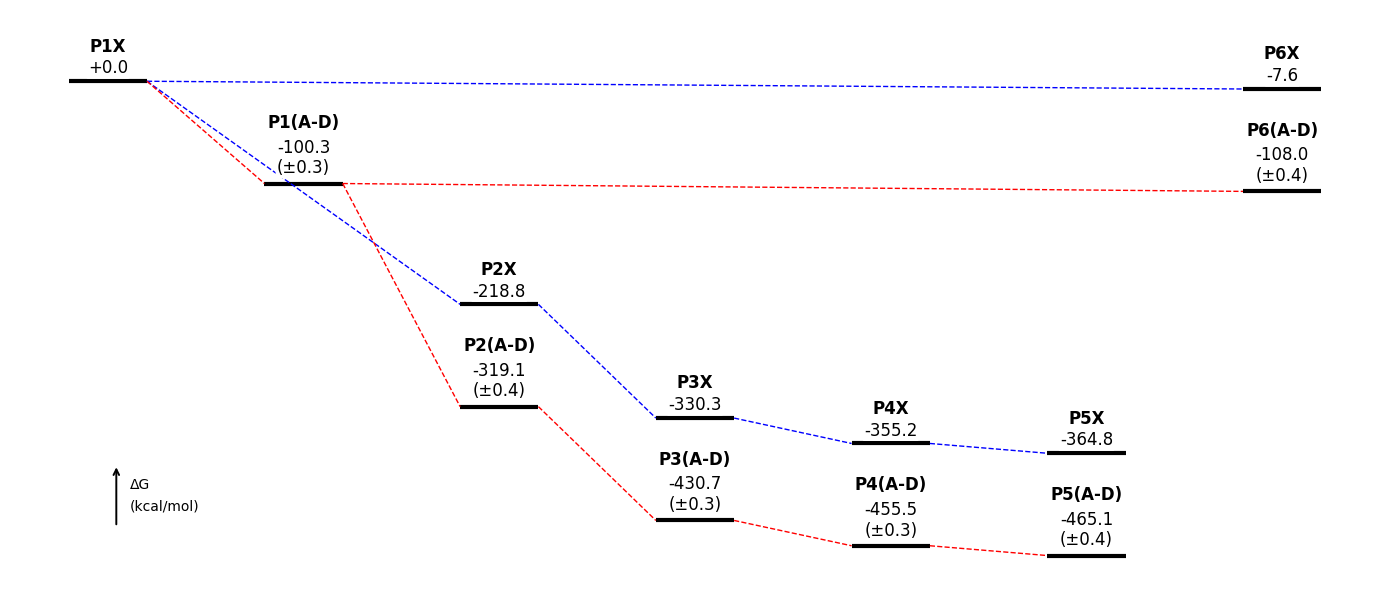

In [27]:
# ================================================================
# OPTIMIZED INPUT FOR FULL PATHWAYS
# ================================================================

# Pathways (same as your original)
pathways = [
    ["p1x", None, "p2x", "p3x", "p4x", "p5x", None],
    ["p1x", None, None, None, None, None, "p6x"],
    ["p1x", "p1a", "p2a", "p3a", "p4a", "p5a", None],
    ["p1x", "p1a", None, None, None, None, "p6a"],
    ["p1x", "p1b", "p2b", "p3b", "p4b", "p5b", None],
    ["p1x", "p1b", None, None, None, None, "p6b"],
    ["p1x", "p1c", "p2c", "p3c", "p4c", "p5c", None],
    ["p1x", "p1c", None, None, None, None, "p6c"],
    ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d", None],
    ["p1x", "p1d", None, None, None, None, "p6d"],
]

# Pattern-based reactions (reduced from 28 to 5!)
reactions = {
    ("p1", "p2"): {"add": {"OH": 4}, "remove": {"H2O": 3}},
    ("p2", "p3"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p3", "p4"): {"remove": {"CO2": 1}},
    ("p4", "p5"): {"add": {"OH": 1}, "remove": {"HCO3": 1}},
    ("p1", "p6"): {"add": {"OH": 1}, "remove": {"H2O": 1, "OMe": 1}},
}

# Special cases (branch initialization)
step_corrections = {
    ("p1x", "p1a"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1b"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1c"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1d"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
}

# Color Scheme Option 1: Group by variant (a/b/c/d)
pathway_colors_option1 = {
    "blue": [
        ["p1x", "p2x", "p3x", "p4x", "p5x"],  # Main pathway
        ["p1x", "p6x"]                         # Main shortcut
    ],
    "red": [
        ["p1x", "p1a", "p2a", "p3a", "p4a", "p5a"],  # Variant A full
        ["p1a", "p6a"]                                 # Variant A shortcut
    ],
    "green": [
        ["p1x", "p1b", "p2b", "p3b", "p4b", "p5b"],  # Variant B full
        ["p1b", "p6b"]                                 # Variant B shortcut
    ],
    "orange": [
        ["p1x", "p1c", "p2c", "p3c", "p4c", "p5c"],  # Variant C full
        ["p1c", "p6c"]                                 # Variant C shortcut
    ],
    "purple": [
        ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d"],  # Variant D full
        ["p1d", "p6d"]                                 # Variant D shortcut
    ]
}

# Color Scheme Option 2: Group by destination (p5 vs p6)
pathway_colors_option2 = {
    "blue": [
        ["p1x", "p2x", "p3x", "p4x", "p5x"],          # Main to p5
        ["p1x", "p6x"],    # Main to p6
    ],
    "red": [
        ["p1x", "p1a", "p2a", "p3a", "p4a", "p5a"],   # A to p5
        ["p1x", "p1b", "p2b", "p3b", "p4b", "p5b"],   # B to p5
        ["p1x", "p1c", "p2c", "p3c", "p4c", "p5c"],   # C to p5
        ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d"],   # D to p5
        ["p1a", "p6a"],    # A to p6
        ["p1b", "p6b"],    # B to p6
        ["p1c", "p6c"],    # C to p6
        ["p1d", "p6d"],    # D to p6
    ]
}

# Color Scheme Option 3: Distinguish main from branches
pathway_colors_option3 = {
    "darkred": [
        ["p1x", "p1a", "p2a", "p3a", "p4a", "p5a"],  # Branch A full - GENERAL
        ["p1x", "p1b", "p2b", "p3b", "p4b", "p5b"],  # Branch B full
        ["p1x", "p1c", "p2c", "p3c", "p4c", "p5c"],  # Branch C full
        ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d"],  # Branch D full
    ],
    "lightcoral": [
        ["p1a", "p6a"],    # Branch shortcuts
        ["p1b", "p6b"],
        ["p1c", "p6c"],
        ["p1d", "p6d"],
    ],
    "darkblue": [
        ["p1x", "p2x", "p3x", "p4x", "p5x"],  # Main pathway
    ],
    "lightblue": [
        ["p1x", "p6x"]                         # Main shortcut
    ],
    "yellow": [
        ["p3x", "p4x"]                         # Non-Overlapped - SPECIFIC override
    ],
    "green": [
        ["p3d", "p4d"]                         # Overlapped - SPECIFIC override
    ],
}

# Manual labels for overlapping points
manual_labels = {
    2: {-100.32: "P1(A-D)"},
    3: {-319.13: "P2(A-D)"},
    4: {-430.70: "P3(A-D)"},
    5: {-455.54: "P4(A-D)"},
    6: {-465.12: "P5(A-D)"},
    7: {-108.04: "P6(A-D)"},
}

# ================================================================
# RUN THE PLOT - Choose your preferred color scheme
# ================================================================

plot_energy_pathways(
    df,
    pathways=pathways,
    reactions=reactions,
    step_corrections=step_corrections,
    pathway_colors=pathway_colors_option2,  # Try option1, option2, or option3
    manual_labels=manual_labels,
    energy_state="S0_OPT",
    overlap_threshold=2.0,
    debug=False  # Set to True to see detailed info
)


OVERLAP DETECTION SUMMARY
No overlapping points detected.



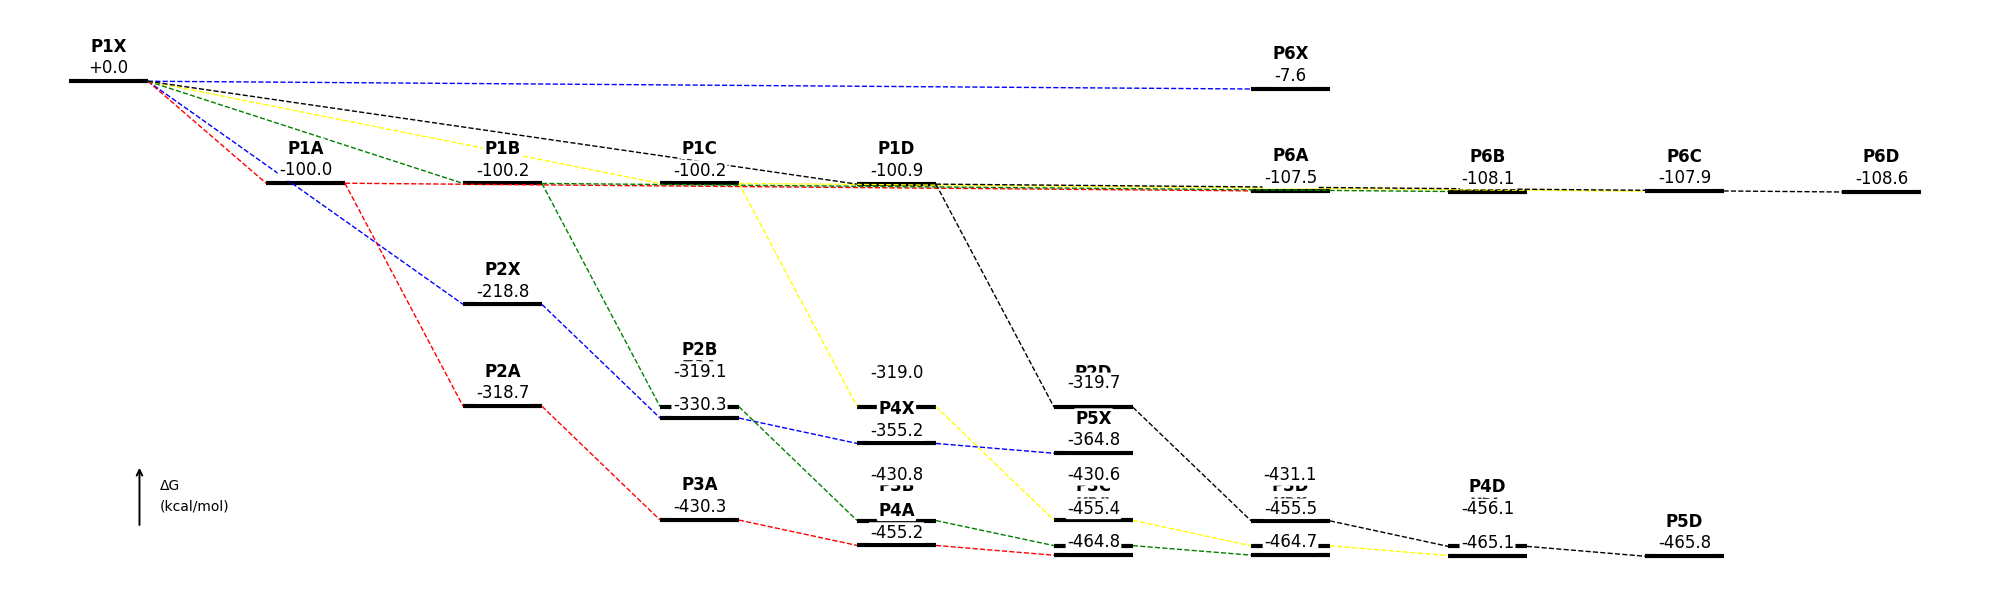

In [28]:
# ================================================================
# OPTIMIZED INPUT FOR FULL PATHWAYS
# ================================================================

# Pathways (same as your original)
pathways = [
    ["p1x", None, "p2x", "p3x", "p4x", "p5x", None, None, None, None],
    ["p1x", None, None, None, None, None, "p6x", None, None, None],
    ["p1x", "p1a", "p2a", "p3a", "p4a", "p5a", None, None, None, None],
    ["p1x", "p1a", None, None, None, None, "p6a", None, None, None],
    ["p1x", None, "p1b", "p2b", "p3b", "p4b", "p5b", None, None, None],
    ["p1x", None, "p1b", None, None, None, None, "p6b", None, None],
    ["p1x", None, None, "p1c", "p2c", "p3c", "p4c", "p5c", None, None],
    ["p1x", None, None, "p1c", None, None, None, None, "p6c", None],
    ["p1x", None, None, None, "p1d", "p2d", "p3d", "p4d", "p5d", None],
    ["p1x", None, None, None, "p1d", None, None, None, None, "p6d"],
]

# Pattern-based reactions (reduced from 28 to 5!)
reactions = {
    ("p1", "p2"): {"add": {"OH": 4}, "remove": {"H2O": 3}},
    ("p2", "p3"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p3", "p4"): {"remove": {"CO2": 1}},
    ("p4", "p5"): {"add": {"OH": 1}, "remove": {"HCO3": 1}},
    ("p1", "p6"): {"add": {"OH": 1}, "remove": {"H2O": 1, "OMe": 1}},
}

# Special cases (branch initialization)
step_corrections = {
    ("p1x", "p1a"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1b"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1c"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1d"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
}

# Color Scheme Option 2: Group by destination (p5 vs p6)
pathway_colors_option2 = {
    "blue": [
        ["p1x", "p2x", "p3x", "p4x", "p5x"],          # Main to p5
        ["p1x", "p6x"],    # Main to p6
    ],
    "red": [
        ["p1x", "p1a", "p2a", "p3a", "p4a", "p5a"],   # A to p5
        ["p1a", "p6a"],    # A to p6
    ],
    "green": [
        ["p1x", "p1b", "p2b", "p3b", "p4b", "p5b"],   # B to p5
        ["p1b", "p6b"],    # B to p6
    ], 
    "yellow": [
        ["p1x", "p1c", "p2c", "p3c", "p4c", "p5c"],   # C to p5
        ["p1c", "p6c"],    # C to p6
    ],
    "black": [
        ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d"],   # D to p5
        ["p1d", "p6d"],    # D to p6
    ]
}

# ================================================================
# RUN THE PLOT - Choose your preferred color scheme
# ================================================================

plot_energy_pathways(
    df,
    pathways=pathways,
    reactions=reactions,
    step_corrections=step_corrections,
    pathway_colors=pathway_colors_option2,  # Try option1, option2, or option3
    energy_state="S0_OPT",
    overlap_threshold=2.0,
    debug=False  # Set to True to see detailed info
)


OVERLAP DETECTION SUMMARY
No overlapping points detected.



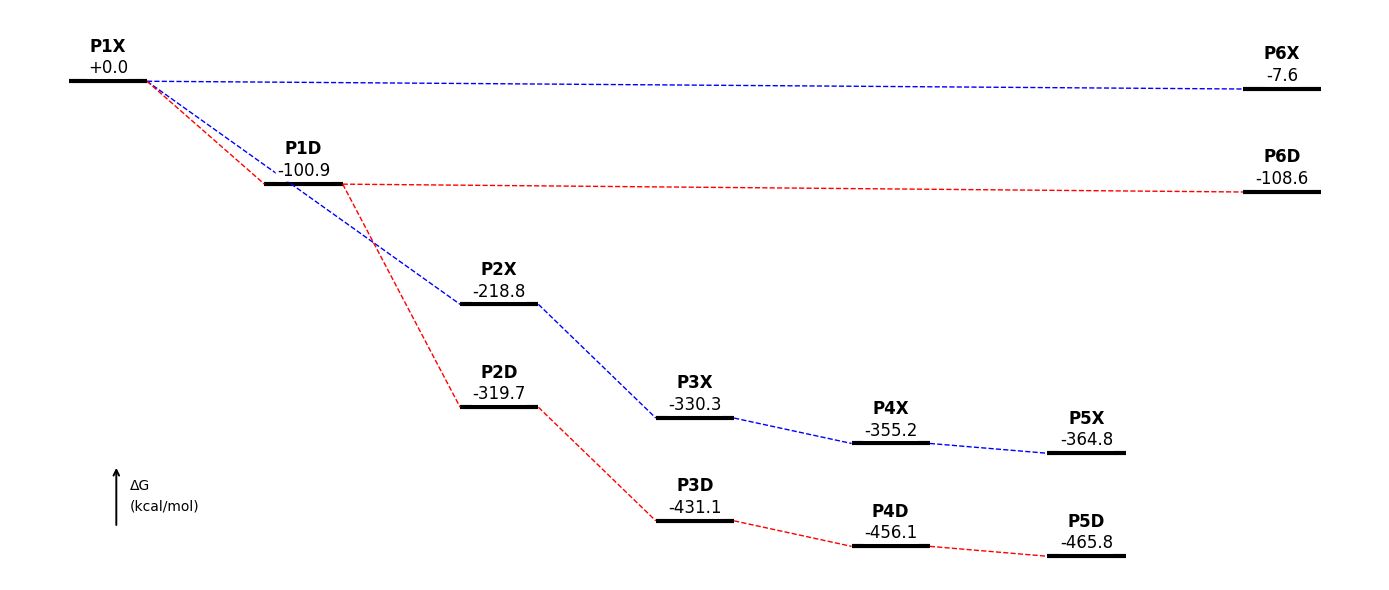

In [29]:
# ================================================================
# OPTIMIZED INPUT FOR FULL PATHWAYS
# ================================================================

# Pathways (same as your original)
pathways = [
    ["p1x", None, "p2x", "p3x", "p4x", "p5x", None],
    ["p1x", None, None, None, None, None, "p6x"],
    ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d", None],
    ["p1x", "p1d", None, None, None, None, "p6d"],
]

# Pattern-based reactions (reduced from 28 to 5!)
reactions = {
    ("p1", "p2"): {"add": {"OH": 4}, "remove": {"H2O": 3}},
    ("p2", "p3"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p3", "p4"): {"remove": {"CO2": 1}},
    ("p4", "p5"): {"add": {"OH": 1}, "remove": {"HCO3": 1}},
    ("p1", "p6"): {"add": {"OH": 1}, "remove": {"H2O": 1, "OMe": 1}},
}

# Special cases (branch initialization)
step_corrections = {
    ("p1x", "p1d"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
}

# Color Scheme Option 2: Group by destination (p5 vs p6)
pathway_colors_option2 = {
    "blue": [
        ["p1x", "p2x", "p3x", "p4x", "p5x"],          # Main to p5
        ["p1x", "p6x"],    # Main to p6
    ],
    "red": [
        ["p1x", "p1d", "p2d", "p3d", "p4d", "p5d"],   # D to p5
        ["p1d", "p6d"],    # D to p6
    ]
}

# ================================================================
# RUN THE PLOT - Choose your preferred color scheme
# ================================================================

plot_energy_pathways(
    df,
    pathways=pathways,
    reactions=reactions,
    step_corrections=step_corrections,
    pathway_colors=pathway_colors_option2,  # Try option1, option2, or option3
    energy_state="S0_OPT",
    overlap_threshold=2.0,
    debug=False  # Set to True to see detailed info
)

### 2. Energy Gap

In [30]:
from typing import List, Optional, Dict, Tuple, Union
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

def plot_orbital_comparison(
    df: pd.DataFrame,
    datasets: Union[List[str], List[List[str]]],
    labels_input: Optional[List[str]] = None,
    state_key: str = "S0_OPT",
    n_orbitals: Union[int, List[int]] = 2,
    overaxis: float = 0.35,
    figsize: Optional[Tuple[float, float]] = None,
    figsize_per_dataset: Optional[float] = None,
    figsize_height: Optional[float] = None,
    pairing_style: str = "o",
    title: Optional[str] = None,
    pad_top: Optional[float] = None,
    pad_bottom: Optional[float] = None,
    padding_top: Optional[float] = None,
    padding_bottom: Optional[float] = None,
    debug: bool = False,
    visual_debug: bool = False,
):
    """
    Plot orbital energy comparison with support for closed/open-shell systems.
    
    Args:
        df: DataFrame with orbital data
        datasets: List of molecule IDs or grouped lists
        labels_input: Custom labels (defaults to dataset names)
        state_key: Orbital state (e.g., "S0_OPT", "T1_OPT")
        n_orbitals: Number of orbitals to display
            - int: Total count, split between HOMO/LUMO (odd remainder goes to HOMO)
            - [n_homo, n_lumo]: Specify exact counts (minimum [1, 1])
            Examples: 2 → [1,1], 4 → [2,2], 5 → [3,2], [4,1] → 4 HOMOs + 1 LUMO
        overaxis: Bar width extension (0-0.5)
        figsize: Figure size as (width, height) tuple. Overrides other size params.
        figsize_per_dataset: Figure width per dataset (default: 1.5, ignored if figsize set)
        figsize_height: Figure height (default: 7.0, ignored if figsize set)
        pairing_style: "o" (original with branches) or "s" (split with bridge)
        title: Custom plot title (None = default title, "" = no title)
        pad_top: Extra space above highest orbital (fraction of range, default: 0.1)
        pad_bottom: Extra space below lowest orbital (fraction of range, default: 0.1)
        padding_top: Alias for pad_top (for backward compatibility)
        padding_bottom: Alias for pad_bottom (for backward compatibility)
        debug: Print debug info
        visual_debug: Show positioning markers
    
    Gap modes (append to dataset name with ":"):
        Closed-shell: HL (HOMO-LUMO)
        Open-shell: SL (SOMO-LUMO, default), HL (HOMO-LUMO), SS (SOMO-SUMO), HS (HOMO-SUMO)
        Use ":NONE" to hide gap
    """
    
    # Handle parameter aliases and defaults
    if pad_top is None:
        pad_top = padding_top if padding_top is not None else 0.1
    if pad_bottom is None:
        pad_bottom = padding_bottom if padding_bottom is not None else 0.1
    
    if figsize_per_dataset is None:
        figsize_per_dataset = 1.5
    if figsize_height is None:
        figsize_height = 7.0
    
    # Parse n_orbitals format
    if isinstance(n_orbitals, list):
        if len(n_orbitals) != 2:
            raise ValueError("n_orbitals as list must have exactly 2 elements [n_homo, n_lumo]")
        n_homo, n_lumo = max(1, n_orbitals[0]), max(1, n_orbitals[1])
    else:
        n_total = max(2, n_orbitals)
        n_homo = (n_total + 1) // 2  # Odd remainder goes to HOMO
        n_lumo = n_total // 2
    
    if debug:
        print(f"Orbital counts: {n_homo} HOMO(s) + {n_lumo} LUMO(s)")
    
    # Parse datasets
    is_grouped = isinstance(datasets[0], list) if datasets else False
    groups = datasets if is_grouped else [datasets]
    flat_datasets = [item for group in groups for item in group]
    parsed_datasets = [_parse_dataset(ds) for ds in flat_datasets]
    
    # Validate labels
    labels_input = labels_input or flat_datasets[:]
    if len(labels_input) != len(flat_datasets):
        raise ValueError(f"Label count ({len(labels_input)}) != dataset count ({len(flat_datasets)})")
    
    if debug:
        _print_debug_header(is_grouped, groups)
    
    # Collect metadata
    meta = [_collect_metadata(df, mol_id, gap_mode, state_key, n_homo, n_lumo, name, debug)
            for (mol_id, gap_mode), name in zip(parsed_datasets, flat_datasets)]
    
    if all(m is None for m in meta):
        raise RuntimeError("No orbital data found")
    
    # Create plot
    n = len(flat_datasets)
    
    # Determine figure size
    if figsize is not None:
        fig_width, fig_height = figsize
    else:
        fig_width = max(4, n * figsize_per_dataset)
        fig_height = figsize_height
    
    plt.figure(figsize=(fig_width, fig_height))
    
    if debug:
        print(f"\n{'='*60}\nRENDERING\n{'='*60}")
        print(f"Figure size: {fig_width:.1f} x {fig_height:.1f} inches")
    
    # Draw orbitals and connectors
    for i, m in enumerate(meta):
        _draw_orbitals(i, m, flat_datasets, overaxis, pairing_style, debug, visual_debug)
    
    _draw_connectors(meta, groups, overaxis, debug)
    
    # Apply padding to y-axis
    if pad_top > 0 or pad_bottom > 0:
        y_min, y_max = plt.ylim()
        y_range = y_max - y_min
        new_y_min = y_min - (y_range * pad_bottom)
        new_y_max = y_max + (y_range * pad_top)
        plt.ylim(new_y_min, new_y_max)
        if debug:
            print(f"Y-axis padding: bottom={pad_bottom:.2f}, top={pad_top:.2f}")
            print(f"Y-axis range: [{new_y_min:.2f}, {new_y_max:.2f}]")
    
    # Finalize
    plt.xticks(range(1, n+1), labels_input, fontsize=11,
               rotation=45 if n > 6 else 0, ha='right' if n > 6 else 'center')
    plt.ylabel("Energy (eV)", fontsize=12)
    
    # Handle title
    if title is None:
        # Default title
        plt.title(f"Orbital Energy Comparison ({state_key})", fontsize=13)
    elif title != "":
        # Custom title (empty string means no title)
        plt.title(title, fontsize=13)
    # If title == "", no title is set
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()


def _parse_dataset(ds: str) -> Tuple[str, Optional[str]]:
    """Parse 'molecule_id:gap_mode' format."""
    if ":" in ds:
        mol_id, mode = ds.rsplit(":", 1)
        return mol_id.lstrip("*"), None if mode.upper() == "NONE" else mode.upper()
    return ds.lstrip("*"), "default"


def _print_debug_header(is_grouped: bool, groups: List):
    """Print debug header."""
    print(f"\n{'='*60}\nORBITAL COMPARISON DEBUG\n{'='*60}")
    if is_grouped:
        print(f"Groups: {len(groups)}")
        for i, g in enumerate(groups):
            print(f"  Group {i}: {g}")
    print('='*60)


def _collect_metadata(df: pd.DataFrame, mol_id: str, gap_mode: Optional[str],
                     state_key: str, n_homo: int, n_lumo: int, name: str, 
                     debug: bool) -> Optional[Dict]:
    """Extract orbital metadata from DataFrame."""
    mask = df["molecule_id"].str.lower() == mol_id.lower()
    if not mask.any():
        return None
    
    row = df[mask].iloc[0]
    orb_dict = row.get("orbitals", {})
    if not isinstance(orb_dict, dict) or state_key not in orb_dict:
        return None
    
    orb_df = orb_dict[state_key]
    if not isinstance(orb_df, pd.DataFrame) or orb_df.empty:
        return None
    
    # Normalize
    od = orb_df.copy()
    for c in ["OCC", "Eh", "eV"]:
        if c in od.columns:
            od[c] = pd.to_numeric(od[c], errors="coerce")
    
    od["spin"] = od.get("spin", "na").astype(str).str.lower().replace({
        "alpha": "up", "beta": "down", "a": "up", "b": "down"
    })
    
    is_closed = (od["spin"] == "na").all()
    
    if debug:
        print(f"\n--- {name} ---\nType: {'CLOSED' if is_closed else 'OPEN'}")
    
    return _process_closed(od, gap_mode, n_homo, n_lumo, debug) if is_closed else \
           _process_open(od, gap_mode, n_homo, n_lumo, debug)


def _process_closed(od: pd.DataFrame, gap_mode: Optional[str], n_homo: int, 
                   n_lumo: int, debug: bool) -> Dict:
    """Process closed-shell data."""
    occ = od[od["OCC"] > 0]
    vir = od[od["OCC"] == 0]
    
    if occ.empty or vir.empty:
        return {"type": "closed", "levels": [], "homo": np.nan, "lumo": np.nan,
                "gap_mode": "HL", "gap_value": np.nan, "gap_from_energy": np.nan,
                "gap_to_energy": np.nan, "show_gap": False}
    
    homo = float(occ["eV"].max())
    lumo = float(vir["eV"].min())
    show_gap = gap_mode is not None and gap_mode != "NONE"
    
    if debug:
        print(f"HOMO: {homo:.4f} eV, LUMO: {lumo:.4f} eV")
        print(f"Gap: {lumo-homo:.4f} eV ({('shown' if show_gap else 'hidden')})")
    
    # Select orbitals
    occ_sel = occ.nlargest(n_homo, "eV")
    vir_sel = vir.nsmallest(n_lumo, "eV")
    
    levels = []
    for i, (_, r) in enumerate(occ_sel.iterrows()):
        e = float(r["eV"])
        levels.append({"type": "paired_occ", "energy": e, "alpha_e": e, "beta_e": e,
                      "label": "HOMO" if i == 0 else f"HOMO-{i}"})
    
    for i, (_, r) in enumerate(vir_sel.iterrows()):
        e = float(r["eV"])
        levels.append({"type": "paired_vir", "energy": e, "alpha_e": e, "beta_e": e,
                      "label": "LUMO" if i == 0 else f"LUMO+{i}"})
    
    return {"type": "closed", "levels": levels, "homo": homo, "lumo": lumo,
            "gap_mode": "HL", "gap_value": lumo-homo, "gap_from_energy": homo,
            "gap_to_energy": lumo, "show_gap": show_gap}


def _process_open(od: pd.DataFrame, gap_mode: Optional[str], n_homo: int, 
                 n_lumo: int, debug: bool) -> Dict:
    """Process open-shell data."""
    a_df = od[od["spin"] == "up"]
    b_df = od[od["spin"] == "down"]
    
    a_occ = a_df[a_df["OCC"] > 0].sort_values("eV", ascending=False)
    a_vir = a_df[a_df["OCC"] == 0].sort_values("eV")
    b_occ = b_df[b_df["OCC"] > 0].sort_values("eV", ascending=False)
    b_vir = b_df[b_df["OCC"] == 0].sort_values("eV")
    
    # Identify SOMO/SUMO
    if len(a_occ) > len(b_occ):
        somo, spin, sumo = (a_occ.iloc[0], "alpha", b_vir.iloc[0]) if not b_vir.empty else (a_occ.iloc[0], "alpha", None)
        a_occ_rest, b_occ_rest = a_occ.iloc[1:], b_occ
        a_vir_rest, b_vir_rest = a_vir, b_vir.iloc[1:] if len(b_vir) > 1 else pd.DataFrame()
    elif len(b_occ) > len(a_occ):
        somo, spin, sumo = (b_occ.iloc[0], "beta", a_vir.iloc[0]) if not a_vir.empty else (b_occ.iloc[0], "beta", None)
        a_occ_rest, b_occ_rest = a_occ, b_occ.iloc[1:]
        a_vir_rest, b_vir_rest = a_vir.iloc[1:] if len(a_vir) > 1 else pd.DataFrame(), b_vir
    else:
        somo, spin, sumo = None, None, None
        a_occ_rest, b_occ_rest, a_vir_rest, b_vir_rest = a_occ, b_occ, a_vir, b_vir
    
    somo_e = float(somo["eV"]) if somo is not None else np.nan
    sumo_e = float(sumo["eV"]) if sumo is not None else np.nan
    homo_e = _paired_energy(a_occ_rest, b_occ_rest)
    lumo_e = _paired_energy(a_vir_rest, b_vir_rest, use_min=True)
    
    # Gap
    if gap_mode is None:
        mode, show = "SL", False
    elif gap_mode == "default":
        mode, show = "SL", True
    else:
        mode, show = (gap_mode if gap_mode in ["HL","SL","SS","HS"] else "SL"), True
    
    gap_map = {"SL": (somo_e, lumo_e), "HL": (homo_e, lumo_e),
               "SS": (somo_e, sumo_e), "HS": (homo_e, sumo_e)}
    gap_from, gap_to = gap_map.get(mode, (somo_e, lumo_e))
    
    if debug:
        if somo is not None:
            print(f"SOMO ({spin}): {somo_e:.4f} eV")
        if sumo is not None:
            print(f"SUMO: {sumo_e:.4f} eV")
        print(f"HOMO: {homo_e:.4f} eV")
        if show:
            print(f"Gap ({mode}): {gap_to-gap_from:.4f} eV")
    
    # Build levels
    levels = []
    if somo is not None:
        levels.append({"type": "somo", "energy": somo_e,
                      "alpha_e": somo_e if spin == "alpha" else None,
                      "beta_e": somo_e if spin == "beta" else None, "label": "SOMO"})
    if sumo is not None:
        levels.append({"type": "sumo", "energy": sumo_e,
                      "alpha_e": sumo_e if spin == "beta" else None,
                      "beta_e": sumo_e if spin == "alpha" else None, "label": "SUMO"})
    
    # Add paired orbitals (use n_homo and n_lumo)
    for i in range(min(n_homo, max(len(a_occ_rest), len(b_occ_rest)))):
        a_e = float(a_occ_rest.iloc[i]["eV"]) if i < len(a_occ_rest) else None
        b_e = float(b_occ_rest.iloc[i]["eV"]) if i < len(b_occ_rest) else None
        if a_e or b_e:
            levels.append({"type": "paired_occ", "energy": a_e or b_e,
                          "alpha_e": a_e, "beta_e": b_e,
                          "label": "HOMO" if i == 0 else f"HOMO-{i}"})
    
    for i in range(min(n_lumo, max(len(a_vir_rest), len(b_vir_rest)))):
        a_e = float(a_vir_rest.iloc[i]["eV"]) if i < len(a_vir_rest) else None
        b_e = float(b_vir_rest.iloc[i]["eV"]) if i < len(b_vir_rest) else None
        if a_e or b_e:
            levels.append({"type": "paired_vir", "energy": a_e or b_e,
                          "alpha_e": a_e, "beta_e": b_e,
                          "label": "LUMO" if i == 0 else f"LUMO+{i}"})
    
    levels.sort(key=lambda x: x["energy"])
    
    all_occ = od[od["OCC"] > 0]
    all_vir = od[od["OCC"] == 0]
    return {"type": "open", "levels": levels,
            "homo": float(all_occ["eV"].max()) if not all_occ.empty else np.nan,
            "lumo": float(all_vir["eV"].min()) if not all_vir.empty else np.nan,
            "gap_mode": mode, "gap_value": gap_to - gap_from,
            "gap_from_energy": gap_from, "gap_to_energy": gap_to, "show_gap": show}


def _paired_energy(a_df: pd.DataFrame, b_df: pd.DataFrame, use_min=False) -> float:
    """Calculate paired orbital energy."""
    if not a_df.empty and not b_df.empty:
        a_e, b_e = float(a_df.iloc[0]["eV"]), float(b_df.iloc[0]["eV"])
        return min(a_e, b_e) if use_min else (a_e + b_e) / 2
    return float(a_df.iloc[0]["eV"]) if not a_df.empty else float(b_df.iloc[0]["eV"]) if not b_df.empty else np.nan


def _draw_orbitals(i: int, m: Optional[Dict], names: List, overaxis: float,
                  style: str, debug: bool, visual_debug: bool):
    """Draw orbitals for dataset i."""
    xc, xl, xr = i + 1, i + 1 - overaxis, i + 1 + overaxis
    
    if m is None:
        plt.text(xc, 0, "(no data)", ha="center", va="center", color="gray")
        return
    
    m["pairing_style"] = style
    is_closed = m["type"] == "closed"
    
    if debug:
        print(f"\nDataset {i+1}: {names[i]} ({'closed' if is_closed else 'open'})")
    
    if visual_debug:
        y_max = plt.ylim()[1]
        for x, lbl, col in [(xl, f'L{i+1}', 'green'), (xc, f'C{i+1}', 'purple'), 
                            (xr, f'R{i+1}', 'green')]:
            plt.axvline(x, color=col, linestyle=':', lw=0.5, alpha=0.3, zorder=0)
            plt.text(x, y_max*0.98, lbl, ha='center', va='top', fontsize=6, color=col, alpha=0.5)
    
    for lvl in m["levels"]:
        color = "blue" if "occ" in lvl["type"] or lvl["type"] == "somo" else "red"
        _draw_level(xl, xr, lvl.get("alpha_e"), lvl.get("beta_e"), lvl["type"],
                   is_closed, color, style, visual_debug)
    
    if m.get("show_gap"):
        gf, gt, gv = m["gap_from_energy"], m["gap_to_energy"], m["gap_value"]
        if not (math.isnan(gf) or math.isnan(gt)):
            plt.annotate("", xy=(xc, gt), xytext=(xc, gf),
                        arrowprops=dict(arrowstyle="<->", lw=1.5, color="black"))
            mid = (gf + gt) / 2
            if abs(gv) < 1:
                plt.text(xc+0.15, mid, f"{gv:.2f}", va="center", ha="left", fontsize=8,
                        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9, lw=0.5))
            else:
                plt.text(xc, mid, f"{gv:.2f}", va="center", ha="center", fontsize=9,
                        bbox=dict(facecolor="white", edgecolor="none", alpha=1))


def _draw_level(xl: float, xr: float, a_e: Optional[float], b_e: Optional[float],
               ltype: str, is_closed: bool, color: str, style: str, vdebug: bool):
    """Draw single orbital level."""
    w = xr - xl
    
    if style == "o":
        bl, ar, beta_l, br = xl+0.05*w, xl+0.45*w, xl+0.55*w, xl+0.95*w
    else:
        ar, beta_l = xl+0.45*w, xl+0.55*w
    
    if ltype in ["paired_occ", "paired_vir"]:
        if is_closed and a_e:
            plt.hlines(a_e, xl, xr, lw=2, color=color, zorder=2)
            if vdebug:
                plt.plot([xl, xr], [a_e, a_e], 'o', ms=3, color='black', alpha=0.5, zorder=3)
        else:
            if style == "o":
                _draw_style_o(xl, bl, ar, beta_l, br, xr, a_e, b_e, color, vdebug)
            else:
                _draw_style_s(xl, xr, ar, beta_l, a_e, b_e, color, vdebug)
    
    elif ltype in ["somo", "sumo"]:
        if a_e:
            plt.hlines(a_e, xl, ar, lw=2.5, color=color, zorder=2)
            plt.hlines(a_e, ar, xr, lw=1, color=color, ls='--', alpha=0.3, zorder=1)
        elif b_e:
            plt.hlines(b_e, xl, beta_l, lw=1, color=color, ls='--', alpha=0.3, zorder=1)
            plt.hlines(b_e, beta_l, xr, lw=2.5, color=color, zorder=2)


def _draw_style_o(xl, bl, ar, beta_l, br, xr, a_e, b_e, col, vd):
    """Draw original style with branches."""
    if a_e and b_e:
        plt.hlines(a_e, bl, ar, lw=2, color=col, zorder=2)
        plt.hlines(b_e, beta_l, br, lw=2, color=col, zorder=2)
        plt.hlines(a_e, ar, br, lw=1, color=col, ls='--', alpha=0.3, zorder=1)
        plt.hlines(b_e, bl, beta_l, lw=1, color=col, ls='--', alpha=0.3, zorder=1)
        
        mid = (a_e + b_e) / 2
        # Thin branch/merge lines with 0.5 opacity
        plt.plot([xl, bl], [mid, a_e], "-", lw=0.5, color=col, alpha=0.5, zorder=1)
        plt.plot([xl, bl], [mid, b_e], "-", lw=0.5, color=col, alpha=0.5, zorder=1)
        plt.plot([br, xr], [a_e, mid], "-", lw=0.5, color=col, alpha=0.5, zorder=1)
        plt.plot([br, xr], [b_e, mid], "-", lw=0.5, color=col, alpha=0.5, zorder=1)
    elif a_e:
        plt.hlines(a_e, bl, ar, lw=2, color=col, zorder=2)
        plt.hlines(a_e, ar, br, lw=1, color=col, ls='--', alpha=0.3, zorder=1)
        plt.hlines(a_e, xl, bl, lw=0.8, color=col, alpha=0.7, zorder=1)
        plt.hlines(a_e, br, xr, lw=0.8, color=col, alpha=0.7, zorder=1)
    elif b_e:
        plt.hlines(b_e, bl, beta_l, lw=1, color=col, ls='--', alpha=0.3, zorder=1)
        plt.hlines(b_e, beta_l, br, lw=2, color=col, zorder=2)
        plt.hlines(b_e, xl, bl, lw=0.8, color=col, alpha=0.7, zorder=1)
        plt.hlines(b_e, br, xr, lw=0.8, color=col, alpha=0.7, zorder=1)


def _draw_style_s(xl, xr, ar, beta_l, a_e, b_e, col, vd):
    """Draw split style with bridge."""
    if a_e and b_e:
        plt.hlines(a_e, xl, ar, lw=2, color=col, zorder=2)
        plt.hlines(b_e, beta_l, xr, lw=2, color=col, zorder=2)
        
        if abs(a_e - b_e) > 0.01:
            mid = (a_e + b_e) / 2
            # Thin diagonal with 0.5 opacity
            plt.plot([ar, beta_l], [a_e, b_e], ls='--', lw=1, color=col, alpha=0.5, zorder=1)
            # Thin center bar (0.75 * 2 = 1.5) with 0.5 opacity
            plt.hlines(mid, ar, beta_l, lw=1.5, color=col, alpha=0.5, zorder=2)
            # Dashed extensions
            plt.hlines(mid, xl, ar, lw=1, color=col, ls='-', alpha=0.4, zorder=1)
            plt.hlines(mid, beta_l, xr, lw=1, color=col, ls='-', alpha=0.4, zorder=1)
    elif a_e:
        plt.hlines(a_e, xl, ar, lw=2, color=col, zorder=2)
    elif b_e:
        plt.hlines(b_e, beta_l, xr, lw=2, color=col, zorder=2)


def _draw_connectors(meta: List, groups: List, overaxis: float, debug: bool):
    """Draw connectors between datasets."""
    if len(meta) < 2:
        return
    
    if debug:
        print(f"\n{'='*60}\nCONNECTORS\n{'='*60}")
    
    # Build label maps
    maps = [{lvl["label"]: lvl for lvl in (m["levels"] if m else [])} for m in meta]
    
    # Get connection labels (exclude SOMO/SUMO)
    all_labels = set()
    for mp in maps:
        all_labels.update(mp.keys())
    
    order = []
    for i in range(10, 0, -1):
        order.append(f"HOMO-{i}")
    order.extend(["HOMO", "LUMO"])
    for i in range(1, 10):
        order.append(f"LUMO+{i}")
    
    conn_labels = [lbl for lbl in order if lbl in all_labels and lbl not in ["SOMO", "SUMO"]]
    
    # Draw for each group
    for g_idx, group in enumerate(groups):
        idx_start = sum(len(groups[j]) for j in range(g_idx))
        g_indices = list(range(idx_start, idx_start + len(group)))
        
        for lbl in conn_labels:
            prev_x, prev_y = None, None
            
            for i in g_indices:
                if not meta[i] or lbl not in maps[i]:
                    prev_x, prev_y = exit_x, curr_yy = None, None
                    continue
                
                lvl = maps[i][lbl]
                xl, xr = i + 1 - overaxis, i + 1 + overaxis
                a_e, b_e = lvl.get("alpha_e"), lvl.get("beta_e")
                
                # Calculate exit/entry
                if meta[i]["type"] == "closed" and a_e:
                    curr_y = a_e
                    exit_x = xr
                else:
                    style = meta[i].get("pairing_style", "o")
                    if a_e and b_e and abs(a_e - b_e) > 0.01:
                        curr_y = (a_e + b_e) / 2
                    else:
                        curr_y = a_e or b_e
                    exit_x = xr
                
                # Draw connector
                if prev_x is not None:
                    plt.plot([prev_x, xl], [prev_y, curr_y], "--", lw=1, 
                            color="gray", alpha=0.5, zorder=0)
                
                prev_x, prev_y = exit_x, curr_y

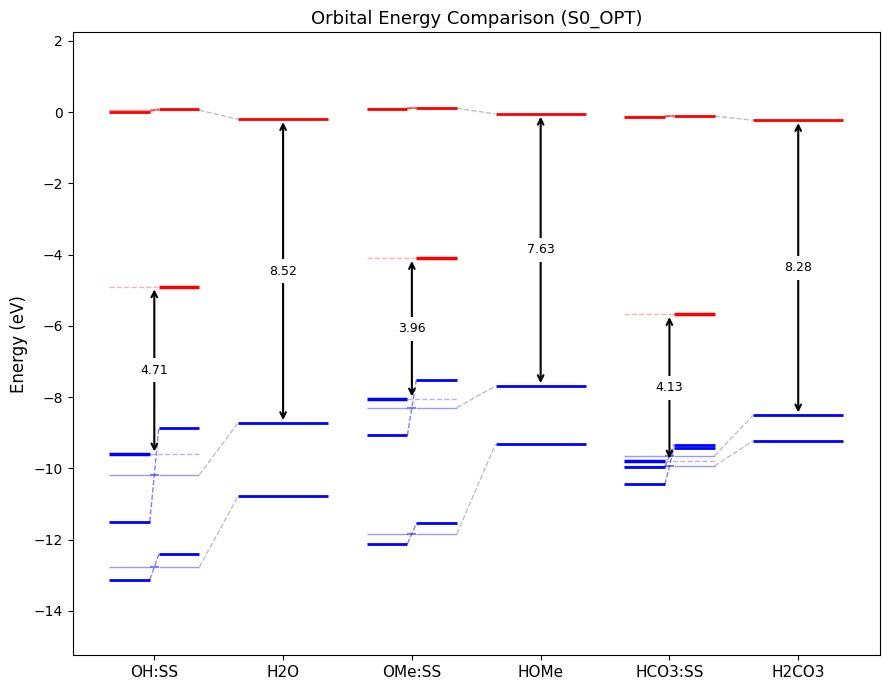

In [31]:
plot_orbital_comparison(df,
    datasets=[["OH:SS", "H2O"], ["OMe:SS", "HOMe"], ["HCO3:SS", "H2CO3"]],
    n_orbitals=[2, 1],
    pairing_style="s",
    debug=False)

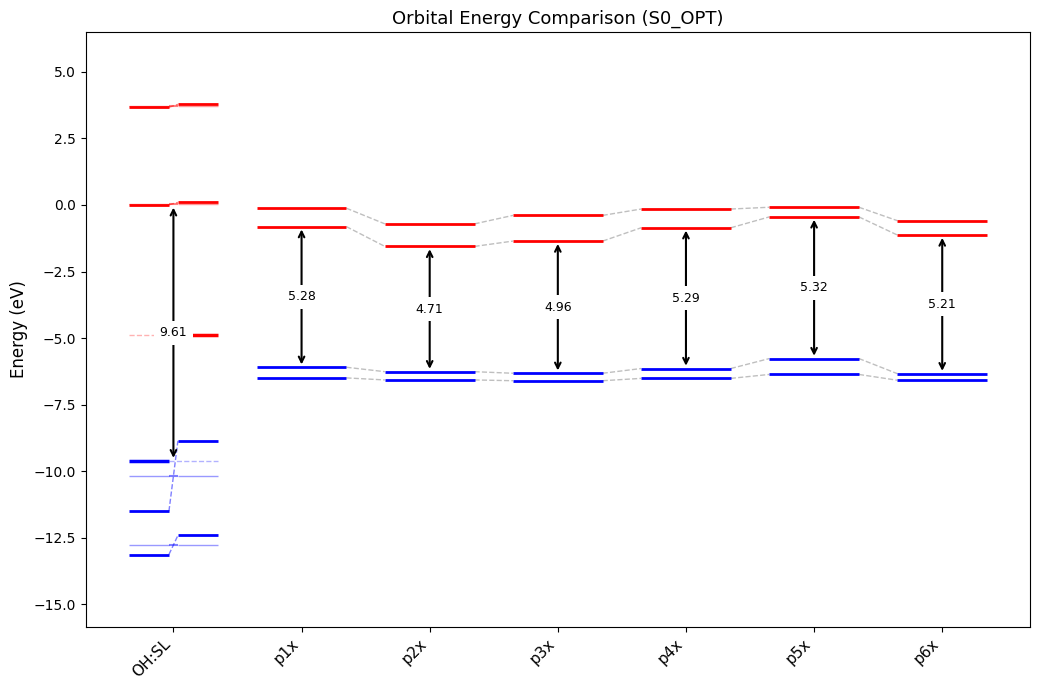

In [32]:
plot_orbital_comparison(df,
    datasets=[["OH:SL"], ["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"]],
    n_orbitals=[2, 2],
    pairing_style="s",
    debug=False)

### 3. Raman

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from typing import List, Optional, Dict, Tuple
from dataclasses import dataclass

@dataclass
class PeakLabelConfig:
    """Configuration for peak labeling."""
    enabled: bool = False
    mode: str = "top_n"  # "top_n", "threshold", "all", "ranges"
    top_n: int = 3
    threshold: float = 0.3
    ranges: Optional[List[Tuple[float, float]]] = None
    min_distance: float = 50.0
    offset: float = 0.05
    fontsize: int = 9
    format: str = "{freq:.0f}"
    assignments: Optional[Dict[Tuple[float, float], str]] = None
    molecules_to_label: Optional[List[int]] = None


def _validate_inputs(df: pd.DataFrame, molecule_ids: List[str], labels: List[str]):
    """Validate input parameters."""
    if labels and len(labels) != len(molecule_ids):
        raise ValueError(f"Length of labels ({len(labels)}) must match molecule_ids ({len(molecule_ids)})")
    
    if df.empty or "molecule_id" not in df.columns or "raman_spectrum" not in df.columns:
        raise ValueError("DataFrame must contain 'molecule_id' and 'raman_spectrum' columns")


def _build_spectrum(df_raman: pd.DataFrame, shifts: np.ndarray, sigma: float) -> np.ndarray:
    """Build Gaussian-broadened spectrum from discrete peaks."""
    spectrum = np.zeros_like(shifts)
    
    # Vectorized computation for better performance
    freqs = df_raman["freq_cm-1"].values
    intensities = df_raman["activity"].values
    
    for freq, intensity in zip(freqs, intensities):
        spectrum += intensity * np.exp(-((shifts - freq) ** 2) / (2 * sigma ** 2))
    
    # Normalize to 0-1 scale
    max_val = spectrum.max()
    return spectrum / max_val if max_val > 0 else spectrum


def _load_spectra(
    df: pd.DataFrame, 
    molecule_ids: List[str], 
    labels: List[str],
    shifts: np.ndarray,
    sigma: float
) -> Tuple[List[np.ndarray], List[str], List[str]]:
    """Load and process all molecular spectra."""
    spectra = []
    valid_labels = []
    valid_ids = []
    
    for mol_id, label in zip(molecule_ids, labels):
        # Case-insensitive search
        mask = df["molecule_id"].str.contains(mol_id, case=False, na=False, regex=False)
        
        if not mask.any():
            print(f"⚠️  Warning: Molecule '{mol_id}' not found, skipping")
            continue
        
        try:
            mol_idx = df[mask].index[0]
            df_raman = pd.DataFrame(df["raman_spectrum"].iloc[mol_idx])
            spectrum = _build_spectrum(df_raman, shifts, sigma)
            
            spectra.append(spectrum)
            valid_labels.append(label)
            valid_ids.append(mol_id)
            
        except Exception as e:
            print(f"⚠️  Warning: Failed to process '{mol_id}': {e}")
            continue
    
    if not spectra:
        raise ValueError("No valid Raman spectra found")
    
    return spectra, valid_labels, valid_ids


def _calculate_offsets(spectra: List[np.ndarray], y_spacing: float) -> Tuple[List[float], float]:
    """Calculate vertical offsets for stacked spectra."""
    offsets = []
    current_top = 0
    global_top = 0
    
    for i, spectrum in enumerate(spectra):
        if i == 0:
            offset = 0
        else:
            prev_top = current_top
            this_bottom = spectrum.min()
            offset = prev_top - this_bottom + y_spacing
        
        current_top = offset + spectrum.max()
        global_top = max(global_top, current_top)
        offsets.append(offset)
    
    return offsets, global_top


def _select_peaks_by_mode(
    peak_heights: np.ndarray,
    peak_freqs: np.ndarray,
    config: PeakLabelConfig
) -> List[int]:
    """Select peaks based on labeling mode."""
    if config.mode == "all":
        return list(range(len(peak_heights)))
    
    if config.mode == "top_n":
        height_order = np.argsort(peak_heights)[::-1]
        return sorted(height_order[:config.top_n].tolist())
    
    if config.mode == "threshold":
        return [i for i, h in enumerate(peak_heights) if h >= config.threshold]
    
    if config.mode == "ranges":
        if not config.ranges:
            print("⚠️  Warning: peak_ranges required for mode 'ranges'")
            return []
        
        selected = []
        for i, freq in enumerate(peak_freqs):
            if any(min_f <= freq <= max_f for min_f, max_f in config.ranges):
                selected.append(i)
        return selected
    
    return []


def _find_assignment(freq: float, assignments: Optional[Dict]) -> Optional[str]:
    """Find functional group assignment for a frequency."""
    if not assignments:
        return None
    
    for (min_f, max_f), name in assignments.items():
        if min_f <= freq <= max_f:
            return name
    return None


def _add_peak_labels(
    ax: plt.Axes,
    spectra: List[np.ndarray],
    shifts: np.ndarray,
    y_offsets: List[float],
    colors: List[str],
    config: PeakLabelConfig
):
    """Add peak labels to spectra."""
    if not config.enabled:
        return
    
    dx = shifts[1] - shifts[0]
    min_dist_samples = max(1, int(config.min_distance / dx))
    
    for spec_idx, spectrum in enumerate(spectra):
        # Check if this molecule should be labeled
        if config.molecules_to_label is not None and spec_idx not in config.molecules_to_label:
            continue
        
        # Find peaks
        peaks, _ = find_peaks(
            spectrum,
            height=0.01,
            prominence=0.01,
            distance=min_dist_samples
        )
        
        if len(peaks) == 0:
            continue
        
        peak_freqs = shifts[peaks]
        peak_heights = spectrum[peaks]
        
        # Select peaks to label
        selected = _select_peaks_by_mode(peak_heights, peak_freqs, config)
        
        # Add labels
        y_offset = y_offsets[spec_idx]
        
        for peak_idx in selected:
            freq = peak_freqs[peak_idx]
            height = peak_heights[peak_idx]
            assignment = _find_assignment(freq, config.assignments)
            
            # Format label
            label_text = config.format.format(
                freq=freq,
                intensity=height,
                assign=assignment or ""
            )
            label_text = "\n".join(line for line in label_text.split("\n") if line.strip())
            
            # Add vertical label above peak
            ax.text(
                freq, 
                y_offset + height + config.offset,
                label_text,
                ha='center', 
                va='bottom',
                fontsize=config.fontsize,
                color='black',
                rotation=90
            )


def _add_experimental_spectrum(
    ax: plt.Axes,
    experimental_data: Dict,
    shifts: np.ndarray,
    y_offsets: List[float],
    y_spacing: float,
    exp_position: int
) -> Tuple[List[float], List[str], List[np.ndarray]]:
    """Add experimental spectrum to plot."""
    try:
        if "raman_freq" not in experimental_data or "intensity" not in experimental_data:
            raise ValueError("experimental_data must contain 'raman_freq' and 'intensity'")
        
        # Interpolate and normalize
        eks_interp = np.interp(shifts, experimental_data["raman_freq"], experimental_data["intensity"])
        max_val = eks_interp.max()
        if max_val > 0:
            eks_interp /= max_val
        
        # Position below reference spectrum
        exp_position = np.clip(exp_position, 0, len(y_offsets) - 1)
        ref_offset = y_offsets[exp_position]
        exp_offset = ref_offset - (eks_interp.max() + y_spacing)
        
        # Plot
        ax.plot(shifts, eks_interp + exp_offset, color="black", lw=1.5, linestyle="--", label="Experimental")
        
        # Update offsets and labels
        y_offsets.insert(exp_position, exp_offset)
        return y_offsets, ["Experimental"], [eks_interp]
        
    except Exception as e:
        print(f"⚠️  Warning: Could not plot experimental spectrum: {e}")
        return y_offsets, [], []


def plot_stacked_raman_spectra(
    df: pd.DataFrame,
    molecule_ids: List[str],
    labels: Optional[List[str]] = None,
    experimental_data: Optional[Dict] = None,
    exp_position: int = 0,
    shift_min: float = 50,
    shift_max: float = 4000,
    n_points: int = 5000,
    fwhm: float = 17.0,
    y_spacing: float = 0.3,
    colors: Optional[List[str]] = None,
    region_boundaries: Optional[List[float]] = None,
    order: str = 'ascending',
    figsize: tuple = (12, 8),
    title: str = "Raman Spectra",
    invert_x: bool = True,
    
    # Peak labeling parameters
    label_peaks: bool = False,
    peak_label_mode: str = "top_n",
    peak_top_n: int = 3,
    peak_threshold: float = 0.3,
    peak_ranges: Optional[List[Tuple[float, float]]] = None,
    peak_min_distance: float = 50.0,
    peak_label_offset: float = 0.05,
    peak_label_fontsize: int = 9,
    peak_label_format: str = "{freq:.0f}",
    peak_assignments: Optional[Dict[Tuple[float, float], str]] = None,
    label_only_molecules: Optional[List[int]] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot stacked Raman spectra with optional vertical peak labels.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'molecule_id' and 'raman_spectrum' columns
    molecule_ids : List[str]
        List of molecule identifiers to plot
    labels : Optional[List[str]]
        Display labels (defaults to molecule_ids)
    experimental_data : Optional[Dict]
        Dict with 'raman_freq' and 'intensity' keys
    exp_position : int
        Position to insert experimental spectrum (0 = bottom)
    shift_min, shift_max : float
        Raman shift range (cm⁻¹)
    n_points : int
        Number of points in interpolated spectrum
    fwhm : float
        Full width at half maximum for Gaussian broadening
    y_spacing : float
        Vertical spacing between spectra (0-1 scale)
    colors : Optional[List[str]]
        Colors for each spectrum
    region_boundaries : Optional[List[float]]
        Vertical lines at specified wavenumbers
    order : str
        'ascending' or 'descending' stack order
    figsize : tuple
        Figure size (width, height)
    title : str
        Plot title
    invert_x : bool
        Invert x-axis (default: True)
    
    Peak Labeling Parameters
    -------------------------
    label_peaks : bool
        Enable peak labeling
    peak_label_mode : str
        Selection mode: "top_n", "threshold", "all", "ranges"
    peak_top_n : int
        Number of top peaks to label (mode="top_n")
    peak_threshold : float
        Minimum relative intensity (0-1 scale, mode="threshold")
    peak_ranges : Optional[List[Tuple[float, float]]]
        Frequency ranges (mode="ranges")
    peak_min_distance : float
        Minimum spacing between labeled peaks (cm⁻¹)
    peak_label_offset : float
        Vertical offset above peak (0-1 scale)
    peak_label_fontsize : int
        Label font size
    peak_label_format : str
        Format string with {freq}, {intensity}, {assign}
    peak_assignments : Optional[Dict[Tuple[float, float], str]]
        Functional group assignments
    label_only_molecules : Optional[List[int]]
        Indices of molecules to label
    
    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    
    Examples
    --------
    >>> fig, ax = plot_stacked_raman_spectra(
    ...     df, ["mol1", "mol2"],
    ...     label_peaks=True,
    ...     peak_label_mode="top_n",
    ...     peak_top_n=5,
    ...     y_spacing=0.6
    ... )
    """
    
    # Setup defaults
    if colors is None:
        colors = ['black', 'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan']
    
    if labels is None:
        labels = molecule_ids.copy()
    
    # Validate inputs
    _validate_inputs(df, molecule_ids, labels)
    
    # Create configuration
    peak_config = PeakLabelConfig(
        enabled=label_peaks,
        mode=peak_label_mode,
        top_n=peak_top_n,
        threshold=peak_threshold,
        ranges=peak_ranges,
        min_distance=peak_min_distance,
        offset=peak_label_offset,
        fontsize=peak_label_fontsize,
        format=peak_label_format,
        assignments=peak_assignments,
        molecules_to_label=label_only_molecules
    )
    
    # Setup grid and broadening
    shifts = np.linspace(shift_min, shift_max, n_points)
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    # Load spectra
    spectra, valid_labels, valid_ids = _load_spectra(df, molecule_ids, labels, shifts, sigma)
    
    # Apply ordering
    if order.lower() == 'descending':
        spectra = spectra[::-1]
        valid_labels = valid_labels[::-1]
    elif order.lower() != 'ascending':
        print(f"⚠️  Warning: Unknown order '{order}', using 'ascending'")
    
    # Calculate offsets
    y_offsets, global_top = _calculate_offsets(spectra, y_spacing)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot spectra
    for i, (spectrum, label) in enumerate(zip(spectra, valid_labels)):
        color = colors[i % len(colors)]
        ax.plot(shifts, spectrum + y_offsets[i], color=color, lw=1.5, label=label)
    
    # Add experimental spectrum
    all_spectra = spectra.copy()
    all_labels = valid_labels.copy()
    
    if experimental_data is not None:
        y_offsets, exp_labels, exp_spectra = _add_experimental_spectrum(
            ax, experimental_data, shifts, y_offsets, y_spacing, exp_position
        )
        all_labels = all_labels[:exp_position] + exp_labels + all_labels[exp_position:]
        all_spectra = all_spectra[:exp_position] + exp_spectra + all_spectra[exp_position:]
    
    # Add peak labels (only for computational spectra)
    _add_peak_labels(ax, spectra, shifts, y_offsets, colors, peak_config)
    
    # Add region boundaries
    if region_boundaries:
        for boundary in region_boundaries:
            ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    
    # Format plot
    ax.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=12)
    ax.set_ylabel("Normalized Intensity (a.u.)", fontsize=12)
    
    # Dynamic padding based on labels
    if label_peaks:
        # For vertical labels, need more space at top
        estimated_label_length = peak_config.fontsize * 0.08  # Convert to 0-1 scale
        top_padding = max(0.4, peak_config.offset + estimated_label_length)
    else:
        top_padding = 0.3
    
    bottom_padding = 0.1
    ax.set_ylim(min(y_offsets) - bottom_padding, global_top + top_padding)
    
    ax.spines["right"].set_visible(False)
    ax.set_yticks([])
    
    # Add right y-axis labels
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    label_positions = [offset + spec.max() for spec, offset in zip(all_spectra, y_offsets)]
    ax2.set_yticks(label_positions)
    ax2.set_yticklabels(all_labels, fontsize=11, va="center")
    ax2.spines["top"].set_visible(False)
    
    if invert_x:
        ax.invert_xaxis()
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    return fig, ax


# Preset functional group assignments
RAMAN_ASSIGNMENTS = {
    (2800, 2900): "CH₃",
    (2900, 3000): "CH₃",
    (2920, 2935): "CH₂",
    (3000, 3100): "=CH",
    (800, 900): "C-C",
    (1000, 1100): "C-C",
    (1600, 1680): "C=C",
    (1680, 1750): "C=O",
    (1580, 1620): "Ar",
    (3050, 3100): "Ar-H",
}

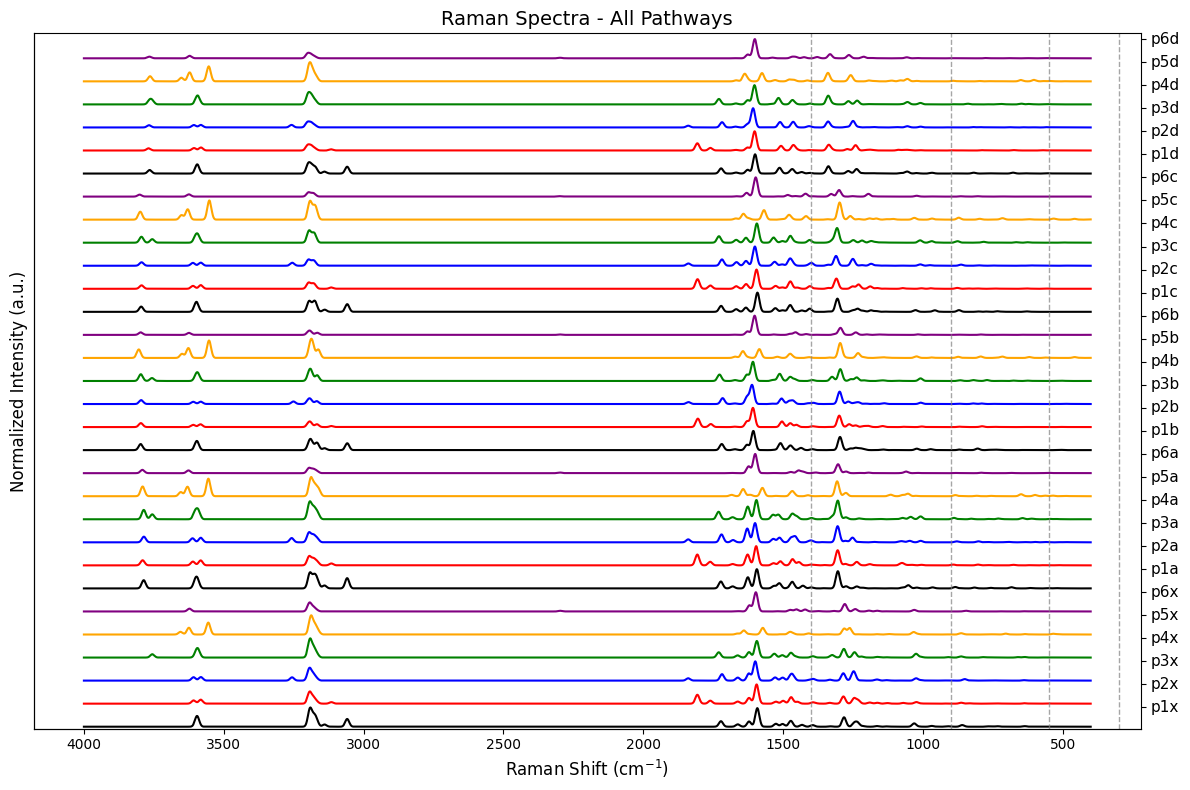

In [34]:
# With custom range and parameters
molecule_list = [
    "p1x", "p2x", "p3x", "p4x", "p5x", "p6x",
    "p1a", "p2a", "p3a", "p4a", "p5a", "p6a",
    "p1b", "p2b", "p3b", "p4b", "p5b", "p6b",
    "p1c", "p2c", "p3c", "p4c", "p5c", "p6c",
    "p1d", "p2d", "p3d", "p4d", "p5d", "p6d"
]

fig, ax = plot_stacked_raman_spectra(
    df, 
    molecule_list,
    shift_min=400,           # Instead of shift_range=(400, 4000)
    shift_max=4000,
    n_points=5000,
    fwhm=17.0,
    y_spacing=0.2,
    invert_x=True,           # Reverse x-axis
    region_boundaries=[300, 550, 900, 1400],
    colors=['black', 'red', 'blue', 'green', 'orange', 'purple'],
    order='ascending',
    figsize=(12, 8),
    title="Raman Spectra - All Pathways"
)
plt.show()

![](https://www.researchgate.net/publication/331500406/figure/fig3/AS:11431281212235055@1702568598624/a-Spectra-of-carbendazim-CBZ-A-Raman-spectrum-and-B-SERS-spectrum-of-10-M-CBZ.tif)

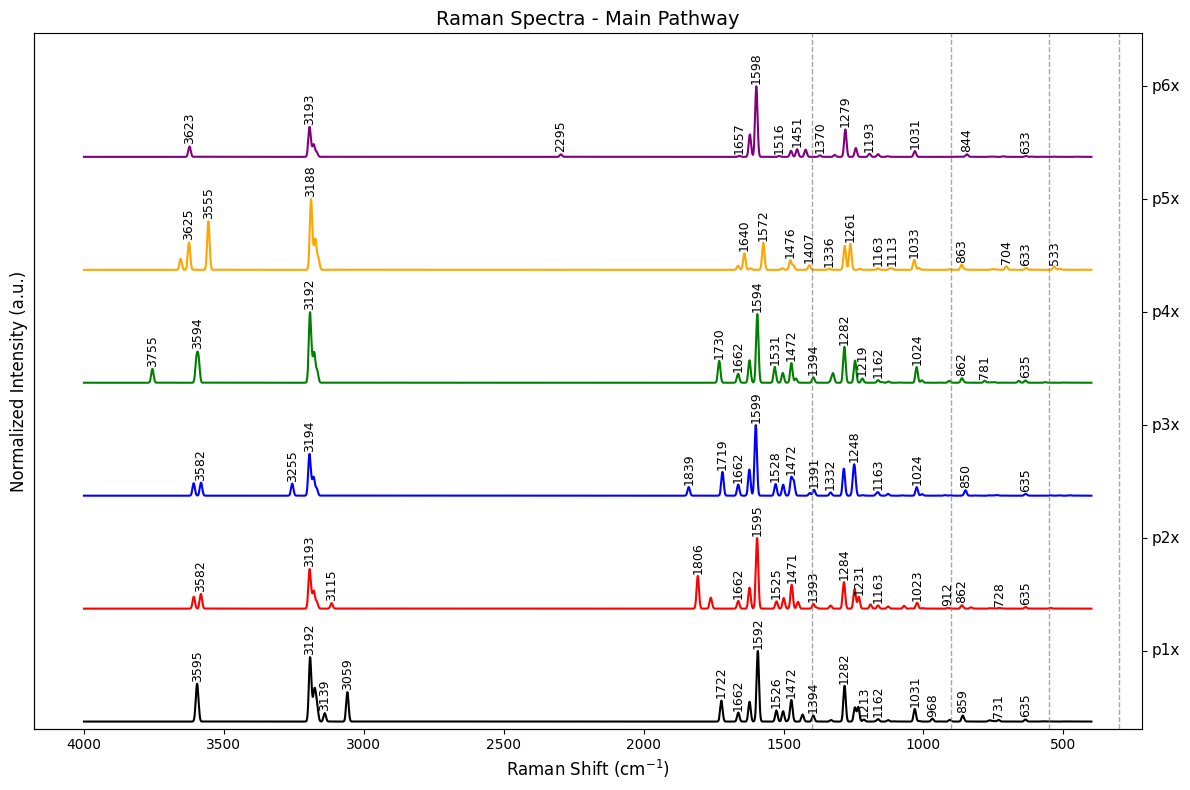

In [35]:
import matplotlib.pyplot as plt
molecule_list=["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"]
# Your existing code - works perfectly with the optimized function
fig, ax = plot_stacked_raman_spectra(
    df, 
    molecule_list,
    shift_min=400,
    shift_max=4000,
    n_points=5000,
    fwhm=10, # 17.0,
    y_spacing=0.6,
    invert_x=True,
    region_boundaries=[300, 550, 900, 1400],
    colors=['black', 'red', 'blue', 'green', 'orange', 'purple'],
    order='ascending',
    figsize=(12, 8),
    title="Raman Spectra - Main Pathway",
    
    # Label peaks above threshold
    label_peaks=True,
    peak_label_mode="threshold",
    peak_threshold=0.01,
    peak_min_distance=50,
    peak_label_format="{freq:.0f}",
    peak_label_offset=0.03
)
plt.show()

In [36]:
def plot_raman_discrete_continuous(
    df: pd.DataFrame,
    molecule_id: str,
    # Mode selection
    mode: str = "stacked",  # "stacked" or "overlapped"
    # Range parameters
    shift_min: float = 0,
    shift_max: float = 4000,
    n_points: int = 8000,
    # Broadening
    fwhm: float = 17.0,
    # Stacked mode parameters (mode="stacked")
    stick_height_fraction: float = 0.1,
    stick_color: str = "black",
    stick_width: float = 1.0,
    # Overlapped mode parameters (mode="overlapped")
    discrete_color: str = "red",
    discrete_width: float = 1.0,
    discrete_alpha: float = 0.6,
    # Continuous spectrum (both modes)
    continuous_color: str = "black",
    continuous_linewidth: float = 1.0,
    # Region boundaries
    region_boundaries: Optional[List[float]] = None,
    region_labels: Optional[List[str]] = None,
    # Plot styling
    figsize: tuple = (9, 5),
    title: Optional[str] = None,
    invert_x: bool = True
):
    """
    Plot Raman spectrum with two modes:
    - "stacked": Continuous spectrum on top + uniform-height sticks below (no y-axis)
    - "overlapped": Discrete bars (actual intensities) behind continuous line (with y-axis)
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing molecule data
    molecule_id : str
        Molecule ID to plot
    mode : str
        Display mode: "stacked" or "overlapped" (default: "stacked")
    shift_min : float
        Minimum Raman shift (cm⁻¹)
    shift_max : float
        Maximum Raman shift (cm⁻¹)
    n_points : int
        Number of points in continuous spectrum
    fwhm : float
        Full Width at Half Maximum for Gaussian broadening (cm⁻¹)
    
    Stacked Mode Parameters
    -----------------------
    stick_height_fraction : float
        Height of uniform sticks as fraction of spectrum max (default: 0.1)
    stick_color : str
        Color for sticks (default: "black")
    stick_width : float
        Width of sticks (linewidth) (default: 1.0)
    
    Overlapped Mode Parameters
    --------------------------
    discrete_color : str
        Color for discrete sticks (default: "red")
    discrete_width : float
        Width of discrete sticks (linewidth) (default: 1.0)
    discrete_alpha : float
        Transparency of discrete sticks, 0-1 (default: 0.6)
    
    continuous_color : str
        Color for continuous spectrum (default: "black")
    continuous_linewidth : float
        Line width for continuous spectrum (default: 1.0)
    region_boundaries : Optional[List[float]]
        Wavenumber positions for region boundaries
    region_labels : Optional[List[str]]
        Labels for regions between boundaries
    figsize : tuple
        Figure size (default: (9, 5))
    title : Optional[str]
        Plot title. If None, uses molecule_id
    invert_x : bool
        Invert x-axis (default: True)
    
    Returns
    -------
    fig, ax : matplotlib figure and axis
    
    Examples
    --------
    # Mode 1: Stacked (uniform sticks below, continuous on top)
    >>> fig, ax = plot_raman_discrete_continuous(df, "p1x", mode="stacked")
    
    # Mode 2: Overlapped (discrete bars behind continuous line)
    >>> fig, ax = plot_raman_discrete_continuous(
    ...     df, "p1x", 
    ...     mode="overlapped",
    ...     discrete_color="red",
    ...     discrete_width=1.5,
    ...     discrete_alpha=0.5,
    ...     continuous_color="black"
    ... )
    """
    
    # Find molecule
    mask = df["molecule_id"].str.contains(molecule_id, case=False, na=False, regex=False)
    if not mask.any():
        raise ValueError(f"Molecule '{molecule_id}' not found in DataFrame")
    
    dataset_index = df[mask].index[0]
    df_raman = pd.DataFrame(df["raman_spectrum"].iloc[dataset_index])
    
    # Default region boundaries
    if region_boundaries is None:
        region_boundaries = [500, 1000, 1800, 2800, 3200]
    
    # Define Raman shift grid
    shifts = np.linspace(shift_min, shift_max, n_points)
    
    # Gaussian broadening
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    # Build continuous spectrum
    spectrum = np.zeros_like(shifts)
    for _, row in df_raman.iterrows():
        nu0 = row["freq_cm-1"]
        inten = row["activity"]
        spectrum += inten * np.exp(-(shifts - nu0) ** 2 / (2 * sigma ** 2))
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add region boundaries
    for boundary in region_boundaries:
        ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    
    # Filter dataframe to range
    df_raman_filtered = df_raman[
        (df_raman["freq_cm-1"] >= shifts.min()) &
        (df_raman["freq_cm-1"] <= shifts.max())
    ]
    
    # === MODE 1: STACKED (uniform sticks below continuous) ===
    if mode == "stacked":
        # Plot continuous spectrum on top
        ax.plot(shifts, spectrum, color=continuous_color, lw=continuous_linewidth, zorder=2)
        
        # Calculate uniform stick height
        stick_height = spectrum.max() * stick_height_fraction if spectrum.max() > 0 else 0.1
        
        # Plot uniform-height sticks below (from -stick_height to 0)
        for _, row in df_raman_filtered.iterrows():
            ax.vlines(row["freq_cm-1"], -stick_height, 0, 
                     color=stick_color, linewidth=stick_width, zorder=1)
        
        # Set y-limits
        y_min = -stick_height * 1.2
        y_max = spectrum.max() * 1.1
        
        # Hide y-axis for stacked mode
        ax.yaxis.set_visible(False)
    
    # === MODE 2: OVERLAPPED (discrete bars with actual intensities behind continuous) ===
    elif mode == "overlapped":
        # Plot discrete sticks FIRST (behind continuous line)
        for _, row in df_raman_filtered.iterrows():
            ax.vlines(row["freq_cm-1"], 0, row["activity"],
                     color=discrete_color, linewidth=discrete_width, 
                     alpha=discrete_alpha, zorder=1)
        
        # Plot continuous spectrum ON TOP
        ax.plot(shifts, spectrum, color=continuous_color, lw=continuous_linewidth, 
               label="Continuous", zorder=2)
        
        # Set y-limits based on data
        y_min = 0
        y_max = max(spectrum.max(), df_raman_filtered["activity"].max()) * 1.1
        
        # Show y-axis with label
        ax.set_ylabel("Intensity (a.u.)", fontsize=12)
        
        # Add legend
        ax.legend(loc='upper right', frameon=False, fontsize=10)
    
    else:
        raise ValueError(f"Unknown mode '{mode}'. Use 'stacked' or 'overlapped'")
    
    # Add region labels if provided
    if region_labels is not None:
        extended_boundaries = [shift_max] + region_boundaries + [shift_min]
        label_y = y_max * 0.95
        
        for i in range(len(extended_boundaries) - 1):
            left = extended_boundaries[i]
            right = extended_boundaries[i + 1]
            middle = (left + right) / 2
            
            if i < len(region_labels):
                ax.text(middle, label_y, region_labels[i],
                       rotation=0, ha='center', va='top',
                       fontsize=9, color='gray', alpha=0.7)
    
    # Formatting
    ax.set_xlabel("Raman Shift (cm$^{-1}$)", fontsize=12)
    
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(shift_min, shift_max)
    
    # Hide spines
    for spine in ["top", "left", "right"]:
        ax.spines[spine].set_visible(False)
    
    if invert_x:
        ax.invert_xaxis()
    
    plot_title = title if title is not None else f"Raman Spectrum — {molecule_id}"
    plt.title(plot_title, fontsize=14)
    plt.tight_layout()
    
    return fig, ax

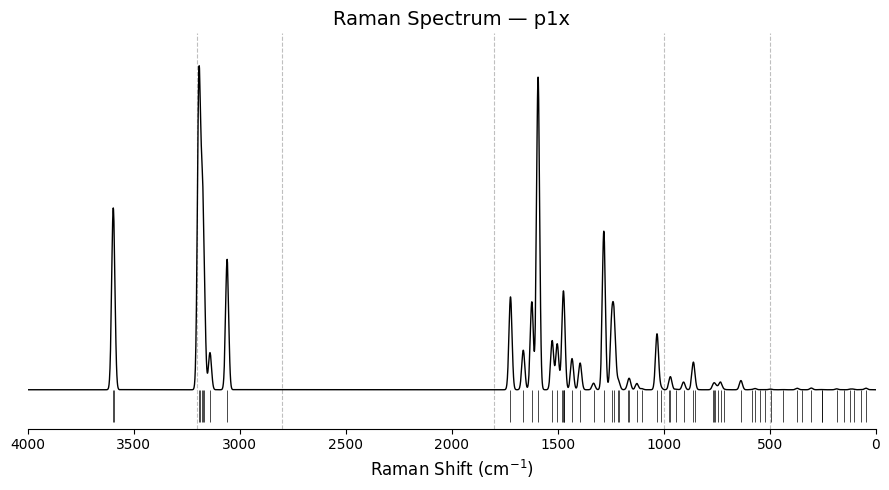

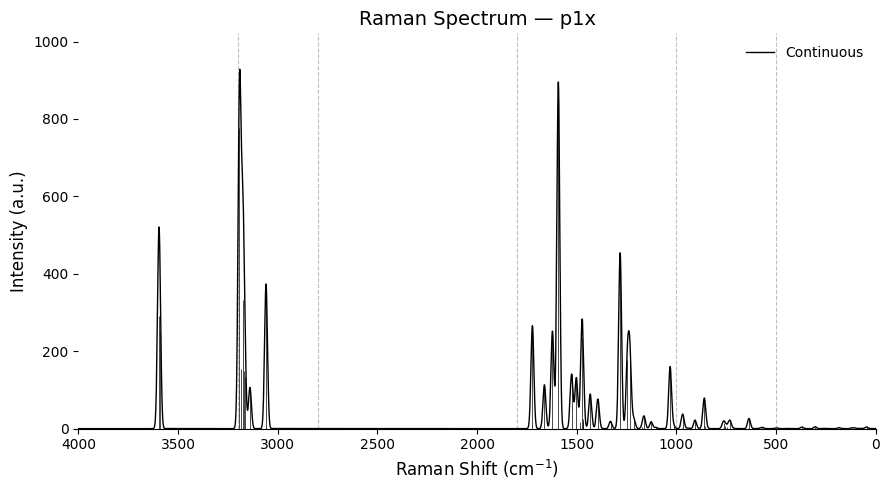

In [37]:
# Mode 1: STACKED - Uniform sticks below continuous spectrum (no y-axis)
fig, ax = plot_raman_discrete_continuous(
    df, "p1x",
    mode="stacked",
    stick_height_fraction=0.1,
    stick_color="black",
    stick_width=.5,
    continuous_color="black",
    fwhm=17
)
plt.show()

# Mode 2: OVERLAPPED - Discrete sticks (actual intensity) behind continuous line
fig, ax = plot_raman_discrete_continuous(
    df, "p1x",
    mode="overlapped",
    discrete_color="black",
    discrete_width=.5,
    discrete_alpha=1,
    continuous_color="black",
    fwhm=17
)
plt.show()

### 4. IR

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from typing import List, Optional, Dict, Tuple
from dataclasses import dataclass

@dataclass
class IRPeakLabelConfig:
    """Configuration for IR peak labeling."""
    enabled: bool = False
    mode: str = "top_n"  # "top_n", "threshold", "all", "ranges"
    top_n: int = 3
    threshold: float = 0.3  # Minimum dip depth (0-1 transmittance scale)
    ranges: Optional[List[Tuple[float, float]]] = None
    min_distance: float = 50.0
    offset: float = 0.05  # Offset BELOW peak (for transmittance dips)
    fontsize: int = 9
    format: str = "{freq:.0f}"
    assignments: Optional[Dict[Tuple[float, float], str]] = None
    molecules_to_label: Optional[List[int]] = None


def _validate_ir_inputs(df: pd.DataFrame, molecule_ids: List[str], labels: List[str]):
    """Validate input parameters for IR plotting."""
    if labels and len(labels) != len(molecule_ids):
        raise ValueError(f"Length of labels ({len(labels)}) must match molecule_ids ({len(molecule_ids)})")
    
    if df.empty or "molecule_id" not in df.columns or "ir_spectrum" not in df.columns:
        raise ValueError("DataFrame must contain 'molecule_id' and 'ir_spectrum' columns")


def _build_ir_spectrum(
    df_ir: pd.DataFrame,
    x: np.ndarray,
    sigma: float,
    concentration: float,
    path_length: float,
    scale_x: float,
    shift_x: float
) -> np.ndarray:
    """Build Gaussian-broadened IR transmittance spectrum."""
    # Calculate absorbance
    df_ir = df_ir.copy()
    df_ir["Absorbance"] = df_ir["eps"] * concentration * path_length
    
    # Build absorbance curve
    absorbance_curve = np.zeros_like(x)
    for _, row in df_ir.iterrows():
        freq = row["freq_cm-1"] * scale_x + shift_x
        inten = row["Absorbance"]
        absorbance_curve += inten * np.exp(-0.5 * ((x - freq) / sigma) ** 2)
    
    # Normalize absorbance
    if absorbance_curve.max() > 0:
        absorbance_curve /= absorbance_curve.max()
    
    # Convert to transmittance (0–1 scale)
    transmittance_curve = 10**(-absorbance_curve)
    t_min, t_max = transmittance_curve.min(), transmittance_curve.max()
    if t_max > t_min:
        transmittance_curve = (transmittance_curve - t_min) / (t_max - t_min)
    
    return transmittance_curve


def _load_ir_spectra(
    df: pd.DataFrame,
    molecule_ids: List[str],
    labels: List[str],
    x: np.ndarray,
    sigma: float,
    concentration: float,
    path_length: float,
    scale_x: float,
    shift_x: float
) -> Tuple[List[np.ndarray], List[str], List[str]]:
    """Load and process all IR spectra."""
    spectra = []
    valid_labels = []
    valid_ids = []
    
    for mol_id, label in zip(molecule_ids, labels):
        mask = df["molecule_id"].str.contains(mol_id, case=False, na=False, regex=False)
        
        if not mask.any():
            print(f"⚠️  Warning: Molecule '{mol_id}' not found, skipping")
            continue
        
        try:
            mol_idx = df[mask].index[0]
            df_ir = pd.DataFrame(df["ir_spectrum"].iloc[mol_idx])
            
            spectrum = _build_ir_spectrum(
                df_ir, x, sigma, concentration, path_length, scale_x, shift_x
            )
            
            spectra.append(spectrum)
            valid_labels.append(label)
            valid_ids.append(mol_id)
            
        except Exception as e:
            print(f"⚠️  Warning: Failed to process '{mol_id}': {e}")
            continue
    
    if not spectra:
        raise ValueError("No valid IR spectra found")
    
    return spectra, valid_labels, valid_ids


def _calculate_ir_offsets(spectra: List[np.ndarray], y_spacing: float) -> Tuple[List[float], float]:
    """Calculate vertical offsets for stacked IR spectra."""
    offsets = []
    current_top = 0
    global_top = 0
    
    for i, spectrum in enumerate(spectra):
        if i == 0:
            offset = 0
        else:
            prev_top = current_top
            this_bottom = spectrum.min()
            offset = prev_top - this_bottom + y_spacing
        
        current_top = offset + spectrum.max()
        global_top = max(global_top, current_top)
        offsets.append(offset)
    
    return offsets, global_top


def _select_ir_peaks_by_mode(
    peak_depths: np.ndarray,
    peak_freqs: np.ndarray,
    config: IRPeakLabelConfig
) -> List[int]:
    """Select IR peaks (transmittance dips) based on labeling mode."""
    if config.mode == "all":
        return list(range(len(peak_depths)))
    
    if config.mode == "top_n":
        # For IR: deeper dips = stronger peaks
        depth_order = np.argsort(peak_depths)[::-1]
        return sorted(depth_order[:config.top_n].tolist())
    
    if config.mode == "threshold":
        # Threshold is dip depth (0-1 scale)
        return [i for i, d in enumerate(peak_depths) if d >= config.threshold]
    
    if config.mode == "ranges":
        if not config.ranges:
            print("⚠️  Warning: peak_ranges required for mode 'ranges'")
            return []
        
        selected = []
        for i, freq in enumerate(peak_freqs):
            if any(min_f <= freq <= max_f for min_f, max_f in config.ranges):
                selected.append(i)
        return selected
    
    return []


def _add_ir_peak_labels(
    ax: plt.Axes,
    spectra: List[np.ndarray],
    x: np.ndarray,
    y_offsets: List[float],
    colors: List[str],
    config: IRPeakLabelConfig
):
    """Add peak labels BELOW transmittance dips for IR spectra."""
    if not config.enabled:
        return
    
    dx = x[1] - x[0]
    min_dist_samples = max(1, int(config.min_distance / dx))
    
    for spec_idx, spectrum in enumerate(spectra):
        if config.molecules_to_label is not None and spec_idx not in config.molecules_to_label:
            continue
        
        # For IR: find MINIMA (transmittance dips), not maxima
        # Invert spectrum to find dips as peaks
        inverted = 1.0 - spectrum
        
        peaks, _ = find_peaks(
            inverted,
            height=0.01,
            prominence=0.01,
            distance=min_dist_samples
        )
        
        if len(peaks) == 0:
            continue
        
        peak_freqs = x[peaks]
        peak_depths = inverted[peaks]  # Depth of dip (0-1 scale)
        
        # Select peaks to label
        selected = _select_ir_peaks_by_mode(peak_depths, peak_freqs, config)
        
        # Add labels BELOW the dips
        y_offset = y_offsets[spec_idx]
        
        for peak_idx in selected:
            freq = peak_freqs[peak_idx]
            dip_value = spectrum[peaks[peak_idx]]  # Actual transmittance value
            
            # Find assignment
            assignment = None
            if config.assignments:
                for (min_f, max_f), name in config.assignments.items():
                    if min_f <= freq <= max_f:
                        assignment = name
                        break
            
            # Format label
            label_text = config.format.format(
                freq=freq,
                intensity=dip_value,
                assign=assignment or ""
            )
            label_text = "\n".join(line for line in label_text.split("\n") if line.strip())
            
            # Position label BELOW the dip
            label_x = freq
            label_y = y_offset + dip_value - config.offset
            
            # Add vertical label below peak
            ax.text(
                label_x, label_y,
                label_text,
                ha='center',
                va='top',  # Align from top (label goes down)
                fontsize=config.fontsize,
                color='black',
                rotation=90
            )


def _add_experimental_ir_continuous(
    ax: plt.Axes,
    experimental_data: Dict,
    x: np.ndarray,
    y_offsets: List[float],
    y_spacing: float,
    exp_position: int
) -> Tuple[List[float], List[str], List[np.ndarray]]:
    """Add continuous experimental IR spectrum."""
    try:
        if "ir_wn" not in experimental_data or "transmitance" not in experimental_data:
            raise ValueError("experimental_data must contain 'ir_wn' and 'transmitance'")
        
        ir_interp = np.interp(x, experimental_data["ir_wn"], experimental_data["transmitance"])
        
        # Normalize to 0-1 scale
        if ir_interp.max() > 0:
            ir_interp = ir_interp / ir_interp.max()
        
        exp_position = np.clip(exp_position, 0, len(y_offsets) - 1)
        ref_offset = y_offsets[exp_position]
        exp_offset = ref_offset - (ir_interp.max() + y_spacing)
        
        ax.plot(x, ir_interp + exp_offset, color="black", lw=1.5, linestyle="--")
        
        y_offsets.insert(exp_position, exp_offset)
        return y_offsets, ["Experimental (cont.)"], [ir_interp]
        
    except Exception as e:
        print(f"⚠️  Warning: Could not plot experimental spectrum: {e}")
        return y_offsets, [], []


def _add_experimental_ir_aist(
    ax: plt.Axes,
    experimental_aist: Dict,
    x: np.ndarray,
    sigma: float,
    y_offsets: List[float],
    y_spacing: float
) -> Tuple[List[float], List[str], List[np.ndarray]]:
    """Add discrete experimental IR spectrum (AIST format)."""
    try:
        if "wavenumber" not in experimental_aist or "transmitance" not in experimental_aist:
            raise ValueError("experimental_aist must contain 'wavenumber' and 'transmitance'")
        
        wn_aist = experimental_aist["wavenumber"]
        tr_aist = experimental_aist["transmitance"]
        
        if tr_aist.max() > 0:
            tr_aist = tr_aist / tr_aist.max()
        
        # Broaden into smooth curve
        aist_curve = np.zeros_like(x)
        for wn, inten in zip(wn_aist, tr_aist):
            aist_curve += inten * np.exp(-0.5 * ((x - wn) / sigma) ** 2)
        
        # Normalize to 0-1 scale and invert (for transmittance dips)
        if aist_curve.max() > 0:
            aist_curve = aist_curve / aist_curve.max()
            aist_curve = 1.0 - aist_curve
        
        base_offset = y_offsets[0] if y_offsets else 0
        exp_offset_aist = base_offset - (aist_curve.max() + y_spacing)
        
        ax.plot(x, aist_curve + exp_offset_aist, color="red", lw=1.5, linestyle="-.")
        
        y_offsets.insert(0, exp_offset_aist)
        return y_offsets, ["Experimental (AIST)"], [aist_curve]
        
    except Exception as e:
        print(f"⚠️  Warning: Could not plot AIST spectrum: {e}")
        return y_offsets, [], []


def plot_stacked_ir_spectra(
    df: pd.DataFrame,
    molecule_ids: List[str],
    labels: Optional[List[str]] = None,
    experimental_data: Optional[Dict] = None,
    experimental_aist: Optional[Dict] = None,
    exp_position: int = 0,
    wavenumber_min: float = 400,
    wavenumber_max: float = 4000,
    n_points: int = 5000,
    fwhm: float = 20.0,
    y_spacing: float = 0.15,
    scale_x: float = 1.0,
    shift_x: float = 0.0,
    concentration: float = 0.01,
    path_length: float = 1.0,
    colors: Optional[List[str]] = None,
    region_boundaries: Optional[List[float]] = None,
    order: str = 'ascending',
    figsize: tuple = (12, 8),
    title: str = "IR Spectra",
    invert_x: bool = True,
    
    # Peak labeling parameters
    label_peaks: bool = False,
    peak_label_mode: str = "top_n",
    peak_top_n: int = 3,
    peak_threshold: float = 0.3,  # Dip depth threshold (0-1 scale)
    peak_ranges: Optional[List[Tuple[float, float]]] = None,
    peak_min_distance: float = 50.0,
    peak_label_offset: float = 0.05,
    peak_label_fontsize: int = 9,
    peak_label_format: str = "{freq:.0f}",
    peak_assignments: Optional[Dict[Tuple[float, float], str]] = None,
    label_only_molecules: Optional[List[int]] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot stacked IR spectra with optional vertical peak labels below transmittance dips.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'molecule_id' and 'ir_spectrum' columns
    molecule_ids : List[str]
        List of molecule identifiers
    labels : Optional[List[str]]
        Display labels (defaults to molecule_ids)
    experimental_data : Optional[Dict]
        Continuous experimental data: {'ir_wn': array, 'transmitance': array}
    experimental_aist : Optional[Dict]
        Discrete experimental data: {'wavenumber': array, 'transmitance': array}
    exp_position : int
        Position to insert experimental spectrum
    wavenumber_min, wavenumber_max : float
        Wavenumber range (cm⁻¹)
    n_points : int
        Number of interpolation points
    fwhm : float
        Full width at half maximum for broadening
    y_spacing : float
        Vertical spacing between spectra (0-1 scale)
    scale_x, shift_x : float
        Frequency scaling and shift
    concentration : float
        Sample concentration (mol/L)
    path_length : float
        Path length (cm)
    colors : Optional[List[str]]
        Colors for each spectrum
    region_boundaries : Optional[List[float]]
        Vertical lines at wavenumbers
    order : str
        'ascending' or 'descending'
    figsize : tuple
        Figure size
    title : str
        Plot title
    invert_x : bool
        Invert x-axis (IR convention)
    
    Peak Labeling Parameters
    -------------------------
    label_peaks : bool
        Enable peak labeling below dips
    peak_label_mode : str
        "top_n", "threshold", "all", "ranges"
    peak_top_n : int
        Number of deepest dips to label
    peak_threshold : float
        Minimum dip depth (0-1 scale)
    peak_ranges : Optional[List[Tuple[float, float]]]
        Wavenumber ranges to label
    peak_min_distance : float
        Minimum spacing between labels (cm⁻¹)
    peak_label_offset : float
        Vertical offset below dip (0-1 scale)
    peak_label_fontsize : int
        Label font size
    peak_label_format : str
        Format: {freq}, {intensity}, {assign}
    peak_assignments : Optional[Dict]
        Functional group assignments
    label_only_molecules : Optional[List[int]]
        Indices of molecules to label
    
    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    
    Examples
    --------
    >>> fig, ax = plot_stacked_ir_spectra(
    ...     df, ["mol1", "mol2"],
    ...     label_peaks=True,
    ...     peak_label_mode="top_n",
    ...     peak_top_n=5,
    ...     y_spacing=0.3
    ... )
    """
    
    # Setup defaults
    if colors is None:
        colors = ['black', 'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan']
    
    if labels is None:
        labels = molecule_ids.copy()
    
    # Validate
    _validate_ir_inputs(df, molecule_ids, labels)
    
    # Configuration
    peak_config = IRPeakLabelConfig(
        enabled=label_peaks,
        mode=peak_label_mode,
        top_n=peak_top_n,
        threshold=peak_threshold,
        ranges=peak_ranges,
        min_distance=peak_min_distance,
        offset=peak_label_offset,
        fontsize=peak_label_fontsize,
        format=peak_label_format,
        assignments=peak_assignments,
        molecules_to_label=label_only_molecules
    )
    
    # Setup grid and broadening
    x = np.linspace(wavenumber_min, wavenumber_max, n_points)
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    # Load spectra
    spectra, valid_labels, valid_ids = _load_ir_spectra(
        df, molecule_ids, labels, x, sigma, concentration, path_length, scale_x, shift_x
    )
    
    # Apply ordering
    if order.lower() == 'descending':
        spectra = spectra[::-1]
        valid_labels = valid_labels[::-1]
    elif order.lower() != 'ascending':
        print(f"⚠️  Warning: Unknown order '{order}', using 'ascending'")
    
    # Calculate offsets
    y_offsets, global_top = _calculate_ir_offsets(spectra, y_spacing)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot spectra
    for i, (spectrum, label) in enumerate(zip(spectra, valid_labels)):
        color = colors[i % len(colors)]
        ax.plot(x, spectrum + y_offsets[i], color=color, lw=1.5)
    
    # Add experimental spectra
    all_spectra = spectra.copy()
    all_labels = valid_labels.copy()
    
    if experimental_data is not None:
        y_offsets, exp_labels, exp_spectra = _add_experimental_ir_continuous(
            ax, experimental_data, x, y_offsets, y_spacing, exp_position
        )
        all_labels = all_labels[:exp_position] + exp_labels + all_labels[exp_position:]
        all_spectra = all_spectra[:exp_position] + exp_spectra + all_spectra[exp_position:]
    
    if experimental_aist is not None:
        y_offsets, aist_labels, aist_spectra = _add_experimental_ir_aist(
            ax, experimental_aist, x, sigma, y_offsets, y_spacing
        )
        all_labels = aist_labels + all_labels
        all_spectra = aist_spectra + all_spectra
    
    # Add peak labels (only for computational spectra, not experimental)
    _add_ir_peak_labels(ax, spectra, x, y_offsets, colors, peak_config)
    
    # Add region boundaries
    if region_boundaries:
        for boundary in region_boundaries:
            ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    
    # Formatting
    ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
    ax.set_ylabel("Normalized Transmittance (a.u.)", fontsize=12)
    
    # Dynamic padding based on label configuration
    if label_peaks:
        # For vertical labels below dips, estimate space needed
        # Wavenumber labels are typically 3-4 digits (e.g., "3000")
        # Rotated 90°, so width becomes vertical height
        estimated_label_length = peak_config.fontsize * 0.08  # Convert to 0-1 scale
        bottom_padding = max(0.4, peak_config.offset + estimated_label_length)
    else:
        bottom_padding = 0.1
    
    top_padding = 0.2
    ax.set_ylim(min(y_offsets) - bottom_padding, global_top + top_padding)
    
    ax.spines["right"].set_visible(False)
    ax.set_yticks([])
    
    # Right y-axis labels
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    label_positions = [offset + spec.max() for spec, offset in zip(all_spectra, y_offsets)]
    ax2.set_yticks(label_positions)
    ax2.set_yticklabels(all_labels, fontsize=11, va="center")
    ax2.spines["top"].set_visible(False)
    
    if invert_x:
        ax.invert_xaxis()
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    return fig, ax


# Preset IR functional group assignments
IR_ASSIGNMENTS = {
    (3200, 3600): "O-H",
    (3000, 3100): "=C-H",
    (2850, 2960): "C-H",
    (2100, 2260): "C≡C/C≡N",
    (1650, 1750): "C=O",
    (1600, 1680): "C=C",
    (1000, 1300): "C-O",
    (650, 900): "C-H bend"
}

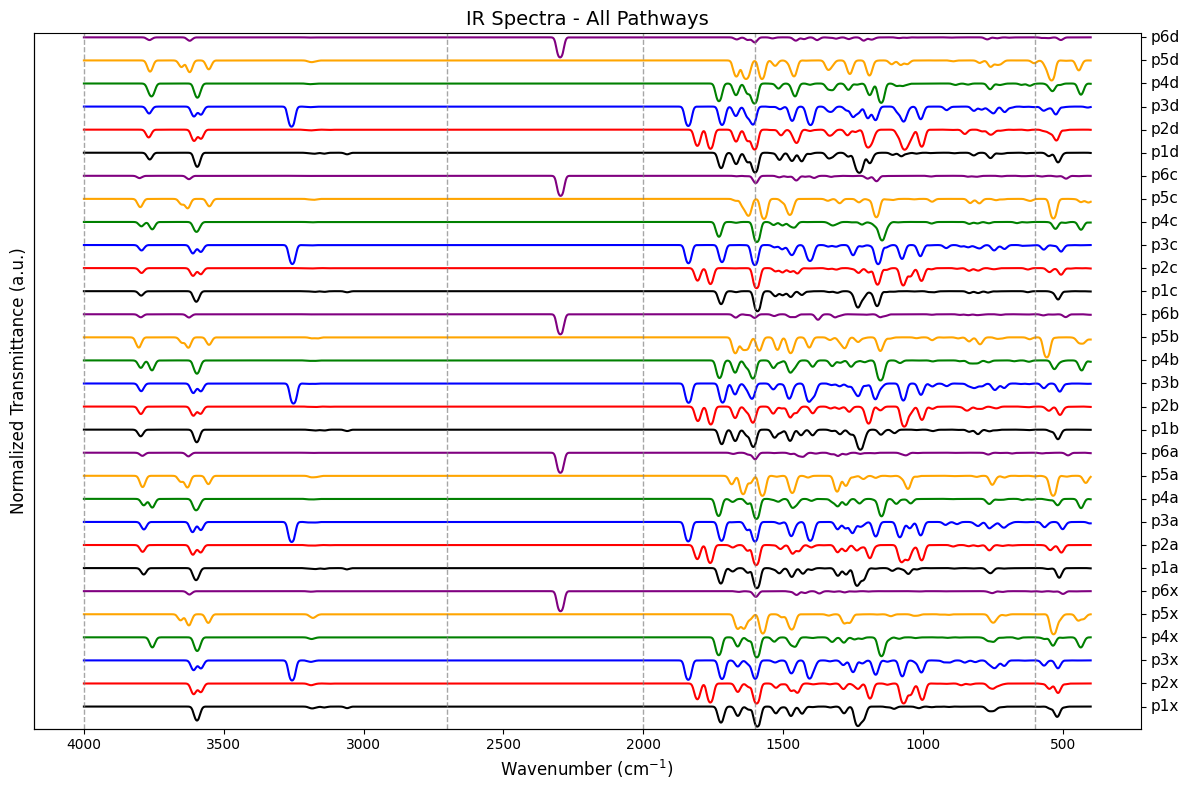

In [39]:
# With all parameters customized
molecule_list = [
    "p1x", "p2x", "p3x", "p4x", "p5x", "p6x",
    "p1a", "p2a", "p3a", "p4a", "p5a", "p6a",
    "p1b", "p2b", "p3b", "p4b", "p5b", "p6b",
    "p1c", "p2c", "p3c", "p4c", "p5c", "p6c",
    "p1d", "p2d", "p3d", "p4d", "p5d", "p6d"
]

fig, ax = plot_stacked_ir_spectra(
    df,
    molecule_list,
    wavenumber_min=400,
    wavenumber_max=4000,
    n_points=5000,
    fwhm=20.0,
    y_spacing=0.15,
    scale_x=1.0,
    shift_x=0.0,
    concentration=0.01,
    path_length=1.0,
    region_boundaries=[4000, 2700, 2000, 1600, 600],
    colors=['black', 'red', 'blue', 'green', 'orange', 'purple'],
    order='ascending',
    figsize=(12, 8),
    title="IR Spectra - All Pathways",
    invert_x=True
)
plt.show()

| Wavenumber (cm⁻¹) | Assignment / Functional Group                              |
| ----------------- | ---------------------------------------------------------- |
| ~ 3320 cm⁻¹       | N–H (secondary amine) stretch                              |
| ~ 1710 cm⁻¹       | C=O (carbamate) stretch                                    |
| ~ 1627 cm⁻¹       | C=O + C=N stretch of heterocycle                           |
| ~ 1591 cm⁻¹       | Aromatic C–C + C=N stretch                                 |
| ~ 1266 cm⁻¹       | C–O stretch (carbamate)                                    |
| ~ 1093 cm⁻¹       | C–O / C–N stretch                                          |
| ~ 726 cm⁻¹        | Out-of-plane ring vibration of heterocycle / aromatic ring |


![](./pic/Narcim.jpg)

![](./pic/bbrm_a_1911921_f0005a_c.jpg)

![](./pic/Hexar.jpg)

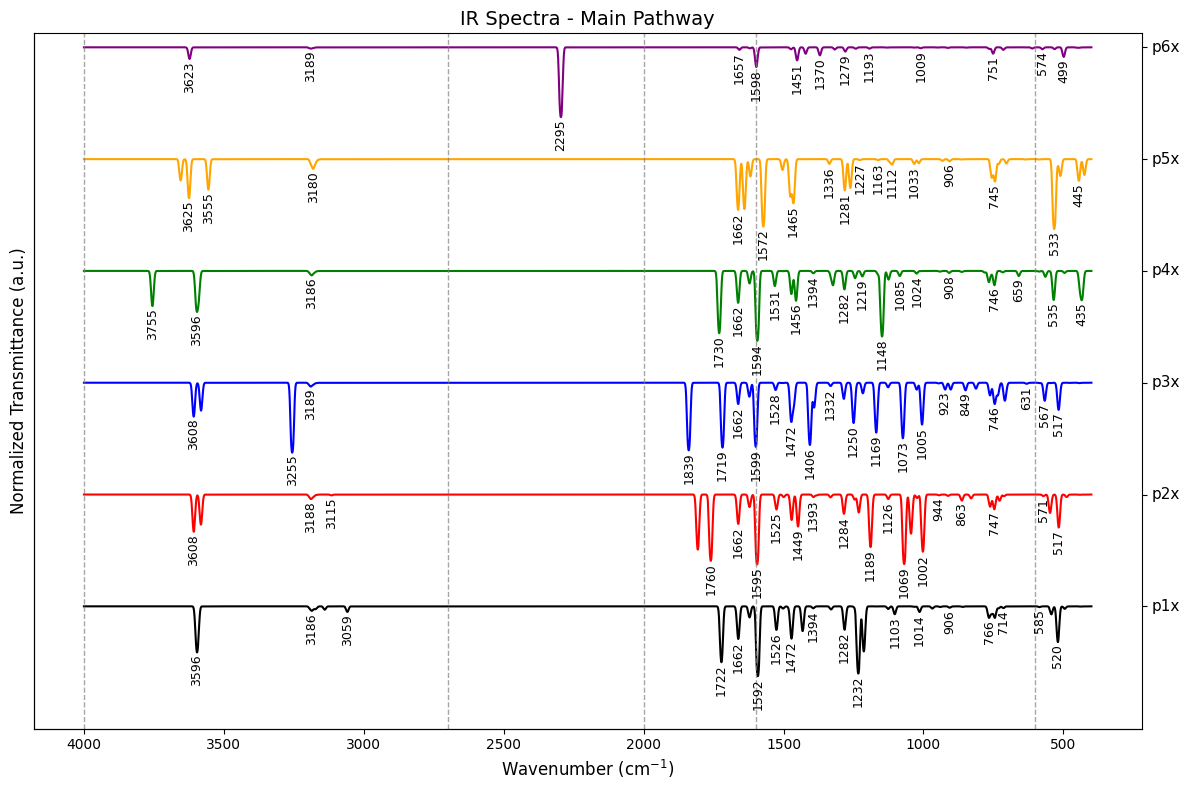

In [40]:
molecule_list = ["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"]

fig, ax = plot_stacked_ir_spectra(
    df, 
    molecule_list,
    fwhm=10, # 17.0,
    y_spacing=0.6,
    invert_x=True,
    region_boundaries=[4000, 2700, 2000, 1600, 600],
    colors=['black', 'red', 'blue', 'green', 'orange', 'purple'],
    order='ascending',
    figsize=(12, 8),
    title="IR Spectra - Main Pathway",
    
    # Label peaks above threshold
    label_peaks=True,
    peak_label_mode="threshold",
    peak_threshold=0.01,
    peak_min_distance=50,
    peak_label_format="{freq:.0f}",
    peak_label_offset=0.03
)
plt.show()

In [41]:
def plot_ir_discrete_continuous(
    df: pd.DataFrame,
    molecule_id: str,
    # Mode selection
    mode: str = "stacked",  # "stacked" or "overlapped"
    # Range parameters
    wavenumber_min: float = 400,
    wavenumber_max: float = 4000,
    n_points: int = 8000,
    # Broadening
    fwhm: float = 20.0,
    # Beer-Lambert parameters
    concentration: float = 0.01,  # mol/L
    path_length: float = 1.0,     # cm
    # Stick spectrum (both modes)
    stick_height_fraction: float = 0.1,
    show_sticks: bool = True,
    stick_color: str = "black",
    stick_width: float = 1.0,
    # Overlapped mode specific
    stick_alpha: float = 0.6,
    # Continuous spectrum (both modes)
    show_continuous: bool = True,
    continuous_color: str = "black",
    continuous_linewidth: float = 1.0,
    # Region boundaries
    region_boundaries: Optional[List[float]] = None,
    region_labels: Optional[List[str]] = None,
    # Plot styling
    figsize: tuple = (9, 5),
    title: Optional[str] = None,
    invert_x: bool = True,
    show_ylabel: bool = False
):
    """
    Plot IR spectrum with two modes (both using transmittance):
    - "stacked": Continuous spectrum + uniform-height sticks above baseline (100%)
    - "overlapped": Discrete sticks (transmittance) behind continuous line
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing molecule data
    molecule_id : str
        Molecule ID to plot
    mode : str
        Display mode: "stacked" or "overlapped" (default: "stacked")
    wavenumber_min : float
        Minimum wavenumber (cm⁻¹)
    wavenumber_max : float
        Maximum wavenumber (cm⁻¹)
    n_points : int
        Number of points in continuous spectrum
    fwhm : float
        Full Width at Half Maximum for Gaussian broadening (cm⁻¹)
    concentration : float
        Sample concentration in mol/L (default: 0.01)
    path_length : float
        Path length in cm (default: 1.0)
    stick_height_fraction : float
        Height of sticks as fraction of spectrum range (default: 0.1)
        In stacked mode: uniform height above baseline (100%)
        In overlapped mode: not used (actual transmittance shown)
    show_sticks : bool
        Show discrete stick spectrum (default: True)
    stick_color : str
        Color for sticks (default: "black")
    stick_width : float
        Width of sticks (linewidth) (default: 1.0)
    stick_alpha : float
        Transparency of sticks in overlapped mode, 0-1 (default: 0.6)
    show_continuous : bool
        Show continuous spectrum (default: True)
    continuous_color : str
        Color for continuous spectrum (default: "black")
    continuous_linewidth : float
        Line width for continuous spectrum (default: 1.0)
    region_boundaries : Optional[List[float]]
        Wavenumber positions for region boundaries
    region_labels : Optional[List[str]]
        Labels for regions between boundaries
    figsize : tuple
        Figure size (default: (9, 5))
    title : Optional[str]
        Plot title. If None, uses molecule_id
    invert_x : bool
        Invert x-axis (IR convention, default: True)
    show_ylabel : bool
        Show y-axis label (default: False)
    
    Returns
    -------
    fig, ax : matplotlib figure and axis
    
    Examples
    --------
    # Mode 1: Stacked (uniform sticks above baseline)
    >>> fig, ax = plot_ir_discrete_continuous(
    ...     df, "p1x",
    ...     mode="stacked",
    ...     stick_height_fraction=0.1,
    ...     fwhm=20
    ... )
    
    # Mode 2: Overlapped (discrete sticks behind continuous line)
    >>> fig, ax = plot_ir_discrete_continuous(
    ...     df, "p1x", 
    ...     mode="overlapped",
    ...     stick_color="red",
    ...     stick_width=1.5,
    ...     stick_alpha=0.5,
    ...     continuous_color="black",
    ...     fwhm=20
    ... )
    
    # Continuous only (no sticks)
    >>> fig, ax = plot_ir_discrete_continuous(
    ...     df, "p1x",
    ...     show_sticks=False,
    ...     continuous_color="blue"
    ... )
    """
    
    # Find molecule
    mask = df["molecule_id"].str.contains(molecule_id, case=False, na=False, regex=False)
    if not mask.any():
        raise ValueError(f"Molecule '{molecule_id}' not found in DataFrame")
    
    dataset_index = df[mask].index[0]
    df_ir = pd.DataFrame(df["ir_spectrum"].iloc[dataset_index])
    
    # Default region boundaries
    if region_boundaries is None:
        region_boundaries = [4000, 2700, 2000, 1600, 600]
    
    # Define wavenumber grid
    wavenumbers = np.linspace(wavenumber_min, wavenumber_max, n_points)
    
    # Gaussian broadening
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    # Calculate absorbance (Beer-Lambert Law: A = ε × c × l)
    df_ir["Absorbance"] = df_ir["eps"] * concentration * path_length
    
    # Build continuous absorbance spectrum
    absorbance_curve = np.zeros_like(wavenumbers)
    for _, row in df_ir.iterrows():
        nu0 = row["freq_cm-1"]
        inten = row["Absorbance"]
        absorbance_curve += inten * np.exp(-0.5 * ((wavenumbers - nu0) / sigma) ** 2)
    
    # Convert to transmittance: T = 10^(-A) × 100
    transmittance_curve = 10**(-absorbance_curve) * 100
    
    # Convert discrete stick absorbances to transmittance
    df_ir["Transmittance"] = 10**(-df_ir["Absorbance"]) * 100
    
    # Normalize continuous spectrum to 0-100 range
    t_min, t_max = transmittance_curve.min(), transmittance_curve.max()
    if t_max > t_min:
        transmittance_curve = (transmittance_curve - t_min) / (t_max - t_min) * 100
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add region boundaries
    if region_boundaries is not None:
        for boundary in region_boundaries:
            ax.axvline(x=float(boundary), color='gray', linestyle='--', alpha=0.7, linewidth=1)
    
    # Filter dataframe to range
    df_ir_filtered = df_ir[
        (df_ir["freq_cm-1"] >= wavenumbers.min()) &
        (df_ir["freq_cm-1"] <= wavenumbers.max())
    ]
    
    # Calculate spectrum range for stick height
    spectrum_range = transmittance_curve.max() - transmittance_curve.min()
    stick_height = spectrum_range * stick_height_fraction
    
    # === MODE 1: STACKED (uniform sticks above baseline at 100%) ===
    if mode == "stacked":
        # Plot continuous spectrum
        if show_continuous:
            ax.plot(wavenumbers, transmittance_curve, color=continuous_color, 
                   lw=continuous_linewidth, zorder=2)
        
        # Plot uniform-height sticks above baseline (from 100 to 100 + stick_height)
        if show_sticks:
            for _, row in df_ir_filtered.iterrows():
                ax.vlines(row["freq_cm-1"], 100, 100 + stick_height, 
                         color=stick_color, linewidth=stick_width, zorder=1)
        
        # Set y-limits
        y_min = transmittance_curve.min() - stick_height * 0.2
        y_max = 100 + stick_height * 1.2 if show_sticks else 105
    
    # === MODE 2: OVERLAPPED (discrete sticks with transmittance behind continuous) ===
    elif mode == "overlapped":
        # Normalize discrete transmittances to match continuous spectrum range
        t_discrete_min = df_ir_filtered["Transmittance"].min()
        t_discrete_max = df_ir_filtered["Transmittance"].max()
        
        if t_discrete_max > t_discrete_min:
            df_ir_filtered = df_ir_filtered.copy()
            df_ir_filtered["Transmittance_normalized"] = (
                (df_ir_filtered["Transmittance"] - t_discrete_min) / 
                (t_discrete_max - t_discrete_min) * 100
            )
        else:
            df_ir_filtered["Transmittance_normalized"] = df_ir_filtered["Transmittance"]
        
        # Plot discrete sticks FIRST (behind continuous line)
        if show_sticks:
            for _, row in df_ir_filtered.iterrows():
                ax.vlines(row["freq_cm-1"], 100, row["Transmittance_normalized"],
                         color=stick_color, linewidth=stick_width, 
                         alpha=stick_alpha, zorder=1)
        
        # Plot continuous spectrum ON TOP
        if show_continuous:
            ax.plot(wavenumbers, transmittance_curve, color=continuous_color, 
                   lw=continuous_linewidth, zorder=2)
        
        # Set y-limits (inverted scale for transmittance)
        y_max = 105
        y_min = min(transmittance_curve.min(), 
                    df_ir_filtered["Transmittance_normalized"].min() if show_sticks else 100) - 5
    
    else:
        raise ValueError(f"Unknown mode '{mode}'. Use 'stacked' or 'overlapped'")
    
    # Add region labels if provided
    if region_labels is not None:
        extended_boundaries = [wavenumber_max] + region_boundaries + [wavenumber_min]
        label_y = y_max * 0.98
        
        for i in range(len(extended_boundaries) - 1):
            left = extended_boundaries[i]
            right = extended_boundaries[i + 1]
            middle = (left + right) / 2
            
            if i < len(region_labels):
                ax.text(middle, label_y, region_labels[i],
                       rotation=0, ha='center', va='bottom',
                       fontsize=9, color='gray', alpha=0.7)
    
    # Formatting
    ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
    if show_ylabel:
        ax.set_ylabel("Transmittance (%)", fontsize=12)
    
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(wavenumber_min, wavenumber_max)
    
    # Hide spines
    for spine in ["left", "right"]:
        ax.spines[spine].set_visible(False)
    
    # Hide y-axis unless requested
    if not show_ylabel:
        ax.yaxis.set_visible(False)
    
    if invert_x:
        ax.invert_xaxis()
    
    plot_title = title if title is not None else f"IR Spectrum — {molecule_id}"
    plt.title(plot_title, fontsize=14)
    plt.tight_layout()
    
    return fig, ax

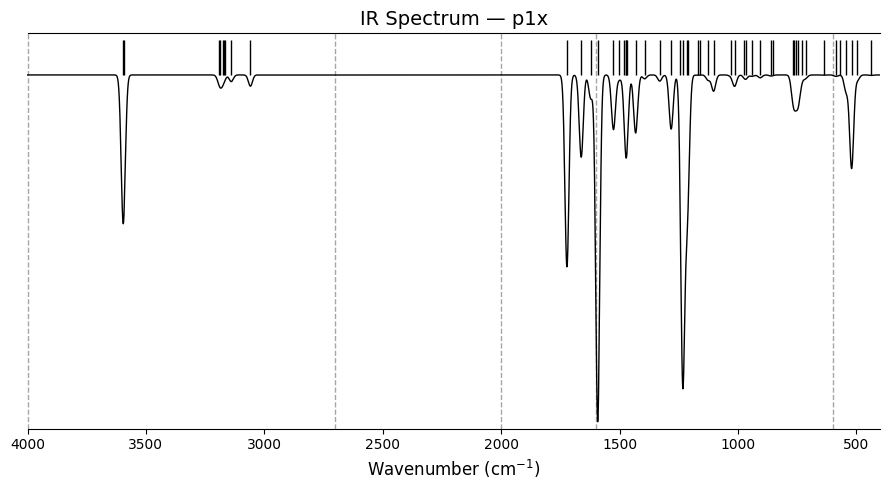

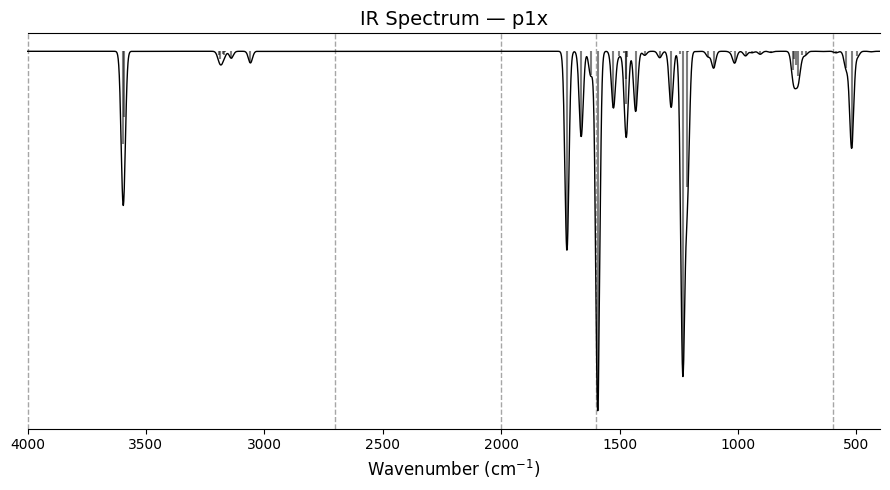

In [42]:
# Mode 1: STACKED - Uniform sticks above baseline (100%)
fig, ax = plot_ir_discrete_continuous(
    df, "p1x",
    mode="stacked",
    stick_height_fraction=0.1,
    stick_color="black",
    stick_width=1.0,
    continuous_color="black",
    fwhm=20
)
plt.show()

# Mode 2: OVERLAPPED - Discrete sticks (actual absorbance) behind continuous line
fig, ax = plot_ir_discrete_continuous(
    df, "p1x",
    mode="overlapped",
    stick_color="black",
    stick_width=1.5,
    stick_alpha=0.5,
    continuous_color="black",
    fwhm=20
)
plt.show()

### 5. Absorption

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from typing import List, Optional, Dict, Tuple
from dataclasses import dataclass

@dataclass
class PeakLabelConfig:
    """Configuration for peak labeling."""
    enabled: bool = False
    mode: str = "top_n"
    top_n: int = 3
    threshold: float = 0.3
    ranges: Optional[List[Tuple[float, float]]] = None
    min_distance: float = 20.0
    offset: float = 0.05
    fontsize: int = 9
    format: str = "{wavelength:.0f}"
    assignments: Optional[Dict[Tuple[float, float], str]] = None
    molecules_to_label: Optional[List[int]] = None


def _select_peaks_by_mode(peak_heights, peak_wavelengths, config):
    """Select peaks based on labeling mode."""
    if config.mode == "all":
        return list(range(len(peak_heights)))
    
    if config.mode == "top_n":
        height_order = np.argsort(peak_heights)[::-1]
        return sorted(height_order[:config.top_n].tolist())
    
    if config.mode == "threshold":
        return [i for i, h in enumerate(peak_heights) if h >= config.threshold]
    
    if config.mode == "ranges":
        if not config.ranges:
            print("⚠️  Warning: peak_ranges required for mode 'ranges'")
            return []
        return [i for i, wl in enumerate(peak_wavelengths) 
                if any(min_wl <= wl <= max_wl for min_wl, max_wl in config.ranges)]
    
    return []


def _find_assignment(wavelength, assignments):
    """Find spectral region assignment for a wavelength."""
    if not assignments:
        return None
    
    for (min_wl, max_wl), name in assignments.items():
        if min_wl <= wavelength <= max_wl:
            return name
    return None


def _add_peak_labels(ax, spectra, wavelengths, y_offsets, colors, config):
    """Add peak labels to spectra."""
    if not config.enabled:
        return
    
    dx = wavelengths[1] - wavelengths[0]
    min_dist_samples = max(1, int(config.min_distance / dx))
    
    for spec_idx, spectrum in enumerate(spectra):
        if config.molecules_to_label is not None and spec_idx not in config.molecules_to_label:
            continue
        
        peaks, _ = find_peaks(spectrum, height=0.01, prominence=0.01, distance=min_dist_samples)
        
        if len(peaks) == 0:
            continue
        
        peak_wavelengths = wavelengths[peaks]
        peak_heights = spectrum[peaks]
        selected = _select_peaks_by_mode(peak_heights, peak_wavelengths, config)
        y_offset = y_offsets[spec_idx]
        
        for peak_idx in selected:
            wl = peak_wavelengths[peak_idx]
            height = peak_heights[peak_idx]
            assignment = _find_assignment(wl, config.assignments)
            
            label_text = config.format.format(
                wavelength=wl, intensity=height, assign=assignment or ""
            )
            label_text = "\n".join(line for line in label_text.split("\n") if line.strip())
            
            ax.text(wl, y_offset + height + config.offset, label_text,
                   ha='center', va='bottom', fontsize=config.fontsize,
                   color='black', rotation=90)


def _apply_broadening_to_spectrum(wl_grid, spectrum_data, fwhm_nm):
    """
    Apply Gaussian broadening to any spectrum in wavelength space.
    
    Parameters:
    -----------
    wl_grid : np.ndarray
        Wavelength grid in nm
    spectrum_data : np.ndarray
        Original spectrum intensities
    fwhm_nm : float
        Full Width at Half Maximum in nm
    
    Returns:
    --------
    broadened : np.ndarray
        Broadened spectrum
    """
    if fwhm_nm <= 0:
        return spectrum_data
    
    # Convert FWHM to sigma: σ = FWHM / (2√(2ln2))
    sigma_nm = fwhm_nm / (2 * np.sqrt(2 * np.log(2)))
    
    # Create Gaussian kernel
    # Kernel size: ~6 sigma to capture >99.7% of Gaussian
    kernel_half_width = int(3 * sigma_nm / (wl_grid[1] - wl_grid[0]))
    kernel_size = 2 * kernel_half_width + 1
    
    if kernel_size < 3:
        return spectrum_data  # FWHM too small to matter
    
    # Create Gaussian kernel
    x = np.linspace(-kernel_half_width, kernel_half_width, kernel_size) * (wl_grid[1] - wl_grid[0])
    kernel = np.exp(-(x**2) / (2 * sigma_nm**2))
    kernel = kernel / kernel.sum()  # Normalize
    
    # Apply convolution
    broadened = np.convolve(spectrum_data, kernel, mode='same')
    
    return broadened


def _get_tddft_spectrum(mol_row, spectrum_type='electric', wavelength_range=(200, 800)):
    """
    Extract TDDFT absorption spectrum from electric or velocity dipole data.
    Returns stick spectrum (discrete transitions) for broadening later.
    
    Parameters:
    -----------
    mol_row : pd.Series
        Row from DataFrame containing spectrum data
    spectrum_type : str
        'electric' for electric_dipole_spectrum or 'velocity' for velocity_dipole_spectrum
    wavelength_range : tuple
        (min_wl, max_wl) in nm
    
    Returns:
    --------
    wavelengths : np.ndarray
        Wavelength array in nm
    intensities : np.ndarray
        Stick spectrum (zeros with spikes at transition wavelengths)
    """
    # Select spectrum column
    spec_col = 'velocity_dipole_spectrum' if spectrum_type == 'velocity' else 'electric_dipole_spectrum'
    
    if spec_col not in mol_row.index:
        raise ValueError(f"Column '{spec_col}' not found in DataFrame")
    
    spec_data = mol_row[spec_col]
    
    if not isinstance(spec_data, dict) or 'abs' not in spec_data:
        raise ValueError(f"Invalid spectrum data format for {spec_col}")
    
    # Extract absorption data
    abs_df = spec_data['abs']
    
    # Get wavelengths and oscillator strengths
    # Convert energy (eV) to wavelength (nm): λ = 1239.84 / E
    if 'energy_ev' in abs_df.columns:
        transition_wl = 1239.84 / abs_df['energy_ev'].values
    elif 'energy_cm1' in abs_df.columns:
        # Convert cm⁻¹ to eV: E(eV) = E(cm⁻¹) * 0.00012398
        transition_wl = 1239.84 / (abs_df['energy_cm1'].values * 0.00012398)
    else:
        raise ValueError("No energy column found in absorption spectrum")
    
    fosc = abs_df['fosc'].values
    
    # Create wavelength grid
    wl_min, wl_max = wavelength_range
    wl_grid = np.linspace(wl_min, wl_max, 5000)
    
    # Create stick spectrum
    spectrum = np.zeros_like(wl_grid)
    
    # Add sticks at transition wavelengths
    for wl, f in zip(transition_wl, fosc):
        if wl_min <= wl <= wl_max and f > 0:
            # Find nearest grid point
            idx = np.argmin(np.abs(wl_grid - wl))
            spectrum[idx] += f
    
    # Normalize
    if spectrum.max() > 0:
        spectrum = spectrum / spectrum.max()
    
    return wl_grid, spectrum


def plot_stacked_uvvis_spectra(
    df: pd.DataFrame,
    molecule_ids: List[str],
    labels: Optional[List[str]] = None,
    
    # Spectrum source options
    use_tddft: bool = False,
    tddft_type: str = 'electric',
    fwhm: Optional[float] = None,  # FWHM in nm for broadening
    
    experimental_data: Optional[Dict] = None,
    exp_position: int = 0,
    wavelength_min: float = 200,
    wavelength_max: float = 600,
    n_points: int = 5000,
    y_spacing: float = 0.2,
    colors: Optional[List[str]] = None,
    region_boundaries: Optional[List[float]] = None,
    order: str = 'ascending',
    figsize: tuple = (12, 8),
    title: str = "UV-Vis Absorption Spectra",
    invert_x: bool = False,
    bottom_margin: float = 0.3,
    
    # Peak labeling parameters
    label_peaks: bool = False,
    peak_label_mode: str = "top_n",
    peak_top_n: int = 3,
    peak_threshold: float = 0.3,
    peak_ranges: Optional[List[Tuple[float, float]]] = None,
    peak_min_distance: float = 20.0,
    peak_label_offset: float = 0.05,
    peak_label_fontsize: int = 9,
    peak_label_format: str = "{wavelength:.0f}",
    peak_assignments: Optional[Dict[Tuple[float, float], str]] = None,
    label_only_molecules: Optional[List[int]] = None,
):
    """
    Plot stacked UV-Vis absorption spectra with TDDFT or ground state data.
    
    NEW PARAMETERS
    --------------
    use_tddft : bool
        If True, use TDDFT absorption spectrum from electric/velocity dipole moments
        If False, use ground state spectrum_file data (default)
    tddft_type : str
        'electric' for electric dipole moments (default)
        'velocity' for velocity dipole moments
    fwhm : Optional[float]
        Gaussian broadening FWHM in nm for ALL spectra
        Applied to both TDDFT stick spectra and ground state spectra
        Default: None (no broadening - you'll see stick spectrum for TDDFT)
        Recommended: 5-20 nm for realistic broadening
        Examples: 
            - fwhm=1.0  : Very sharp, high-resolution peaks
            - fwhm=5.0  : Typical solution-phase broadening
            - fwhm=15.0 : Broad peaks (room temp, polar solvents)
            - fwhm=30.0 : Very broad (low resolution)
    
    OTHER PARAMETERS
    ----------------
    df : pd.DataFrame
        DataFrame with 'molecule_id' and spectrum columns
    molecule_ids : List[str]
        List of molecule IDs to plot
    labels : Optional[List[str]]
        Custom labels for each spectrum
    experimental_data : Optional[Dict]
        Experimental spectrum dict with 'wavelength' and 'absorbance'
    exp_position : int
        Position to insert experimental spectrum
    wavelength_min, wavelength_max : float
        Wavelength range in nm
    n_points : int
        Number of wavelength grid points
    y_spacing : float
        Vertical spacing between stacked spectra
    colors : Optional[List[str]]
        Colors for each spectrum
    region_boundaries : Optional[List[float]]
        Wavelengths for vertical boundary lines
    order : str
        'ascending' or 'descending' stack order
    figsize : tuple
        Figure size
    title : str
        Plot title
    invert_x : bool
        Invert x-axis
    bottom_margin : float
        Extra space at bottom
    
    Peak Labeling (see original docstring for details)
    
    Returns
    -------
    fig, ax : matplotlib figure and axis
    
    Examples
    --------
    >>> # TDDFT stick spectrum (no broadening)
    >>> fig, ax = plot_stacked_uvvis_spectra(
    ...     df, ["p1x", "p2x"],
    ...     use_tddft=True
    ... )
    
    >>> # TDDFT with realistic broadening
    >>> fig, ax = plot_stacked_uvvis_spectra(
    ...     df, ["p1x", "p2x", "p3x"],
    ...     use_tddft=True,
    ...     fwhm=10.0,  # 10 nm broadening - typical for solution
    ...     label_peaks=True
    ... )
    
    >>> # Ground state with broadening
    >>> fig, ax = plot_stacked_uvvis_spectra(
    ...     df, ["p1x", "p2x"],
    ...     use_tddft=False,
    ...     fwhm=5.0,  # Broaden ground state spectrum
    ... )
    
    >>> # Compare different broadening
    >>> fig, ax = plot_stacked_uvvis_spectra(
    ...     df, ["p1x"],
    ...     use_tddft=True,
    ...     fwhm=1.0,  # Sharp peaks
    ...     title="High Resolution"
    ... )
    """
    
    # Default colors
    if colors is None:
        colors = ['black', 'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan']
    
    # Default UV-Vis region boundaries
    if region_boundaries is None:
        region_boundaries = [280, 315, 400, 450, 495, 570, 590, 620]
    
    # Use molecule_ids as labels if not provided
    if labels is None:
        labels = molecule_ids.copy()
    
    if len(labels) != len(molecule_ids):
        raise ValueError(f"Length of labels ({len(labels)}) must match molecule_ids ({len(molecule_ids)})")
    
    # Validate TDDFT type
    if use_tddft and tddft_type not in ['electric', 'velocity']:
        raise ValueError(f"tddft_type must be 'electric' or 'velocity', got '{tddft_type}'")
    
    # Create peak labeling configuration
    peak_config = PeakLabelConfig(
        enabled=label_peaks, mode=peak_label_mode, top_n=peak_top_n,
        threshold=peak_threshold, ranges=peak_ranges, min_distance=peak_min_distance,
        offset=peak_label_offset, fontsize=peak_label_fontsize, format=peak_label_format,
        assignments=peak_assignments, molecules_to_label=label_only_molecules
    )
    
    # Common wavelength grid
    wl_grid = np.linspace(wavelength_min, wavelength_max, n_points)
    
    # Process molecules
    spectra = []
    valid_labels = []
    
    for mol_id, label in zip(molecule_ids, labels):
        # Find molecule (case-insensitive)
        mask = df["molecule_id"].str.contains(mol_id, case=False, na=False, regex=False)
        
        if not mask.any():
            print(f"⚠️  Warning: Molecule '{mol_id}' not found, using zero spectrum")
            spectra.append(np.zeros_like(wl_grid))
            valid_labels.append(label)
            continue
        
        mol_row = df[mask].iloc[0]
        
        try:
            if use_tddft:
                # Use TDDFT absorption spectrum (stick spectrum)
                wl_tddft, spec_tddft = _get_tddft_spectrum(
                    mol_row, 
                    spectrum_type=tddft_type,
                    wavelength_range=(wavelength_min, wavelength_max)
                )
                
                # Interpolate to common grid
                y_interp = np.interp(wl_grid, wl_tddft, spec_tddft)
                
            else:
                # Use ground state spectrum_file (original behavior)
                spectrum = mol_row["spectrum_file"]
                
                if spectrum is None or not isinstance(spectrum, dict) or len(spectrum) == 0:
                    print(f"⚠️  Warning: No spectrum data for '{mol_id}', using zero spectrum")
                    y_interp = np.zeros_like(wl_grid)
                else:
                    key = list(spectrum.keys())[0]
                    data = pd.DataFrame(spectrum[key])
                    
                    if len(data) == 0:
                        print(f"⚠️  Warning: Empty spectrum data for '{mol_id}', using zero spectrum")
                        y_interp = np.zeros_like(wl_grid)
                    else:
                        # Convert wavenumber to wavelength
                        wl_nm = 1e7 / data["energy_cm1"].values
                        y = data["total_spectrum"].values
                        
                        # Sort and interpolate
                        sort_idx = np.argsort(wl_nm)
                        y_interp = np.interp(wl_grid, wl_nm[sort_idx], y[sort_idx])
                        
                        # Normalize
                        if y_interp.max() > 0:
                            y_interp = y_interp / y_interp.max()
                        else:
                            y_interp = np.zeros_like(wl_grid)
            
            # Apply additional broadening if requested
            if fwhm is not None and fwhm > 0:
                y_interp = _apply_broadening_to_spectrum(wl_grid, y_interp, fwhm)
                # Re-normalize after broadening
                if y_interp.max() > 0:
                    y_interp = y_interp / y_interp.max()
            
            spectra.append(y_interp)
            valid_labels.append(label)
            
        except Exception as e:
            print(f"⚠️  Warning: Error processing '{mol_id}': {e}, using zero spectrum")
            spectra.append(np.zeros_like(wl_grid))
            valid_labels.append(label)
    
    if not spectra:
        raise ValueError("No valid spectra found")
    
    # Apply ordering
    if order.lower() == 'descending':
        spectra = spectra[::-1]
        valid_labels = valid_labels[::-1]
    elif order.lower() != 'ascending':
        print(f"⚠️  Warning: Unknown order '{order}', using 'ascending'")
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate offsets for stacking
    y_offsets = []
    current_top = 0
    global_top = 0
    
    for i, spectrum in enumerate(spectra):
        if i == 0:
            y_offset = 0
        else:
            prev_top = current_top
            this_bottom = spectrum.min()
            y_offset = prev_top - this_bottom + y_spacing
        
        current_top = y_offset + (spectrum.max() if spectrum.max() > 0 else 1.0)
        global_top = max(global_top, current_top)
        y_offsets.append(y_offset)
        
        # Plot spectrum
        color = colors[i % len(colors)]
        ax.plot(wl_grid, spectrum + y_offset, color=color, lw=1.5)
    
    # Store for peak labeling
    computational_spectra = spectra.copy()
    computational_offsets = y_offsets.copy()
    
    # Add experimental spectrum
    if experimental_data is not None:
        try:
            if "wavelength" not in experimental_data or "absorbance" not in experimental_data:
                raise ValueError("experimental_data must contain 'wavelength' and 'absorbance'")
            
            exp_interp = np.interp(wl_grid, experimental_data["wavelength"], experimental_data["absorbance"])
            
            if exp_interp.max() > 0:
                exp_interp = exp_interp / exp_interp.max()
            
            if exp_position < 0 or exp_position >= len(y_offsets):
                print(f"⚠️  Warning: exp_position {exp_position} out of range, placing at bottom")
                exp_position = 0
            
            ref_offset = y_offsets[exp_position]
            exp_offset = ref_offset - (exp_interp.max() + y_spacing)
            
            ax.plot(wl_grid, exp_interp + exp_offset, color="black", lw=1.5, linestyle="--", label="Experimental")
            
            y_offsets.insert(exp_position, exp_offset)
            valid_labels.insert(exp_position, "Experimental")
            
        except Exception as e:
            print(f"⚠️  Warning: Could not plot experimental spectrum: {e}")
    
    # Add peak labels
    _add_peak_labels(ax, computational_spectra, wl_grid, computational_offsets, colors, peak_config)
    
    # Add region boundaries
    if region_boundaries is not None:
        for boundary in region_boundaries:
            ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Formatting
    ax.set_xlabel("Wavelength (nm)", fontsize=12)
    ax.set_ylabel("Normalized Absorbance (a.u.)", fontsize=12)
    
    # Dynamic padding
    top_padding = max(0.4, peak_config.offset + peak_config.fontsize * 0.08) if label_peaks else 0.3
    ax.set_ylim(min(y_offsets) - bottom_margin, global_top + top_padding)
    ax.set_xlim(wl_grid.min(), wl_grid.max())
    
    if invert_x:
        ax.invert_xaxis()
    
    # Styling
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(True)
    ax.set_yticks([])
    ax.tick_params(axis='y', left=False, right=False)
    
    # Right y-axis for labels
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(y_offsets)
    ax2.set_yticklabels(valid_labels, fontsize=11, va="center")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.tick_params(axis='y', right=False)
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    return fig, ax


# Preset UV-Vis spectral region assignments
UVVIS_ASSIGNMENTS = {
    (100, 280): "UV-C",
    (280, 315): "UV-B",
    (315, 400): "UV-A",
    (400, 450): "Violet",
    (450, 495): "Blue",
    (495, 570): "Green",
    (570, 590): "Yellow",
    (590, 620): "Orange",
    (620, 750): "Red",
}

# Standard UV-Vis region boundaries
UVVIS_REGION_BOUNDARIES = [280, 315, 400, 450, 495, 570, 590, 620]

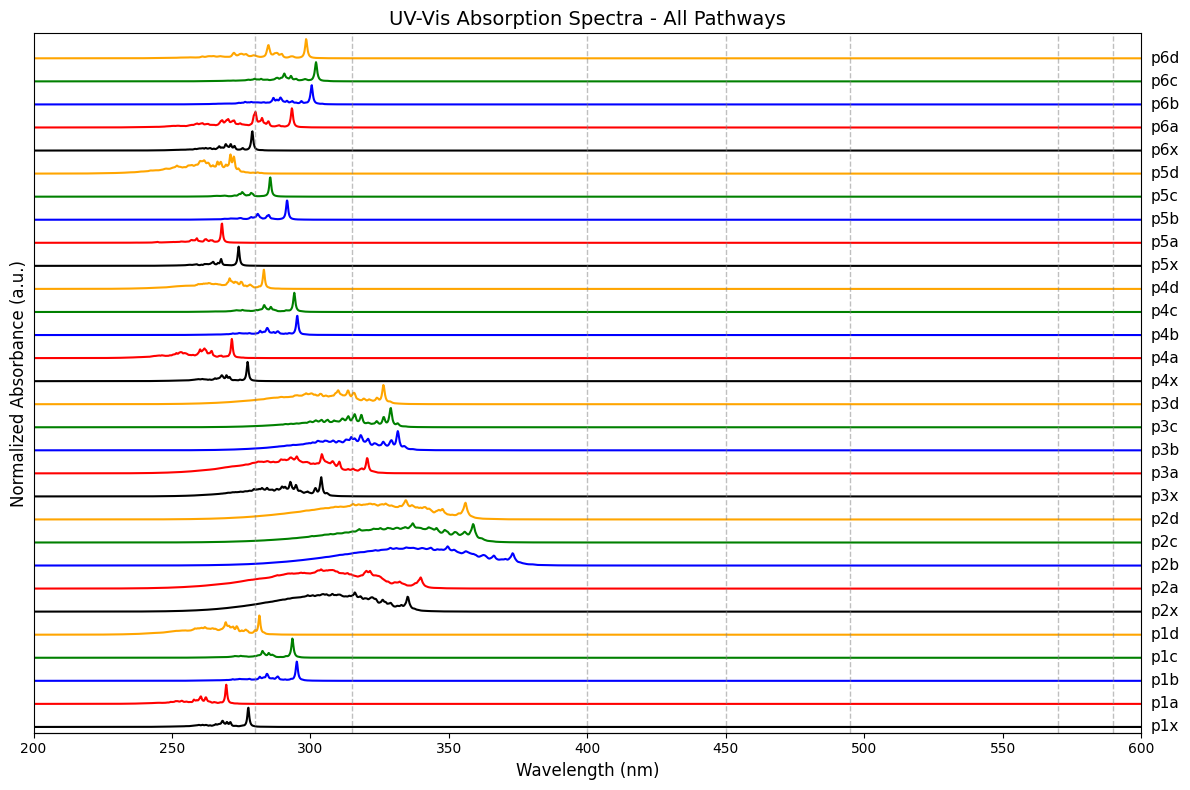

In [44]:
# With all parameters customized
molecule_list = [
    "p1x", "p1a", "p1b", "p1c", "p1d",
    "p2x", "p2a", "p2b", "p2c", "p2d",
    "p3x", "p3a", "p3b", "p3c", "p3d",
    "p4x", "p4a", "p4b", "p4c", "p4d",
    "p5x", "p5a", "p5b", "p5c", "p5d",
    "p6x", "p6a", "p6b", "p6c", "p6d"
]

fig, ax = plot_stacked_uvvis_spectra(
    df,
    molecule_list,
    wavelength_min=200,
    wavelength_max=600,
    n_points=5000,
    y_spacing=0.2,
    colors=['black', 'red', 'blue', 'green', 'orange'],
    region_boundaries=[280, 315, 400, 450, 495, 570, 590, 620],
    order='ascending',
    figsize=(12, 8),
    title="UV-Vis Absorption Spectra - All Pathways",
    invert_x=False,
    bottom_margin=0.3
)
plt.show()

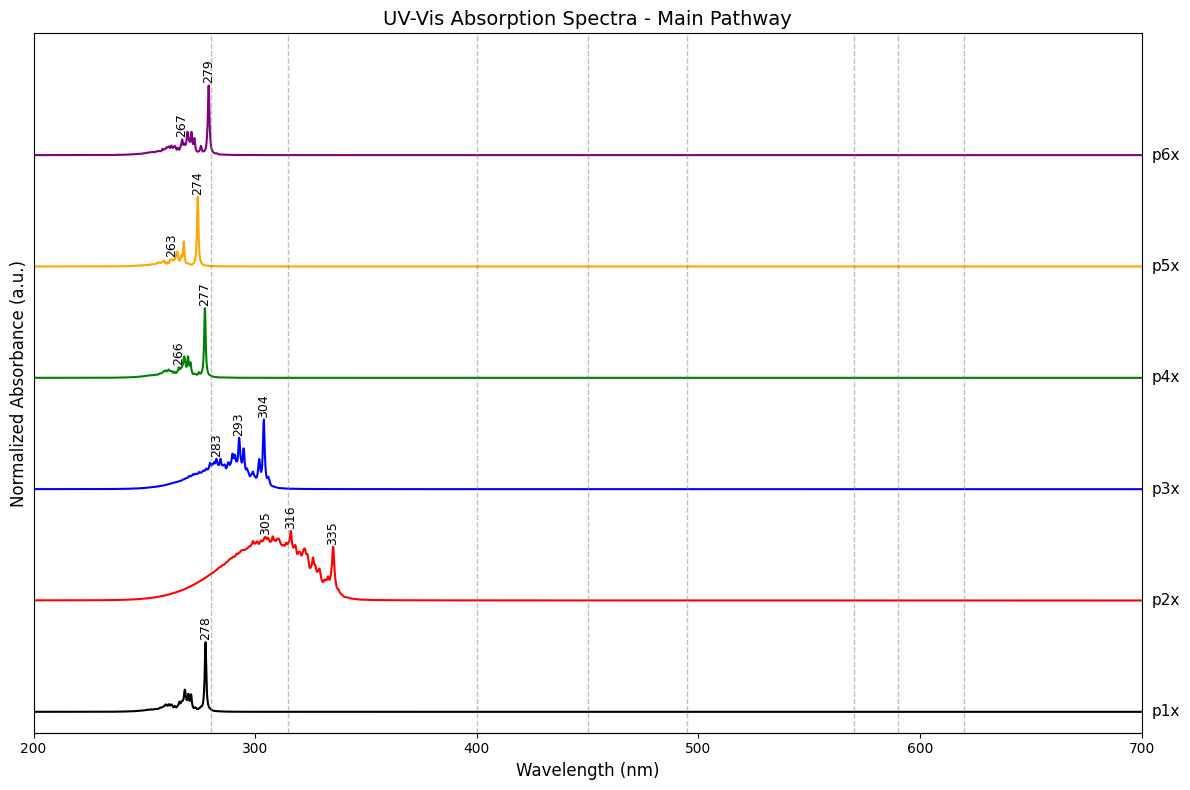

In [45]:
molecule_list = ["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"]

fig, ax = plot_stacked_uvvis_spectra(
    df, 
    molecule_list,
    # use_tddft=True,
    # fwhm=1.0,  # 5 nm broadening
    wavelength_min=200,
    wavelength_max=700,
    y_spacing=0.6,
    colors=['black', 'red', 'blue', 'green', 'orange', 'purple'],
    title="UV-Vis Absorption Spectra - Main Pathway",
    
    label_peaks=True,
    peak_label_mode="threshold",
    peak_threshold=0.01,
    peak_min_distance=10,
    peak_label_format="{wavelength:.0f}",
    peak_label_offset=0.03
)
plt.show()

### 6. Raman + IR

In [46]:
from scipy.signal import find_peaks
from typing import List, Optional, Dict, Tuple, Union

def plot_ir_raman_correlation(
    df: pd.DataFrame,
    molecule_id: str,
    # Spectral range
    wavenumber_min: float = 400,
    wavenumber_max: float = 4000,
    n_points: int = 5000,
    # Gaussian broadening
    fwhm_ir: float = 10.0,
    fwhm_raman: float = 10.0,
    # Peak detection
    peak_height: float = 0.0,
    peak_prominence: float = 0.0,
    min_distance_cm: float = 0.0,
    cluster_tolerance_cm: float = 8.0,
    max_pair_delta: float = 40.0,
    # Layout
    gap: float = 0.3,
    padding: float = 0.1,
    vertical_snap_frac: float = 0.02,
    diagonal_height: float = 0.20,
    # Connector styling
    connector_style: str = "--",
    connector_color: str = "gray",
    # Label offsets
    peak_label_offset: float = 0.05,
    line_label_y_offset: float = 0.02,
    # Manual annotations
    manual_labels: Optional[List] = None,
    # Plot styling
    figsize: tuple = (12, 6),
    title: Optional[str] = None,
    ir_color: str = "red",
    raman_color: str = "blue",
    invert_x: bool = True
):
    """
    Plot IR and Raman spectra with automatic peak pairing and correlation lines.
    
    INDEXING: Peaks are indexed from LEFT TO RIGHT (high to low wavenumber) starting at 1.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing molecule data with 'ir_spectrum' and 'raman_spectrum'
    molecule_id : str
        Molecule ID to plot
    wavenumber_min : float
        Minimum wavenumber in cm⁻¹ (default: 400)
    wavenumber_max : float
        Maximum wavenumber in cm⁻¹ (default: 4000)
    n_points : int
        Number of points in wavenumber grid (default: 5000)
    fwhm_ir : float
        FWHM for IR Gaussian broadening in cm⁻¹ (default: 10.0)
    fwhm_raman : float
        FWHM for Raman Gaussian broadening in cm⁻¹ (default: 10.0)
    peak_height : float
        Minimum peak height for detection (default: 0.0)
    peak_prominence : float
        Minimum peak prominence for detection (default: 0.0)
    min_distance_cm : float
        Minimum distance between peaks in cm⁻¹ (default: 0.0)
    cluster_tolerance_cm : float
        Tolerance for clustering nearby peaks in cm⁻¹ (default: 8.0)
    max_pair_delta : float
        Maximum frequency difference for pairing IR-Raman peaks in cm⁻¹ (default: 40.0)
    gap : float
        Vertical gap between IR and Raman plots (default: 0.3)
    padding : float
        Padding above/below spectra (default: 0.1)
    vertical_snap_frac : float
        Fraction of plot height for vertical snap distance (default: 0.02)
    diagonal_height : float
        Height of diagonal connector section (default: 0.20)
    connector_style : str
        Line style for connectors (default: "--")
    connector_color : str
        Color for connectors (default: "gray")
    peak_label_offset : float
        Distance from peak to label (default: 0.05)
    line_label_y_offset : float
        Distance from line end to label (default: 0.02)
    manual_labels : Optional[List]
        Manual label specifications (see examples)
    figsize : tuple
        Figure size (default: (12, 6))
    title : Optional[str]
        Plot title. If None, uses molecule_id
    ir_color : str
        Color for IR spectrum (default: "red")
    raman_color : str
        Color for Raman spectrum (default: "blue")
    invert_x : bool
        Invert x-axis (default: True)
    
    Returns
    -------
    fig, ax, ax2 : matplotlib figure and axes
    peak_pairs : list
        List of detected peak pairs
    
    Manual Labels Format
    --------------------
    manual_labels = [
        # Override pair label (indices now start at 1)
        [1, "CH_3", "blue"],  # pair_idx, label, color
        [2, "C=O"],
        
        # Force specific IR-Raman pairing (indices now start at 1)
        [[3, 6], "CH_2", "red"],  # [ir_idx, ra_idx], label, color
        
        # Additional parameters
        [4, "Label", "dx:50", "rot:45", "center"],  # dx offset, rotation, alignment
        
        # Individual peak labels (indices now start at 1)
        ["ir", [1, "Peak1", 0.1], [2, "Peak2", 0.15, "rot:30"]],
        ["raman", [1, "Peak1"], [2, "Peak2", 0.2]],
        
        # Hide unlabeled peaks
        ["else", 0]
    ]
    
    Examples
    --------
    # Simple usage
    >>> fig, ax, ax2, pairs = plot_ir_raman_correlation(df, "p1x")
    
    # With custom parameters
    >>> fig, ax, ax2, pairs = plot_ir_raman_correlation(
    ...     df, "p1x",
    ...     wavenumber_min=400,
    ...     wavenumber_max=4000,
    ...     fwhm_ir=10,
    ...     fwhm_raman=10,
    ...     cluster_tolerance_cm=8,
    ...     max_pair_delta=40
    ... )
    
    # With manual labels (note: indices start at 1)
    >>> manual = [
    ...     [1, "CH_3", "blue"],
    ...     [2, "C=O"],
    ...     [[3, 6], "CH_2", "red"],
    ...     ["ir", [1, "\\nu(OH)", 0.15]],
    ...     ["else", 0]
    ... ]
    >>> fig, ax, ax2, pairs = plot_ir_raman_correlation(
    ...     df, "p1x", manual_labels=manual
    ... )
    """
    
    # Find molecule in dataframe
    mask = df["molecule_id"].str.contains(molecule_id, case=False, na=False, regex=False)
    if not mask.any():
        raise ValueError(f"Molecule '{molecule_id}' not found in DataFrame")
    
    dataset_index = df[mask].index[0]
    
    # Build wavenumber grid
    x = np.linspace(wavenumber_min, wavenumber_max, n_points)
    
    # Gaussian parameters
    sigma_ir = fwhm_ir / (2 * np.sqrt(2 * np.log(2)))
    sigma_raman = fwhm_raman / (2 * np.sqrt(2 * np.log(2)))
    
    # =====================================================
    # BUILD IR SPECTRUM
    # =====================================================
    df_ir = pd.DataFrame(df["ir_spectrum"].iloc[dataset_index])
    df_ir["Absorbance"] = df_ir["eps"] * 0.01
    
    absorbance_curve = np.zeros_like(x)
    for _, row in df_ir.iterrows():
        absorbance_curve += row["Absorbance"] * np.exp(-0.5 * ((x - row["freq_cm-1"])/sigma_ir)**2)
    
    if absorbance_curve.max() > 0:
        absorbance_curve /= absorbance_curve.max()
    
    transmittance_curve = 10**(-absorbance_curve)
    transmittance_curve = (transmittance_curve - transmittance_curve.min()) / \
                          (transmittance_curve.max() - transmittance_curve.min())
    
    # =====================================================
    # BUILD RAMAN SPECTRUM
    # =====================================================
    df_ra = pd.DataFrame(df["raman_spectrum"].iloc[dataset_index])
    raman_spectrum = np.zeros_like(x)
    for _, row in df_ra.iterrows():
        raman_spectrum += row["activity"] * np.exp(-0.5 * ((x - row["freq_cm-1"])/sigma_raman)**2)
    
    if raman_spectrum.max() > 0:
        raman_spectrum /= raman_spectrum.max()
    
    # =====================================================
    # PEAK DETECTION
    # =====================================================
    dx = x[1] - x[0]
    min_dist_samples = max(1, int(min_distance_cm/dx))
    
    ir_heights = 1 - transmittance_curve
    pIR_raw, _ = find_peaks(ir_heights, height=peak_height, prominence=peak_prominence, 
                            distance=min_dist_samples)
    pRA_raw, _ = find_peaks(raman_spectrum, height=peak_height, prominence=peak_prominence,
                            distance=min_dist_samples)
    
    # Cluster nearby peaks
    def cluster_peaks(peaks, y_values, tol):
        if len(peaks) == 0:
            return []
        peaks_sorted = sorted(peaks, key=lambda p: x[p])
        clusters = []
        curr = [peaks_sorted[0]]
        for p in peaks_sorted[1:]:
            if abs(x[p] - x[curr[-1]]) < tol:
                curr.append(p)
            else:
                clusters.append(curr)
                curr = [p]
        clusters.append(curr)
        
        merged = []
        for c in clusters:
            freqs = np.array([x[p] for p in c])
            ints = np.array([y_values[p] for p in c])
            centroid = (freqs * ints).sum()/ints.sum() if ints.sum()>0 else freqs.mean()
            chosen = c[np.argmin(abs(freqs - centroid))]
            merged.append(chosen)
        return merged
    
    pIR = cluster_peaks(pIR_raw, ir_heights, cluster_tolerance_cm)
    pRA = cluster_peaks(pRA_raw, raman_spectrum, cluster_tolerance_cm)
    
    # CHANGED: Sort peaks from high to low wavenumber (left to right) and index from 1
    pIR_sorted = sorted(pIR, key=lambda p: x[p], reverse=True)
    pRA_sorted = sorted(pRA, key=lambda p: x[p], reverse=True)
    
    ir_info = [(i+1, p, x[p], transmittance_curve[p], 1-transmittance_curve[p]) 
               for i, p in enumerate(pIR_sorted)]
    ra_info = [(i+1, p, x[p], raman_spectrum[p], raman_spectrum[p]) 
               for i, p in enumerate(pRA_sorted)]
    
    ir_map = {row[0]: row for row in ir_info}
    ra_map = {row[0]: row for row in ra_info}
    
    # =====================================================
    # PARSE MANUAL LABELS
    # =====================================================
    if manual_labels is None:
        manual_labels = []
    
    def parse_label_params(item):
        if isinstance(item[0], list):
            ir_idx, ra_idx = item[0]
            label = item[1] if len(item) >= 2 else None
            start_idx = 2
        else:
            pair_idx = item[0]
            label = item[1]
            start_idx = 2
            ir_idx, ra_idx = None, None
        
        color = connector_color
        dx_offset = 0.0
        rotation = 0
        alignment = "center"
        
        for i in range(start_idx, len(item)):
            param = item[i]
            if isinstance(param, str):
                if param.startswith("dx:"):
                    dx_offset = float(param[3:])
                elif param.startswith("rot:"):
                    rotation = float(param[4:])
                elif param in ["center", "left", "right"]:
                    alignment = param
                elif param.startswith("#") or param in ["red", "blue", "green", "purple", 
                                                        "orange", "cyan", "magenta", "yellow", 
                                                        "black", "gray", "grey"]:
                    color = param
                elif i == start_idx:
                    color = param
        
        if ir_idx is not None:
            return ("forced", ir_idx, ra_idx, label, color, dx_offset, rotation, alignment)
        else:
            return ("override", pair_idx, label, color, dx_offset, rotation, alignment)
    
    pair_label_overrides = {}
    forced_pairs = []
    ir_peak_labels = {}
    raman_peak_labels = {}
    hide_unlisted = False
    
    for item in manual_labels:
        if item == ["else", 0]:
            hide_unlisted = True
            continue
        
        if isinstance(item, list) and len(item) >= 2:
            if item[0] == "ir":
                for peak_item in item[1:]:
                    if isinstance(peak_item, list) and len(peak_item) >= 2:
                        peak_idx = peak_item[0]
                        label = peak_item[1]
                        offset = peak_item[2] if len(peak_item) >= 3 and \
                                isinstance(peak_item[2], (int, float)) else 0
                        rotation = 0
                        for p in peak_item[3:]:
                            if isinstance(p, str) and p.startswith("rot:"):
                                rotation = float(p[4:])
                        ir_peak_labels[peak_idx] = (label, offset, rotation)
                continue
            elif item[0] == "raman":
                for peak_item in item[1:]:
                    if isinstance(peak_item, list) and len(peak_item) >= 2:
                        peak_idx = peak_item[0]
                        label = peak_item[1]
                        offset = peak_item[2] if len(peak_item) >= 3 and \
                                isinstance(peak_item[2], (int, float)) else 0
                        rotation = 0
                        for p in peak_item[3:]:
                            if isinstance(p, str) and p.startswith("rot:"):
                                rotation = float(p[4:])
                        raman_peak_labels[peak_idx] = (label, offset, rotation)
                continue
            
            result = parse_label_params(item)
            
            if result[0] == "forced":
                _, ir_idx, ra_idx, label, color, dx_offset, rotation, alignment = result
                forced_pairs.append([ir_idx, ra_idx, label, color, dx_offset, rotation, alignment])
            elif result[0] == "override":
                _, pair_idx, label, color, dx_offset, rotation, alignment = result
                pair_label_overrides[pair_idx] = (label, color, dx_offset, rotation, alignment)
    
    # =====================================================
    # PAIRING
    # =====================================================
    assigned_ir = set()
    assigned_ra = set()
    
    for ir_idx, ra_idx, label, color, dx_offset, rotation, alignment in forced_pairs:
        if ir_idx in ir_map and ra_idx in ra_map:
            assigned_ir.add(ir_idx)
            assigned_ra.add(ra_idx)
    
    candidates = []
    for ir in ir_info:
        for ra in ra_info:
            ir_idx, ir_p, ir_f, _, ir_int = ir
            ra_idx, ra_p, ra_f, _, ra_int = ra
            if ir_idx in assigned_ir or ra_idx in assigned_ra:
                continue
            delta = abs(ir_f - ra_f)
            score = (delta, -ir_int*ra_int)
            candidates.append((delta, score, ir_idx, ra_idx, ir_p, ra_p, ir_f, ra_f))
    
    candidates.sort(key=lambda t:(t[0],t[1]))
    
    pairs = []
    for delta,_,ir_idx,ra_idx,ir_pidx,ra_pidx,ir_f,ra_f in candidates:
        if delta > max_pair_delta: 
            continue
        if ir_idx in assigned_ir or ra_idx in assigned_ra: 
            continue
        assigned_ir.add(ir_idx)
        assigned_ra.add(ra_idx)
        pairs.append([ir_idx,ra_idx,ir_pidx,ra_pidx,ir_f,ra_f,delta])
    
    # CHANGED: Sort pairs from high to low wavenumber (left to right) and index from 1
    pairs.sort(key=lambda p: p[4], reverse=True)
    for i, p in enumerate(pairs): 
        p.append(i+1)
    
    # =====================================================
    # GEOMETRY
    # =====================================================
    ir_baseline = 1.0
    raman_baseline = -gap - 1.0
    
    y_top = ir_baseline + padding
    y_bottom = raman_baseline - padding
    
    raman_shifted = raman_spectrum + raman_baseline
    
    vert_height = (gap - diagonal_height) / 2.0
    diag_top_y = -vert_height
    diag_bottom_y = -(vert_height + diagonal_height)
    
    snap = vertical_snap_frac * (y_top - y_bottom)
    
    # =====================================================
    # PLOT
    # =====================================================
    fig, ax = plt.subplots(figsize=figsize)
    ax2 = ax.twinx()
    
    ax.set_ylim(y_bottom, y_top)
    ax2.set_ylim(y_bottom, y_top)
    
    # Set up axes
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0.0", "0.5", "1.0"])
    
    ax2.set_yticks([raman_baseline, raman_baseline+0.5, raman_baseline+1.0])
    ax2.set_yticklabels(["0.0", "0.5", "1.0"])
    
    ax.set_ylabel("IR Transmittance (a.u.)", color=ir_color)
    ax2.set_ylabel("Raman Intensity (a.u.)", color=raman_color)
    ax.tick_params(axis='y', colors=ir_color)
    ax2.tick_params(axis='y', colors=raman_color)
    
    ax.grid(False)
    ax2.grid(False)
    
    # =====================================================
    # DRAW CONNECTORS
    # =====================================================
    hide_ir = set()
    hide_ra = set()
    
    for ir_idx, ra_idx, ir_pidx, ra_pidx, ir_f, ra_f, delta, pidx in pairs:
        should_hide = False
        if pidx in pair_label_overrides:
            label_val = pair_label_overrides[pidx][0]
            if label_val == 0:
                should_hide = True
        elif hide_unlisted:
            should_hide = True
        
        if should_hide:
            continue
        
        hide_ir.add(ir_idx)
        hide_ra.add(ra_idx)
        
        ir_px = x[ir_pidx]
        ir_py = transmittance_curve[ir_pidx]
        r_px = x[ra_pidx]
        r_py = raman_shifted[ra_pidx]
        
        if pidx in pair_label_overrides:
            label_text, line_color, dx_offset, rotation, alignment = pair_label_overrides[pidx]
        else:
            label_text = str(pidx)
            line_color = connector_color
            dx_offset = 0.0
            rotation = 0
            alignment = "center"
        
        mid_x = (ir_px + r_px)/2 + dx_offset
        mid_y = (diag_top_y + diag_bottom_y)/2
        
        ir_start_y = ir_py + np.sign(diag_top_y - ir_py) * snap
        r_start_y = r_py + np.sign(diag_bottom_y - r_py) * snap
        
        ax.plot([ir_px, ir_px, mid_x, r_px, r_px], 
                [ir_start_y, diag_top_y, mid_y, diag_bottom_y, r_start_y], 
                ls=connector_style, color=line_color, lw=1.0, zorder=3)
    
    # Draw forced pairs
    for ir_idx, ra_idx, label, line_color, dx_offset, rotation, alignment in forced_pairs:
        if ir_idx not in ir_map or ra_idx not in ra_map:
            continue
        
        hide_ir.add(ir_idx)
        hide_ra.add(ra_idx)
        
        ir_pidx = ir_map[ir_idx][1]
        ra_pidx = ra_map[ra_idx][1]
        
        ir_px = x[ir_pidx]
        ir_py = transmittance_curve[ir_pidx]
        r_px = x[ra_pidx]
        r_py = raman_shifted[ra_pidx]
        
        mid_x = (ir_px + r_px)/2 + dx_offset
        mid_y = (diag_top_y + diag_bottom_y)/2
        
        ir_start_y = ir_py + np.sign(diag_top_y - ir_py) * snap
        r_start_y = r_py + np.sign(diag_bottom_y - r_py) * snap
        
        ax.plot([ir_px, ir_px, mid_x, r_px, r_px], 
                [ir_start_y, diag_top_y, mid_y, diag_bottom_y, r_start_y], 
                ls=connector_style, color=line_color, lw=1.0, zorder=4)
    
    # =====================================================
    # PAIR LABELS
    # =====================================================
    for ir_idx, ra_idx, ir_pidx, ra_pidx, ir_f, ra_f, delta, pidx in pairs:
        should_hide = False
        if pidx in pair_label_overrides:
            label_val = pair_label_overrides[pidx][0]
            if label_val == 0:
                should_hide = True
        elif hide_unlisted:
            should_hide = True
        
        if should_hide:
            continue
        
        ir_px = x[ir_pidx]
        r_px = x[ra_pidx]
        
        if pidx in pair_label_overrides:
            label_text, line_color, dx_offset, rotation, alignment = pair_label_overrides[pidx]
        else:
            label_text = str(pidx)
            dx_offset = 0.0
            rotation = 0
        
        mid_x = (ir_px + r_px)/2 + dx_offset
        mid_y = (diag_top_y + diag_bottom_y)/2
        
        display_text = label_text if '\n' in label_text else f"${label_text}$"
        
        ax.text(mid_x, mid_y, display_text,
                ha='center', va='center', fontsize=9, color='black',
                rotation=rotation, rotation_mode='anchor',
                bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                zorder=5)
    
    for ir_idx, ra_idx, label, line_color, dx_offset, rotation, alignment in forced_pairs:
        if ir_idx not in ir_map or ra_idx not in ra_map or label is None:
            continue
        
        ir_pidx = ir_map[ir_idx][1]
        ra_pidx = ra_map[ra_idx][1]
        
        ir_px = x[ir_pidx]
        r_px = x[ra_pidx]
        
        mid_x = (ir_px + r_px)/2 + dx_offset
        mid_y = (diag_top_y + diag_bottom_y)/2
        
        display_text = label if '\n' in label else f"${label}$"
        
        ax.text(mid_x, mid_y, display_text,
                ha='center', va='center', fontsize=9, color='black',
                rotation=rotation, rotation_mode='anchor',
                bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                zorder=5)
    
    # =====================================================
    # PEAK GRID LINES
    # =====================================================
    for i, p, fx, py, inten in ir_info:
        if i in ir_peak_labels:
            label, offset, rotation = ir_peak_labels[i]
            
            if offset > 0:
                line_end_y = py - offset
                ax.plot([fx, fx], [py - snap, line_end_y], 
                       ls=connector_style, color=connector_color, lw=1.0, zorder=6)
    
    for i, p, fx, py, inten in ra_info:
        if i in raman_peak_labels:
            label, offset, rotation = raman_peak_labels[i]
            shifted_py = raman_shifted[p]
            
            if offset > 0:
                line_start_y = shifted_py + snap
                line_end_y = shifted_py + offset
                ax.plot([fx, fx], [line_start_y, line_end_y], 
                       ls=connector_style, color=connector_color, lw=1.0, zorder=6)
    
    # =====================================================
    # PEAK LABELS
    # =====================================================
    for i, p, fx, py, inten in ir_info:
        if i in ir_peak_labels:
            label, offset, rotation = ir_peak_labels[i]
            
            if offset > 0:
                line_end_y = py - offset
                ax.text(fx, line_end_y - line_label_y_offset, f"${label}$",
                       ha='center', va='center', fontsize=9, color='black',
                       rotation=rotation, rotation_mode='anchor',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                       zorder=12)
            else:
                ax.text(fx, py - peak_label_offset, f"${label}$",
                       ha='center', va='center', color='black', fontsize=9,
                       rotation=rotation, rotation_mode='anchor',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                       zorder=12)
        elif i not in hide_ir and not hide_unlisted:
            ax.text(fx, py - peak_label_offset, f"${str(i)}$",
                   ha='center', va='center', color='black', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                   zorder=12)
    
    for i, p, fx, py, inten in ra_info:
        if i in raman_peak_labels:
            label, offset, rotation = raman_peak_labels[i]
            shifted_py = raman_shifted[p]
            
            if offset > 0:
                line_end_y = shifted_py + offset
                ax.text(fx, line_end_y + line_label_y_offset, f"${label}$",
                       ha='center', va='center', fontsize=9, color='black',
                       rotation=rotation, rotation_mode='anchor',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                       zorder=12)
            else:
                ax.text(fx, shifted_py + peak_label_offset, f"${label}$",
                       ha='center', va='center', color='black', fontsize=9,
                       rotation=rotation, rotation_mode='anchor',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                       zorder=12)
        elif i not in hide_ra and not hide_unlisted:
            shifted_py = raman_shifted[p]
            ax.text(fx, shifted_py + peak_label_offset, f"${str(i)}$",
                   ha='center', va='center', color='black', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor="white", edgecolor="none"),
                   zorder=12)
    
    # =====================================================
    # PLOT SPECTRA ON TOP
    # =====================================================
    ax.plot(x, transmittance_curve, color=ir_color, lw=1.5, zorder=100)
    ax2.plot(x, raman_shifted, color=raman_color, lw=1.5, zorder=101)
    
    # Formatting
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlim(wavenumber_max, wavenumber_min) if invert_x else ax.set_xlim(wavenumber_min, wavenumber_max)
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    
    plot_title = title if title is not None else f"IR & Raman — {molecule_id}"
    ax.set_title(plot_title)
    
    plt.tight_layout()
    
    return fig, ax, ax2, pairs

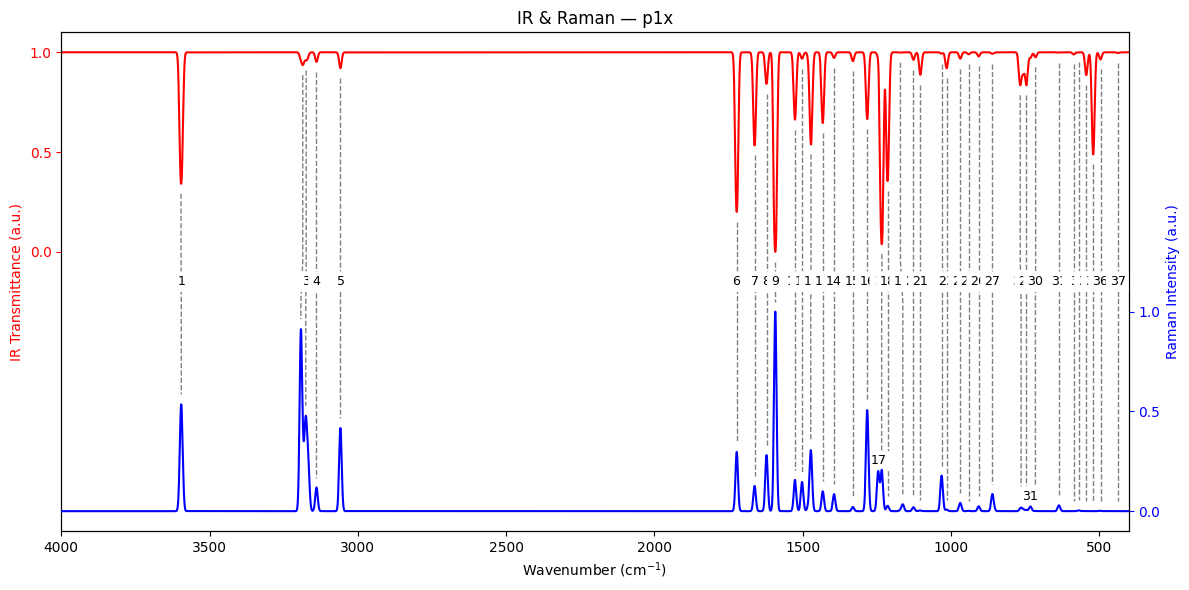

In [47]:
# Simple usage
fig, ax, ax2, pairs = plot_ir_raman_correlation(df, "p1x")
plt.show()

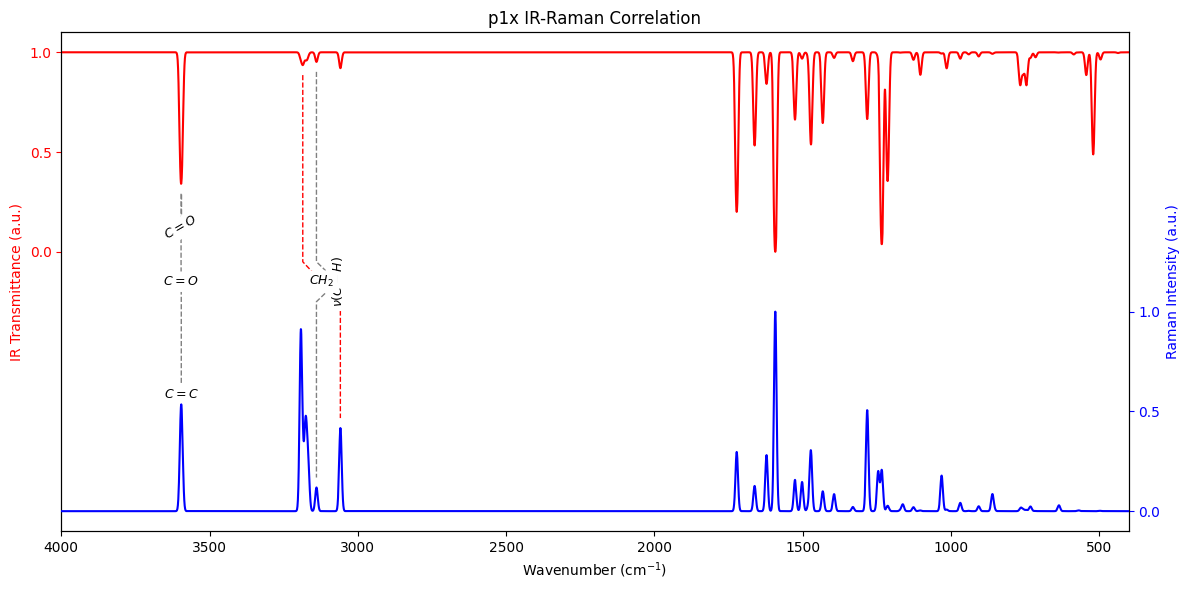

In [48]:
# With manual labels
manual_labels = [
    [0, "CH_3", "blue"],
    [1, "C=O"],
    [[2, 5], "CH_2", "red"],
    [3, "\\nu(C-H)", "dx:-70", "rot:90"],
    ["ir", [0, "OH", 0.15], [1, "C=O", 0.2, "rot:30"]],
    ["raman", [0, "C-C"], [1, "C=C"]],
    ["else", 0]  # Hide unlabeled peaks
]

fig, ax, ax2, pairs = plot_ir_raman_correlation(
    df, "p1x",
    manual_labels=manual_labels,
    title="p1x IR-Raman Correlation"
)
plt.show()

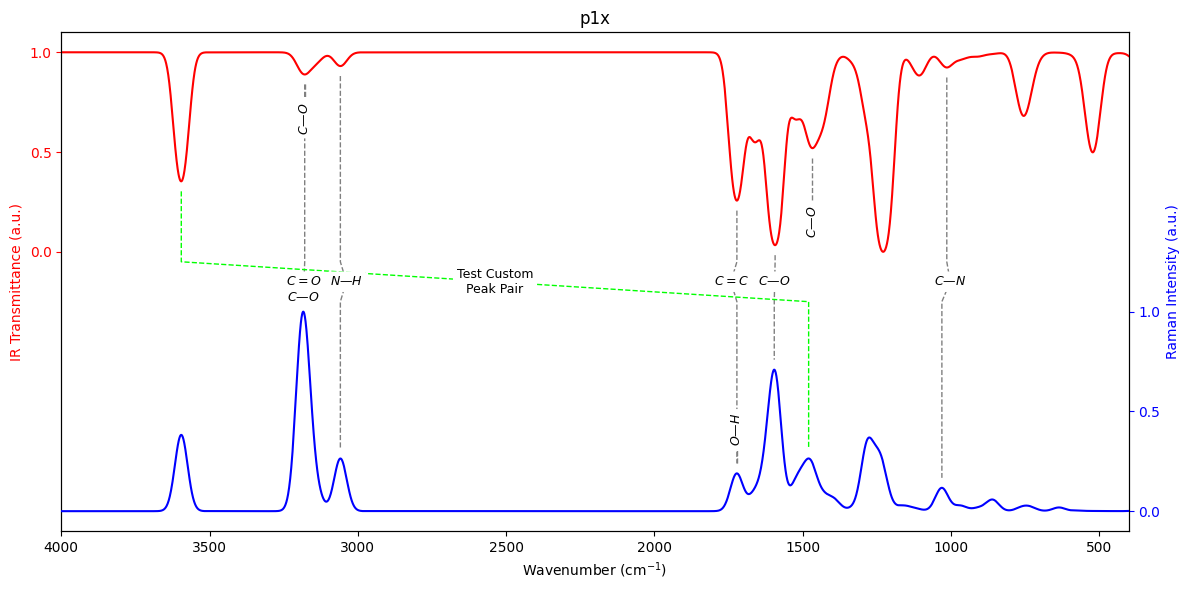


Detected 7 peak pairs:
  Pair 1: IR peak 2 (3179.0 cm⁻¹) ↔ Raman peak 2 (3184.1 cm⁻¹), Δ = 5.0 cm⁻¹
  Pair 2: IR peak 3 (3058.8 cm⁻¹) ↔ Raman peak 3 (3058.8 cm⁻¹), Δ = 0.0 cm⁻¹
  Pair 3: IR peak 4 (1721.5 cm⁻¹) ↔ Raman peak 4 (1721.5 cm⁻¹), Δ = 0.0 cm⁻¹
  Pair 4: IR peak 6 (1592.6 cm⁻¹) ↔ Raman peak 5 (1595.4 cm⁻¹), Δ = 2.9 cm⁻¹
  Pair 5: IR peak 11 (1013.6 cm⁻¹) ↔ Raman peak 9 (1030.1 cm⁻¹), Δ = 16.6 cm⁻¹
  Pair 6: IR peak 12 (754.3 cm⁻¹) ↔ Raman peak 11 (745.7 cm⁻¹), Δ = 8.6 cm⁻¹
  Pair 7: IR peak 13 (521.7 cm⁻¹) ↔ Raman peak 13 (497.9 cm⁻¹), Δ = 23.8 cm⁻¹


In [49]:
# Your exact manual labels format from the original code
manual_labels = [
    [0, "C—H"],
    [1, "C=O"],
    [2, "N—H", "dx:-20"],
    [3, "C=C", "dx:20"],
    [4, "C—O"],
    [5, "C—N", "dx:-20"],
    [[1, 6], "Test Custom\nPeak Pair", "#00ff00"],
    [6, 0],
    [7, 0],
    [8, "What Is\nThis?"],
    ["ir", 
        [0, "C=C", 0.05],
        [2, "C—O", 0.2, "rot:90"],
        [8, "C—O", 0.35, "rot:90"],
    ],
    ["raman",
        [4, "O—H", 0.2, "rot:90"],
        [2, "C—O", 0.05],
    ],
    ["else", 0]
]

# Use it with the function - exactly like your original code!
fig, ax, ax2, pairs = plot_ir_raman_correlation(
    df, 
    "p1x",
    wavenumber_min=400,
    wavenumber_max=4000,
    fwhm_ir=50,
    fwhm_raman=50,
    cluster_tolerance_cm=8.0,
    max_pair_delta=40.0,
    manual_labels=manual_labels,
    title="p1x",
    figsize=(12, 6)
)
plt.show()

# Check the detected pairs
print(f"\nDetected {len(pairs)} peak pairs:")
for pair in pairs:
    ir_idx, ra_idx, ir_pidx, ra_pidx, ir_f, ra_f, delta, pidx = pair
    print(f"  Pair {pidx}: IR peak {ir_idx} ({ir_f:.1f} cm⁻¹) ↔ Raman peak {ra_idx} ({ra_f:.1f} cm⁻¹), Δ = {delta:.1f} cm⁻¹")

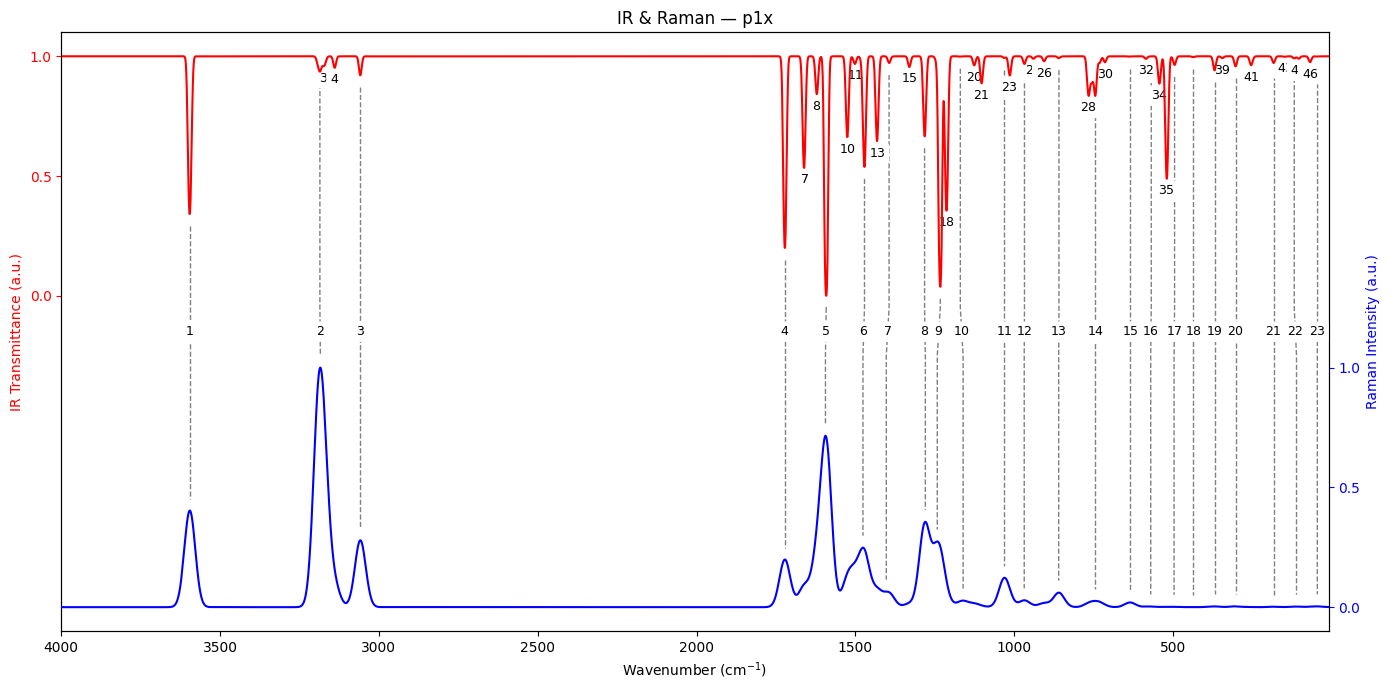

In [50]:
# With custom parameters
fig, ax, ax2, pairs = plot_ir_raman_correlation(
    df, "p1x",
    wavenumber_min=10,
    wavenumber_max=4000,
    fwhm_ir=10,
    fwhm_raman=40,
    cluster_tolerance_cm=8,
    max_pair_delta=40,
    figsize=(14, 7)
)
plt.show()

In [51]:
def extract_peak_table(
    df: pd.DataFrame,
    molecule_ids,
    # Spectral range
    wavenumber_min: float = 400,
    wavenumber_max: float = 4000,
    n_points: int = 5000,
    # Gaussian broadening
    fwhm_ir: float = 10.0,
    fwhm_raman: float = 10.0,
    # Peak detection
    peak_height: float = 0.01,
    peak_prominence: float = 0.01,
    min_distance_cm: float = 5.0,
    # Matching tolerance
    matching_tolerance_cm: float = 20.0,
    # Intensity thresholds
    discrete_ir_threshold: float = 0.0,
    discrete_raman_threshold: float = 0.0,
    fill_empty: str = "–",
) -> pd.DataFrame:
    """
    Core vibrational peak extraction and assignment engine.

    DESIGN PHILOSOPHY
    -----------------
    This function implements a forward vibrational spectroscopy model:

        discrete DFT vibrational modes (νᵢ)
            → Gaussian broadening (FWHM)
            → simulated IR / Raman spectra
            → peak detection
            → mode-to-band association

    IMPORTANT:
    - Frequency scaling is NOT applied here.
    - FWHM optimization is NOT performed here.
    - Experimental spectra are NOT directly compared here.

    This function is intended to be a STABLE CORE.
    Scaling-factor fitting, FWHM optimization, and experimental matching
    must be implemented as external layers that call this function.

    MATCHING POLICY
    ---------------
    - Many-to-one matching is ALLOWED:
      multiple discrete modes may map to the same IR/Raman band.
    - No-match is ALLOWED:
      if no band lies within tolerance, the mode is skipped (–).
    - No forced one-to-one assignment is performed.

    This behavior reflects real vibrational spectroscopy
    (band congestion, limited resolution, intensity thresholds).
    """

    # -----------------------------------------------------
    # Normalize input
    # -----------------------------------------------------
    if isinstance(molecule_ids, str):
        molecule_ids = [molecule_ids]

    mol_tables = {}
    max_modes = 0

    # =====================================================
    # PROCESS EACH MOLECULE (CORE LOGIC — DO NOT MODIFY)
    # =====================================================
    for molecule_id in molecule_ids:

        mask = df["molecule_id"].str.contains(
            molecule_id, case=False, na=False, regex=False
        )
        if not mask.any():
            raise ValueError(f"Molecule '{molecule_id}' not found")

        dataset_index = df[mask].index[0]

        # -----------------------------------------------------
        # NOTE ON FREQUENCY SCALING (INTENTIONALLY NOT APPLIED)
        # -----------------------------------------------------
        # Discrete vibrational modes (νᵢ) are kept UNTOUCHED here.
        #
        # Linear scaling:     ν_s = s · ν
        # Relative scaling:   ν_s = ν_min + s(ν − ν_min)
        #
        # Scaling must be applied OUTSIDE this function,
        # before spectrum simulation, when fitting against experiment.
        # -----------------------------------------------------

        x = np.linspace(wavenumber_min, wavenumber_max, n_points)

        # -----------------------------------------------------
        # GAUSSIAN BROADENING PARAMETERS
        # -----------------------------------------------------
        # FWHM represents experimental resolution.
        # Future work:
        # - optimize FWHM by minimizing mismatch to experiment
        # -----------------------------------------------------
        sigma_ir = fwhm_ir / (2 * np.sqrt(2 * np.log(2)))
        sigma_raman = fwhm_raman / (2 * np.sqrt(2 * np.log(2)))

        # -----------------------------------------------------
        # DISCRETE VIBRATIONAL MODES (νᵢ — REFERENCE)
        # -----------------------------------------------------
        df_ir = pd.DataFrame(df["ir_spectrum"].iloc[dataset_index])
        df_ir = df_ir[df_ir["eps"] >= discrete_ir_threshold]

        df_ra = pd.DataFrame(df["raman_spectrum"].iloc[dataset_index])
        df_ra = df_ra[df_ra["activity"] >= discrete_raman_threshold]

        discrete_ir = df_ir["freq_cm-1"].values
        discrete_ra = df_ra["freq_cm-1"].values

        # Union of IR + Raman discrete modes
        vib_modes = list(discrete_ir)
        for f in discrete_ra:
            if not any(abs(f - g) < 1.0 for g in vib_modes):
                vib_modes.append(f)

        vib_modes = sorted(vib_modes, reverse=True)
        max_modes = max(max_modes, len(vib_modes))

        # -----------------------------------------------------
        # CONTINUOUS IR SPECTRUM (FORWARD MODEL)
        # -----------------------------------------------------
        absorbance = np.zeros_like(x)
        for _, r in df_ir.iterrows():
            absorbance += r["eps"] * 0.01 * np.exp(
                -0.5 * ((x - r["freq_cm-1"]) / sigma_ir) ** 2
            )

        if absorbance.max() > 0:
            absorbance /= absorbance.max()

        trans = 10 ** (-absorbance)
        trans = (trans - trans.min()) / (trans.max() - trans.min())

        # -----------------------------------------------------
        # CONTINUOUS RAMAN SPECTRUM (FORWARD MODEL)
        # -----------------------------------------------------
        raman_curve = np.zeros_like(x)
        for _, r in df_ra.iterrows():
            raman_curve += r["activity"] * np.exp(
                -0.5 * ((x - r["freq_cm-1"]) / sigma_raman) ** 2
            )

        if raman_curve.max() > 0:
            raman_curve /= raman_curve.max()

        # -----------------------------------------------------
        # PEAK DETECTION
        # -----------------------------------------------------
        dx = x[1] - x[0]
        min_dist = max(1, int(min_distance_cm / dx))

        pIR, _ = find_peaks(
            1 - trans,
            height=peak_height,
            prominence=peak_prominence,
            distance=min_dist,
        )
        pRA, _ = find_peaks(
            raman_curve,
            height=peak_height,
            prominence=peak_prominence,
            distance=min_dist,
        )

        mol_tables[molecule_id] = {
            "vib": vib_modes,
            "ir": x[pIR],
            "ra": x[pRA],
        }

    # =====================================================
    # BUILD WIDE MULTI-MOLECULE TABLE
    # =====================================================
    rows = []

    # -----------------------------------------------------
    # MODE → BAND MATCHING STRATEGY
    # -----------------------------------------------------
    # Nearest-band matching within tolerance.
    #
    # - Many discrete modes may map to one band.
    # - No-match is allowed and represented as "–".
    # - This reflects real experimental behavior.
    # -----------------------------------------------------
    def nearest(target, pool):
        if len(pool) == 0:
            return None
        d = np.abs(pool - target)
        i = np.argmin(d)
        return pool[i] if d[i] <= matching_tolerance_cm else None

    for i in range(max_modes):
        row = {"Mode": i + 1}

        for mol in molecule_ids:
            vib = mol_tables[mol]["vib"]

            col_v = f"ν-{mol} (cm⁻¹)"
            col_i = f"νIR-{mol} (cm⁻¹)"
            col_r = f"νRaman-{mol} (cm⁻¹)"

            if i < len(vib):
                freq = vib[i]
                row[col_v] = int(round(freq))

                ir = nearest(freq, mol_tables[mol]["ir"])
                ra = nearest(freq, mol_tables[mol]["ra"])

                row[col_i] = int(round(ir)) if ir is not None else fill_empty
                row[col_r] = int(round(ra)) if ra is not None else fill_empty
            else:
                row[col_v] = fill_empty
                row[col_i] = fill_empty
                row[col_r] = fill_empty

        rows.append(row)

    return pd.DataFrame(rows)


In [52]:
table = extract_peak_table(
    df,
    ["p1x"],
    wavenumber_min=10,
    wavenumber_max=4000,
    fwhm_ir=10,
    fwhm_raman=40,
)

table.to_excel("vibrational_peaks.xlsx", index=False)
table


,Mode,ν-p1x (cm⁻¹),νIR-p1x (cm⁻¹),νRaman-p1x (cm⁻¹)
0,1,3597,3595,3595
1,2,3593,3595,3595
2,3,3192,3186,3184
3,4,3185,3186,3184
4,5,3176,3186,3184
...,...,...,...,...
58,59,147,–,–
59,60,119,104,–
60,61,104,104,–
61,62,69,68,–


# 6. TD-DFT


In [53]:
import pandas as pd
import io
import re

def plot_tddft_comparison(df, datasets=None, titles=None, n_states=10, state_type='S',
                          sort_by_fosc=True, fosc_threshold=0.0, weight_threshold=0.01,
                          use_velocity=False, use_full_labels=False, always_show_s1=True,
                          layout='vertical', subscript_format='plain', debug=False):
    """
    Create TDDFT states comparison table across multiple molecules.
    VERSION: 2025-01-01 (optimized, compact, improved error handling)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing molecule data with 'molecule_id', 'tddft_states', and spectrum columns
    datasets : list, optional
        List of molecule_ids to process. Defaults to all molecules in df
    titles : list, optional
        Display titles for each molecule. Defaults to molecule_ids
    n_states : int, default=10
        Number of states to display
    state_type : str, default='S'
        Type of states: 'S' (singlet), 'T' (triplet), or 'both'
    sort_by_fosc : bool, default=True
        Sort states by oscillator strength (only for singlets)
    fosc_threshold : float, default=0.0
        Minimum oscillator strength to include
    weight_threshold : float, default=0.01
        Minimum transition weight to display
    use_velocity : bool, default=False
        Use velocity dipole spectrum instead of electric dipole
    use_full_labels : bool, default=False
        Use full orbital labels (HOMO/LUMO) instead of H/L
    always_show_s1 : bool, default=True
        Always include S1 even if below fosc_threshold
    layout : str, default='vertical'
        Table layout: 'vertical' (molecules as columns) or 'horizontal' (molecules as rows)
    subscript_format : str, default='plain'
        Format for state subscripts:
        - 'plain': S1, S2, S10 (recommended for universal compatibility)
        - 'unicode': S₁, S₂, S₁₀ (prettier but may have spacing issues)
        - 'latex': S_1, S_2, S_10 (ready for LaTeX documents)
    debug : bool, default=False
        Print debug information
        
    Returns:
    --------
    None
    """
    # Validate inputs
    if not isinstance(df, pd.DataFrame):
        raise ValueError("df must be a pandas DataFrame")
    
    if 'molecule_id' not in df.columns:
        raise ValueError("DataFrame must contain 'molecule_id' column")
    
    if layout not in ['vertical', 'horizontal']:
        raise ValueError(f"layout must be 'vertical' or 'horizontal', got '{layout}'")
    
    if state_type.upper() not in ['S', 'T', 'BOTH']:
        raise ValueError(f"state_type must be 'S', 'T', or 'both', got '{state_type}'")
    
    if subscript_format not in ['plain', 'unicode', 'latex']:
        raise ValueError(f"subscript_format must be 'plain', 'unicode', or 'latex', got '{subscript_format}'")
    
    # Set defaults
    datasets = datasets or df['molecule_id'].tolist()
    titles = titles or datasets
    
    if len(datasets) != len(titles):
        raise ValueError(f"datasets and titles must have same length: {len(datasets)} vs {len(titles)}")
    
    spec_key = 'velocity_dipole_spectrum' if use_velocity else 'electric_dipole_spectrum'
    state_types = ['S', 'T'] if state_type.lower() == 'both' else [state_type.upper()]
    
    for current_state_type in state_types:
        mult = 1 if current_state_type == 'S' else 3
        all_results = [
            mol_data for mol_id, title in zip(datasets, titles)
            if (mol_data := _process_molecule(df, mol_id, title, mult, current_state_type, 
                n_states, spec_key, fosc_threshold, weight_threshold, sort_by_fosc, 
                always_show_s1, use_full_labels, subscript_format, debug))
        ]
        
        if all_results:
            _print_layout(all_results, n_states, current_state_type, sort_by_fosc, 
                         use_full_labels, subscript_format, layout, debug)
        elif debug:
            print(f"No valid results for state type {current_state_type}")
    
    return None


def _to_subscript(num, subscript_format='plain'):
    """Convert number to subscript format.
    
    Args:
        num: Number or 'n' for variable subscript
        subscript_format: 'plain' (S1), 'unicode' (S₁), or 'latex' (S_1)
    """
    if subscript_format == 'plain':
        return str(num)
    elif subscript_format == 'latex':
        return f"_{num}"
    elif subscript_format == 'unicode':
        # Handle special characters
        if str(num) == 'n':
            return 'ₙ'
        # Convert digits to subscript
        subscript_map = '₀₁₂₃₄₅₆₇₈₉'
        return ''.join(subscript_map[int(c)] for c in str(num))
    else:
        return str(num)


def _load_tddft_data(data, mol_id):
    """Load TD-DFT data from string or DataFrame."""
    if isinstance(data, str):
        try:
            return pd.read_csv(io.StringIO(data))
        except Exception as e:
            print(f"Error parsing TDDFT CSV data for {mol_id}: {e}")
            return None
    
    if isinstance(data, pd.DataFrame):
        return data.copy()
    
    print(f"Invalid TDDFT data type for {mol_id}: {type(data)}")
    return None


def _extract_fosc(mol_row, spec_key, state_info, debug, mol_id):
    """Extract oscillator strengths from spectrum data."""
    if spec_key not in mol_row.columns:
        if debug:
            print(f"Warning: {mol_id} missing column '{spec_key}'")
        return
    
    spec = mol_row[spec_key].iloc[0]
    
    if not isinstance(spec, dict):
        if debug:
            print(f"Warning: {mol_id} {spec_key} is not a dict, type: {type(spec)}")
        return
    
    if 'abs' not in spec:
        if debug:
            print(f"Warning: {mol_id} {spec_key} missing 'abs' key. Keys: {list(spec.keys())}")
        return
    
    if debug:
        print(f"\n{mol_id}: Using {spec_key}['abs']")
    
    # Process absorption spectrum
    for idx, row in spec['abs'].iterrows():
        try:
            # Extract state number from 'to_state' field
            state_match = re.match(r"(\d+)", str(row['to_state']))
            if not state_match:
                if debug:
                    print(f"Warning: Could not parse state number from '{row['to_state']}'")
                continue
            
            state_num = int(state_match.group(1))
            fosc_val = float(row['fosc'])
            
            # Update the state_info DataFrame
            mask = state_info['state'] == state_num
            if mask.any():
                state_info.loc[mask, 'fosc'] = fosc_val
                if debug:
                    print(f"  State {state_num}: fosc = {fosc_val:.4f}")
            elif debug:
                print(f"Warning: State {state_num} from spectrum not found in state_info")
                
        except (AttributeError, ValueError, KeyError) as e:
            if debug:
                print(f"Warning: Error parsing spectrum row {idx}: {e}")
            continue


def _process_molecule(df, mol_id, title, mult, state_type, n_states, spec_key, 
                      fosc_threshold, weight_threshold, sort_by_fosc, always_show_s1, 
                      use_full_labels, subscript_format, debug):
    """Process a single molecule and extract TD-DFT state information."""
    # Find molecule in DataFrame
    mol_row = df[df['molecule_id'] == mol_id]
    if mol_row.empty:
        print(f"Warning: molecule_id '{mol_id}' not found in DataFrame")
        return None
    
    # Check for required column
    if 'tddft_states' not in mol_row.columns:
        print(f"Warning: {mol_id} missing 'tddft_states' column")
        return None
    
    # Load TD-DFT data
    tddft_df = _load_tddft_data(mol_row['tddft_states'].iloc[0], mol_id)
    if tddft_df is None:
        return None
    
    # Validate required columns
    required_cols = ['mult', 'state', 'homo_level', 'lumo_level', 'weight', 'coeff']
    missing = [c for c in required_cols if c not in tddft_df.columns]
    if missing:
        print(f"Warning: {mol_id} missing required columns: {missing}")
        return None
    
    # Check for energy columns
    if 'energy_ev' not in tddft_df.columns and 'energy_au' not in tddft_df.columns:
        print(f"Warning: {mol_id} missing energy column (energy_ev or energy_au)")
        return None
    
    # Filter by multiplicity
    tddft_filtered = tddft_df[tddft_df['mult'] == mult].copy()
    if tddft_filtered.empty:
        if debug:
            print(f"Warning: {mol_id} has no states with multiplicity {mult}")
        return None
    
    # Get state info with energy conversion if needed
    state_info = tddft_filtered.groupby('state').first().reset_index()
    
    # Handle energy unit conversion
    if 'energy_ev' in state_info.columns:
        pass  # Already in eV
    elif 'energy_au' in state_info.columns:
        # Convert atomic units to eV: 1 au = 27.2114 eV
        state_info['energy_ev'] = state_info['energy_au'] * 27.2114
        if debug:
            print(f"{mol_id}: Converted energy from au to eV")
    
    # Calculate wavelength from energy
    state_info['wavelength_nm'] = 1239.84 / state_info['energy_ev']
    state_info['fosc'] = 0.0
    
    # Extract oscillator strengths from spectrum
    _extract_fosc(mol_row, spec_key, state_info, debug, mol_id)
    
    # Filter states by fosc threshold
    filtered = state_info[state_info['fosc'] >= fosc_threshold].copy()
    
    # Always include S1/T1 if requested
    if always_show_s1 and 1 not in filtered['state'].values:
        first = state_info[state_info['state'] == 1].copy()
        if not first.empty:
            filtered = pd.concat([first, filtered], ignore_index=True)
            if debug:
                print(f"{mol_id}: Added {state_type}1 (fosc={first['fosc'].iloc[0]:.4f}) despite being below threshold")
    
    # Select top states
    if sort_by_fosc and state_type == 'S':
        filtered = filtered.nlargest(n_states, 'fosc')
    else:
        filtered = filtered.head(n_states)
    
    filtered = filtered.sort_values('state')
    
    if filtered.empty:
        if debug:
            print(f"Warning: {mol_id} has no states after filtering")
        return None
    
    # Calculate global widths for alignment
    max_homo_w = max_lumo_w = 1
    for _, st in filtered.iterrows():
        trans = tddft_filtered[(tddft_filtered['state'] == int(st['state'])) & 
                               (tddft_filtered['weight'] >= weight_threshold)]
        for _, tr in trans.iterrows():
            max_homo_w = max(max_homo_w, _orbital_width(int(tr['homo_level']), use_full_labels))
            max_lumo_w = max(max_lumo_w, _orbital_width(int(tr['lumo_level']), use_full_labels))
    
    # Build result structure
    max_fosc_idx = filtered['fosc'].idxmax() if state_type == 'S' else None
    states_data = []
    
    for _, st in filtered.iterrows():
        state_num = int(st['state'])
        trans = tddft_filtered[(tddft_filtered['state'] == state_num) & 
                               (tddft_filtered['weight'] >= weight_threshold)].sort_values('weight', ascending=False)
        
        transitions = [{
            'label': _format_transition(int(tr['homo_level']), int(tr['lumo_level']), 
                                       use_full_labels, max_homo_w, max_lumo_w),
            'weight': tr['weight'],
            'coeff': tr['coeff']
        } for _, tr in trans.iterrows()]
        
        header = f"{state_type}{_to_subscript(state_num, subscript_format)} [{st['wavelength_nm']:.3f} nm; {st['energy_ev']:.3f} eV] ({st['fosc']:.3f})"
        states_data.append({'header': header, 'transitions': transitions, 'fosc': st['fosc']})
    
    return {
        'Molecule': mol_id,
        'Title': title,
        'Max_Absorption_nm': f"{filtered.loc[max_fosc_idx, 'wavelength_nm']:.1f}" if max_fosc_idx is not None else "N/A",
        'Max_Absorption_fosc': f"{filtered.loc[max_fosc_idx, 'fosc']:.4f}" if max_fosc_idx is not None else "N/A",
        'States': states_data
    }


def _orbital_width(level, use_full):
    """Calculate orbital label width."""
    base_len = 4 if use_full else 1
    return base_len if level == 0 else base_len + 1 + len(str(abs(level)))


def _format_transition(homo, lumo, use_full, h_width, l_width):
    """Format transition with alignment."""
    # Format HOMO side (always H/HOMO based)
    if use_full:
        homo_str = "HOMO" if homo == 0 else f"HOMO{homo}" if homo < 0 else f"HOMO+{homo}"
    else:
        homo_str = "H" if homo == 0 else f"H{homo}" if homo < 0 else f"H+{homo}"
    
    # Format LUMO side (always L/LUMO based)
    if use_full:
        lumo_str = "LUMO" if lumo == 0 else f"LUMO{lumo}" if lumo < 0 else f"LUMO+{lumo}"
    else:
        lumo_str = "L" if lumo == 0 else f"L{lumo}" if lumo < 0 else f"L+{lumo}"
    
    return f"{homo_str:<{h_width}} → {lumo_str:<{l_width}}"


def _get_max_label_width(results):
    """Get max transition label width."""
    return max((len(t['label']) for mol in results for state in mol['States'] 
                for t in state['transitions']), default=10)


def _get_header(state_type, sort_by_fosc, n, subscript_format='plain'):
    """Generate table header."""
    s0 = f"S{_to_subscript(0, subscript_format)}"
    sn_suffix = _to_subscript('n', subscript_format)
    
    if state_type == 'S':
        sn = f"S{sn_suffix}"
        return f"{s0} → {sn} (Top {n} states ranked by oscillator strength)" if sort_by_fosc else f"{s0} → {sn} (n = 1–{n})"
    
    tn = f"T{sn_suffix}"
    return f"{s0} → {tn} (n = 1–{n})"


def _print_layout(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, layout, debug):
    """Print table in vertical or horizontal layout."""
    if layout == 'horizontal':
        _print_horizontal(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug)
    else:
        _print_vertical(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug)


def _print_vertical(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug):
    """Print vertical layout (molecules as columns)."""
    label_w = _get_max_label_width(results)
    col_w = max(35 if use_full_labels else 30, label_w + 25)
    table_w = col_w * len(results)
    
    # Adjust for single molecule
    if len(results) == 1:
        header_txt = _get_header(state_type, sort_by_fosc, n_states, subscript_format)
        table_w = max(table_w, len(header_txt) + 4)
    
    # Print headers
    header_txt = _get_header(state_type, sort_by_fosc, n_states, subscript_format)
    print(f"\n{'=' * table_w}")
    if debug:
        print(f"[DEBUG] type={state_type}, n={n_states}, sort={sort_by_fosc}, col_w={col_w}, table_w={table_w}")
    print(f"{header_txt:^{table_w}}\n{'=' * table_w}")
    
    # Molecule titles
    title_row = []
    for m in results:
        title_row.append(f"{m['Title']:^{col_w}}")
    print("".join(title_row))
    print('-' * table_w)
    print(f"{'State [λ; E] (fosc)':^{table_w}}")
    print('-' * table_w)
    
    # Print states
    max_states = max(len(m['States']) for m in results)
    for state_idx in range(max_states):
        # Check if any molecule has this state
        if not any(state_idx < len(m['States']) for m in results):
            continue
        
        # Print state headers row
        state_header_row = []
        for m in results:
            if state_idx < len(m['States']):
                state_header_row.append(f"{m['States'][state_idx]['header']:^{col_w}}")
            else:
                state_header_row.append(" " * col_w)
        print("".join(state_header_row))
        
        # Print transitions
        max_trans = max((len(m['States'][state_idx]['transitions']) 
                        for m in results if state_idx < len(m['States'])), default=0)
        
        for trans_idx in range(max_trans):
            trans_row = []
            for m in results:
                if state_idx < len(m['States']) and trans_idx < len(m['States'][state_idx]['transitions']):
                    t = m['States'][state_idx]['transitions'][trans_idx]
                    trans_str = f"{t['label']:>{label_w}} : {t['weight']:.3f} (c={t['coeff']:7.3f})"
                    trans_row.append(trans_str.ljust(col_w))
                else:
                    trans_row.append(" " * col_w)
            print("".join(trans_row))
        
        # Blank line between states (if there's another state coming)
        if any((state_idx + 1) < len(m['States']) for m in results):
            print()
    
    print("=" * table_w)


def _print_horizontal(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug):
    """Print horizontal layout (molecules as rows)."""
    label_w = _get_max_label_width(results)
    col_w = max(35 if use_full_labels else 30, label_w + 25)
    max_states = max(len(m['States']) for m in results)
    name_w = max(max(len(m['Title']) for m in results) + 2, 10)
    total_w = name_w + col_w * max_states
    
    # Headers
    header_txt = _get_header(state_type, sort_by_fosc, n_states, subscript_format)
    print(f"\n{'=' * total_w}")
    if debug:
        print(f"[DEBUG] type={state_type}, n={n_states}, sort={sort_by_fosc}, name_w={name_w}, col_w={col_w}, total_w={total_w}")
    print(f"{header_txt:^{total_w}}\n{'=' * total_w}")
    print(f"{'State [λ; E] (fosc)':^{total_w}}\n{'-' * total_w}")
    
    # Each molecule as a row
    for mol_idx, mol in enumerate(results):
        # State headers
        line = f"{mol['Title']:<{name_w}}"
        for state_idx in range(max_states):
            line += (f"{mol['States'][state_idx]['header']:^{col_w}}" if state_idx < len(mol['States']) 
                    else " " * col_w)
        print(line)
        
        # Transitions
        max_trans = max((len(s['transitions']) for s in mol['States']), default=0)
        for trans_idx in range(max_trans):
            line = " " * name_w
            for state_idx in range(max_states):
                if state_idx < len(mol['States']) and trans_idx < len(mol['States'][state_idx]['transitions']):
                    t = mol['States'][state_idx]['transitions'][trans_idx]
                    line += f"{t['label']:>{label_w}} : {t['weight']:.3f} (c={t['coeff']:7.3f})".ljust(col_w)
                else:
                    line += " " * col_w
            print(line)
        
        if mol_idx < len(results) - 1:
            print()
    
    print("=" * total_w)

In [54]:
import pandas as pd
import io
import re
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

def plot_tddft_comparison(df, output_file=None, datasets=None, titles=None, n_states=10, 
                          state_type='S', sort_by_fosc=True, fosc_threshold=0.0, 
                          weight_threshold=0.01, use_velocity=False, use_full_labels=False, 
                          always_show_s1=True, layout='vertical', subscript_format='plain', debug=False):
    """
    Create TDDFT states comparison - console output and/or Excel export.
    VERSION: 2025-01-01 (optimized, dual output support)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing molecule data with 'molecule_id', 'tddft_states', and spectrum columns
    output_file : str, optional
        If provided, exports to Excel file AND prints to console
    datasets : list, optional
        List of molecule_ids to process. Defaults to all molecules in df
    titles : list, optional
        Display titles for each molecule. Defaults to molecule_ids
    n_states : int, default=10
        Number of states to display
    state_type : str, default='S'
        Type of states: 'S' (singlet), 'T' (triplet), or 'both'
    sort_by_fosc : bool, default=True
        Sort states by oscillator strength (only for singlets)
    fosc_threshold : float, default=0.0
        Minimum oscillator strength to include
    weight_threshold : float, default=0.01
        Minimum transition weight to display
    use_velocity : bool, default=False
        Use velocity dipole spectrum instead of electric dipole
    use_full_labels : bool, default=False
        Use full orbital labels (HOMO/LUMO) instead of H/L
    always_show_s1 : bool, default=True
        Always include S1 even if below fosc_threshold
    layout : str, default='vertical'
        Table layout: 'vertical' (molecules as columns) or 'horizontal' (molecules as rows)
    subscript_format : str, default='plain'
        Format for state subscripts (console only):
        - 'plain': S1, S2, S10
        - 'unicode': S₁, S₂, S₁₀
        - 'latex': S_1, S_2, S_10
    debug : bool, default=False
        Print debug information
        
    Returns:
    --------
    str or None : Path to Excel file if output_file provided, else None
    """
    # Validate inputs
    _validate_inputs(df, layout, state_type, subscript_format, datasets, titles)
    
    # Set defaults
    datasets = datasets or df['molecule_id'].tolist()
    titles = titles or datasets
    spec_key = 'velocity_dipole_spectrum' if use_velocity else 'electric_dipole_spectrum'
    state_types = ['S', 'T'] if state_type.lower() == 'both' else [state_type.upper()]
    
    # Process all molecules for all state types
    all_results_by_type = {}
    for current_state_type in state_types:
        mult = 1 if current_state_type == 'S' else 3
        results = [
            mol_data for mol_id, title in zip(datasets, titles)
            if (mol_data := _process_molecule(df, mol_id, title, mult, current_state_type, 
                n_states, spec_key, fosc_threshold, weight_threshold, sort_by_fosc, 
                always_show_s1, use_full_labels, subscript_format, debug))
        ]
        
        if results:
            all_results_by_type[current_state_type] = results
        elif debug:
            print(f"No valid results for state type {current_state_type}")
    
    # Output to console
    for current_state_type, results in all_results_by_type.items():
        _print_layout(results, n_states, current_state_type, sort_by_fosc, 
                     use_full_labels, subscript_format, layout, debug)
    
    # Output to Excel if requested
    if output_file and all_results_by_type:
        _export_to_excel(output_file, all_results_by_type, n_states, sort_by_fosc, 
                        use_full_labels, layout, debug)
        return output_file
    
    return None


def _validate_inputs(df, layout, state_type, subscript_format, datasets, titles):
    """Validate function inputs."""
    if not isinstance(df, pd.DataFrame):
        raise ValueError("df must be a pandas DataFrame")
    if 'molecule_id' not in df.columns:
        raise ValueError("DataFrame must contain 'molecule_id' column")
    if layout not in ['vertical', 'horizontal']:
        raise ValueError(f"layout must be 'vertical' or 'horizontal', got '{layout}'")
    if state_type.upper() not in ['S', 'T', 'BOTH']:
        raise ValueError(f"state_type must be 'S', 'T', or 'both', got '{state_type}'")
    if subscript_format not in ['plain', 'unicode', 'latex']:
        raise ValueError(f"subscript_format must be 'plain', 'unicode', or 'latex', got '{subscript_format}'")
    if datasets and titles and len(datasets) != len(titles):
        raise ValueError(f"datasets and titles must have same length: {len(datasets)} vs {len(titles)}")


def _export_to_excel(output_file, all_results_by_type, n_states, sort_by_fosc, 
                     use_full_labels, layout, debug):
    """Export all state types to Excel workbook."""
    wb = Workbook()
    wb.remove(wb.active)
    
    for state_type, results in all_results_by_type.items():
        ws = wb.create_sheet(title=f"{state_type}_states")
        
        if layout == 'vertical':
            _write_vertical_excel(ws, results, n_states, state_type, sort_by_fosc, use_full_labels)
        else:
            _write_horizontal_excel(ws, results, n_states, state_type, sort_by_fosc, use_full_labels)
        
        if debug:
            print(f"Created Excel sheet: {state_type}_states")
    
    wb.save(output_file)
    print(f"\n{'='*60}")
    print(f"Excel file saved: {output_file}")
    print(f"{'='*60}")


def _write_vertical_excel(ws, results, n_states, state_type, sort_by_fosc, use_full_labels):
    """Write data in vertical layout with separate cells."""
    row = 1
    
    # Header
    header_text = _get_header_text(state_type, sort_by_fosc, n_states)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=len(results) * 7)
    ws.cell(row=row, column=1, value=header_text).alignment = Alignment(horizontal='center', vertical='center')
    
    # Molecule titles
    row += 1
    for mol_idx, mol in enumerate(results):
        start_col = mol_idx * 7 + 1
        ws.merge_cells(start_row=row, start_column=start_col, end_row=row, end_column=start_col + 6)
        ws.cell(row=row, column=start_col, value=mol['Title']).alignment = Alignment(horizontal='center', vertical='center')
    
    # State label
    row += 1
    for mol_idx in range(len(results)):
        start_col = mol_idx * 7 + 1
        ws.merge_cells(start_row=row, start_column=start_col, end_row=row, end_column=start_col + 6)
        ws.cell(row=row, column=start_col, value="State [λ; E] (fosc)").alignment = Alignment(horizontal='center', vertical='center')
    
    # States and transitions
    max_states = max(len(m['States']) for m in results)
    for state_idx in range(max_states):
        if not any(state_idx < len(m['States']) for m in results):
            continue
        
        row += 1
        
        # State headers
        for mol_idx, mol in enumerate(results):
            start_col = mol_idx * 7 + 1
            if state_idx < len(mol['States']):
                ws.merge_cells(start_row=row, start_column=start_col, end_row=row, end_column=start_col + 6)
                ws.cell(row=row, column=start_col, value=mol['States'][state_idx]['header']).alignment = Alignment(horizontal='left', vertical='center')
        
        # Transitions
        max_trans = max((len(m['States'][state_idx]['transitions']) 
                        for m in results if state_idx < len(m['States'])), default=0)
        
        for trans_idx in range(max_trans):
            row += 1
            for mol_idx, mol in enumerate(results):
                start_col = mol_idx * 7 + 1
                if state_idx < len(mol['States']) and trans_idx < len(mol['States'][state_idx]['transitions']):
                    _write_transition_cells(ws, row, start_col, mol['States'][state_idx]['transitions'][trans_idx])
        
        if any((state_idx + 1) < len(m['States']) for m in results):
            row += 1
    
    # Column widths
    for mol_idx in range(len(results)):
        start_col = mol_idx * 7 + 1
        widths = [8, 3, 8, 2, 10, 4, 10]
        for i, w in enumerate(widths):
            ws.column_dimensions[get_column_letter(start_col + i)].width = w


def _write_horizontal_excel(ws, results, n_states, state_type, sort_by_fosc, use_full_labels):
    """Write data in horizontal layout with separate cells."""
    max_states = max(len(m['States']) for m in results)
    row = 1
    
    # Header
    header_text = _get_header_text(state_type, sort_by_fosc, n_states)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=max_states * 7 + 1)
    ws.cell(row=row, column=1, value=header_text).alignment = Alignment(horizontal='center', vertical='center')
    
    # State labels
    row += 1
    ws.cell(row=row, column=1, value="Molecule").alignment = Alignment(horizontal='center', vertical='center')
    
    for state_idx in range(max_states):
        start_col = state_idx * 7 + 2
        ws.merge_cells(start_row=row, start_column=start_col, end_row=row, end_column=start_col + 6)
        ws.cell(row=row, column=start_col, value="State [λ; E] (fosc)").alignment = Alignment(horizontal='center', vertical='center')
    
    # Molecules
    for mol_idx, mol in enumerate(results):
        row += 1
        ws.cell(row=row, column=1, value=mol['Title']).alignment = Alignment(horizontal='center', vertical='center')
        
        # State headers
        for state_idx in range(max_states):
            start_col = state_idx * 7 + 2
            if state_idx < len(mol['States']):
                ws.merge_cells(start_row=row, start_column=start_col, end_row=row, end_column=start_col + 6)
                ws.cell(row=row, column=start_col, value=mol['States'][state_idx]['header']).alignment = Alignment(horizontal='left', vertical='center')
        
        # Transitions
        max_trans = max((len(s['transitions']) for s in mol['States']), default=0)
        for trans_idx in range(max_trans):
            row += 1
            ws.cell(row=row, column=1, value="")
            
            for state_idx in range(max_states):
                start_col = state_idx * 7 + 2
                if state_idx < len(mol['States']) and trans_idx < len(mol['States'][state_idx]['transitions']):
                    _write_transition_cells(ws, row, start_col, mol['States'][state_idx]['transitions'][trans_idx])
        
        if mol_idx < len(results) - 1:
            row += 1
    
    # Column widths
    ws.column_dimensions['A'].width = 20
    for state_idx in range(max_states):
        start_col = state_idx * 7 + 2
        widths = [8, 3, 8, 2, 10, 4, 10]
        for i, w in enumerate(widths):
            ws.column_dimensions[get_column_letter(start_col + i)].width = w


def _write_transition_cells(ws, row, start_col, transition):
    """Write transition data to Excel cells."""
    parts = transition['label'].split('→')
    homo_part = parts[0].strip() if len(parts) > 0 else ""
    lumo_part = parts[1].strip() if len(parts) > 1 else ""
    
    cells_data = [
        (homo_part, 'left'),
        ("→", 'left'),
        (lumo_part, 'left'),
        (":", 'left'),
        (transition['weight'], 'left'),
        ("(c=", 'left'),
        (f"{transition['coeff']:.3f})", 'right')
    ]
    
    for i, (value, align) in enumerate(cells_data):
        ws.cell(row=row, column=start_col + i, value=value).alignment = Alignment(horizontal=align)


def _get_header_text(state_type, sort_by_fosc, n):
    """Generate table header text for Excel."""
    if state_type == 'S':
        return f"S₀ → Sₙ (Top {n} states ranked by oscillator strength)" if sort_by_fosc else f"S₀ → Sₙ (n = 1–{n})"
    return f"S₀ → Tₙ (n = 1–{n})"


# ============================================================================
# CONSOLE OUTPUT
# ============================================================================

def _to_subscript(num, subscript_format='plain'):
    """Convert number to subscript format."""
    if subscript_format == 'plain':
        return str(num)
    elif subscript_format == 'latex':
        return f"_{num}"
    elif subscript_format == 'unicode':
        if str(num) == 'n':
            return 'ₙ'
        return ''.join('₀₁₂₃₄₅₆₇₈₉'[int(c)] for c in str(num))
    return str(num)


def _get_header(state_type, sort_by_fosc, n, subscript_format='plain'):
    """Generate table header for console."""
    s0 = f"S{_to_subscript(0, subscript_format)}"
    sn_suffix = _to_subscript('n', subscript_format)
    
    if state_type == 'S':
        sn = f"S{sn_suffix}"
        return f"{s0} → {sn} (Top {n} states ranked by oscillator strength)" if sort_by_fosc else f"{s0} → {sn} (n = 1–{n})"
    
    return f"{s0} → T{sn_suffix} (n = 1–{n})"


def _print_layout(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, layout, debug):
    """Print table in vertical or horizontal layout."""
    if layout == 'horizontal':
        _print_horizontal(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug)
    else:
        _print_vertical(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug)


def _print_vertical(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug):
    """Print vertical layout (molecules as columns)."""
    label_w = max((len(t['label']) for mol in results for state in mol['States'] for t in state['transitions']), default=10)
    col_w = max(35 if use_full_labels else 30, label_w + 25)
    table_w = col_w * len(results)
    
    if len(results) == 1:
        header_txt = _get_header(state_type, sort_by_fosc, n_states, subscript_format)
        table_w = max(table_w, len(header_txt) + 4)
    
    header_txt = _get_header(state_type, sort_by_fosc, n_states, subscript_format)
    print(f"\n{'=' * table_w}")
    if debug:
        print(f"[DEBUG] type={state_type}, n={n_states}, sort={sort_by_fosc}, col_w={col_w}, table_w={table_w}")
    print(f"{header_txt:^{table_w}}\n{'=' * table_w}")
    
    print("".join(f"{m['Title']:^{col_w}}" for m in results))
    print('-' * table_w)
    print(f"{'State [λ; E] (fosc)':^{table_w}}")
    print('-' * table_w)
    
    max_states = max(len(m['States']) for m in results)
    for state_idx in range(max_states):
        if not any(state_idx < len(m['States']) for m in results):
            continue
        
        print("".join(
            f"{m['States'][state_idx]['header']:^{col_w}}" if state_idx < len(m['States']) 
            else " " * col_w for m in results
        ))
        
        max_trans = max((len(m['States'][state_idx]['transitions']) 
                        for m in results if state_idx < len(m['States'])), default=0)
        
        for trans_idx in range(max_trans):
            trans_row = []
            for m in results:
                if state_idx < len(m['States']) and trans_idx < len(m['States'][state_idx]['transitions']):
                    t = m['States'][state_idx]['transitions'][trans_idx]
                    trans_str = f"{t['label']:>{label_w}} : {t['weight']:.3f} (c={t['coeff']:7.3f})"
                    trans_row.append(trans_str.ljust(col_w))
                else:
                    trans_row.append(" " * col_w)
            print("".join(trans_row))
        
        if any((state_idx + 1) < len(m['States']) for m in results):
            print()
    
    print("=" * table_w)


def _print_horizontal(results, n_states, state_type, sort_by_fosc, use_full_labels, subscript_format, debug):
    """Print horizontal layout (molecules as rows)."""
    label_w = max((len(t['label']) for mol in results for state in mol['States'] for t in state['transitions']), default=10)
    col_w = max(35 if use_full_labels else 30, label_w + 25)
    max_states = max(len(m['States']) for m in results)
    name_w = max(max(len(m['Title']) for m in results) + 2, 10)
    total_w = name_w + col_w * max_states
    
    header_txt = _get_header(state_type, sort_by_fosc, n_states, subscript_format)
    print(f"\n{'=' * total_w}")
    if debug:
        print(f"[DEBUG] type={state_type}, n={n_states}, sort={sort_by_fosc}, name_w={name_w}, col_w={col_w}, total_w={total_w}")
    print(f"{header_txt:^{total_w}}\n{'=' * total_w}")
    print(f"{'State [λ; E] (fosc)':^{total_w}}\n{'-' * total_w}")
    
    for mol_idx, mol in enumerate(results):
        line = f"{mol['Title']:<{name_w}}"
        for state_idx in range(max_states):
            line += (f"{mol['States'][state_idx]['header']:^{col_w}}" if state_idx < len(mol['States']) 
                    else " " * col_w)
        print(line)
        
        max_trans = max((len(s['transitions']) for s in mol['States']), default=0)
        for trans_idx in range(max_trans):
            line = " " * name_w
            for state_idx in range(max_states):
                if state_idx < len(mol['States']) and trans_idx < len(mol['States'][state_idx]['transitions']):
                    t = mol['States'][state_idx]['transitions'][trans_idx]
                    line += f"{t['label']:>{label_w}} : {t['weight']:.3f} (c={t['coeff']:7.3f})".ljust(col_w)
                else:
                    line += " " * col_w
            print(line)
        
        if mol_idx < len(results) - 1:
            print()
    
    print("=" * total_w)


# ============================================================================
# DATA PROCESSING
# ============================================================================

def _load_tddft_data(data, mol_id):
    """Load TD-DFT data from string or DataFrame."""
    if isinstance(data, str):
        try:
            return pd.read_csv(io.StringIO(data))
        except Exception as e:
            print(f"Error parsing TDDFT CSV data for {mol_id}: {e}")
            return None
    
    if isinstance(data, pd.DataFrame):
        return data.copy()
    
    print(f"Invalid TDDFT data type for {mol_id}: {type(data)}")
    return None


def _extract_fosc(mol_row, spec_key, state_info, debug, mol_id):
    """Extract oscillator strengths from spectrum data."""
    if spec_key not in mol_row.columns:
        if debug:
            print(f"Warning: {mol_id} missing column '{spec_key}'")
        return
    
    spec = mol_row[spec_key].iloc[0]
    
    if not isinstance(spec, dict) or 'abs' not in spec:
        if debug:
            print(f"Warning: {mol_id} {spec_key} invalid format")
        return
    
    if debug:
        print(f"\n{mol_id}: Using {spec_key}['abs']")
    
    for idx, row in spec['abs'].iterrows():
        try:
            state_match = re.match(r"(\d+)", str(row['to_state']))
            if not state_match:
                continue
            
            state_num = int(state_match.group(1))
            fosc_val = float(row['fosc'])
            
            mask = state_info['state'] == state_num
            if mask.any():
                state_info.loc[mask, 'fosc'] = fosc_val
                if debug:
                    print(f"  State {state_num}: fosc = {fosc_val:.4f}")
                
        except (AttributeError, ValueError, KeyError) as e:
            if debug:
                print(f"Warning: Error parsing spectrum row {idx}: {e}")


def _process_molecule(df, mol_id, title, mult, state_type, n_states, spec_key, 
                      fosc_threshold, weight_threshold, sort_by_fosc, always_show_s1, 
                      use_full_labels, subscript_format, debug):
    """Process a single molecule and extract TD-DFT state information."""
    mol_row = df[df['molecule_id'] == mol_id]
    if mol_row.empty:
        print(f"Warning: molecule_id '{mol_id}' not found in DataFrame")
        return None
    
    if 'tddft_states' not in mol_row.columns:
        print(f"Warning: {mol_id} missing 'tddft_states' column")
        return None
    
    tddft_df = _load_tddft_data(mol_row['tddft_states'].iloc[0], mol_id)
    if tddft_df is None:
        return None
    
    required_cols = ['mult', 'state', 'homo_level', 'lumo_level', 'weight', 'coeff']
    if missing := [c for c in required_cols if c not in tddft_df.columns]:
        print(f"Warning: {mol_id} missing required columns: {missing}")
        return None
    
    if 'energy_ev' not in tddft_df.columns and 'energy_au' not in tddft_df.columns:
        print(f"Warning: {mol_id} missing energy column")
        return None
    
    tddft_filtered = tddft_df[tddft_df['mult'] == mult].copy()
    if tddft_filtered.empty:
        if debug:
            print(f"Warning: {mol_id} has no states with multiplicity {mult}")
        return None
    
    state_info = tddft_filtered.groupby('state').first().reset_index()
    
    if 'energy_ev' not in state_info.columns:
        state_info['energy_ev'] = state_info['energy_au'] * 27.2114
        if debug:
            print(f"{mol_id}: Converted energy from au to eV")
    
    state_info['wavelength_nm'] = 1239.84 / state_info['energy_ev']
    state_info['fosc'] = 0.0
    
    _extract_fosc(mol_row, spec_key, state_info, debug, mol_id)
    
    filtered = state_info[state_info['fosc'] >= fosc_threshold].copy()
    
    if always_show_s1 and 1 not in filtered['state'].values:
        if not (first := state_info[state_info['state'] == 1].copy()).empty:
            filtered = pd.concat([first, filtered], ignore_index=True)
            if debug:
                print(f"{mol_id}: Added {state_type}1 (fosc={first['fosc'].iloc[0]:.4f}) despite being below threshold")
    
    if sort_by_fosc and state_type == 'S':
        filtered = filtered.nlargest(n_states, 'fosc')
    else:
        filtered = filtered.head(n_states)
    
    filtered = filtered.sort_values('state')
    
    if filtered.empty:
        if debug:
            print(f"Warning: {mol_id} has no states after filtering")
        return None
    
    max_homo_w = max_lumo_w = 1
    for _, st in filtered.iterrows():
        trans = tddft_filtered[(tddft_filtered['state'] == int(st['state'])) & 
                               (tddft_filtered['weight'] >= weight_threshold)]
        for _, tr in trans.iterrows():
            max_homo_w = max(max_homo_w, _orbital_width(int(tr['homo_level']), use_full_labels))
            max_lumo_w = max(max_lumo_w, _orbital_width(int(tr['lumo_level']), use_full_labels))
    
    max_fosc_idx = filtered['fosc'].idxmax() if state_type == 'S' else None
    states_data = []
    
    for _, st in filtered.iterrows():
        state_num = int(st['state'])
        trans = tddft_filtered[(tddft_filtered['state'] == state_num) & 
                               (tddft_filtered['weight'] >= weight_threshold)].sort_values('weight', ascending=False)
        
        transitions = [{
            'label': _format_transition(int(tr['homo_level']), int(tr['lumo_level']), 
                                       use_full_labels, max_homo_w, max_lumo_w),
            'weight': tr['weight'],
            'coeff': tr['coeff']
        } for _, tr in trans.iterrows()]
        
        header = f"{state_type}{_to_subscript(state_num, subscript_format)} [{st['wavelength_nm']:.3f} nm; {st['energy_ev']:.3f} eV] ({st['fosc']:.3f})"
        states_data.append({'header': header, 'transitions': transitions, 'fosc': st['fosc']})
    
    return {
        'Molecule': mol_id,
        'Title': title,
        'Max_Absorption_nm': f"{filtered.loc[max_fosc_idx, 'wavelength_nm']:.1f}" if max_fosc_idx is not None else "N/A",
        'Max_Absorption_fosc': f"{filtered.loc[max_fosc_idx, 'fosc']:.4f}" if max_fosc_idx is not None else "N/A",
        'States': states_data
    }


def _orbital_width(level, use_full):
    """Calculate orbital label width."""
    base_len = 4 if use_full else 1
    return base_len if level == 0 else base_len + 1 + len(str(abs(level)))


def _format_transition(homo, lumo, use_full, h_width, l_width):
    """Format transition with alignment."""
    if use_full:
        homo_str = "HOMO" if homo == 0 else f"HOMO{homo}" if homo < 0 else f"HOMO+{homo}"
        lumo_str = "LUMO" if lumo == 0 else f"LUMO{lumo}" if lumo < 0 else f"LUMO+{lumo}"
    else:
        homo_str = "H" if homo == 0 else f"H{homo}" if homo < 0 else f"H+{homo}"
        lumo_str = "L" if lumo == 0 else f"L{lumo}" if lumo < 0 else f"L+{lumo}"
    
    return f"{homo_str:<{h_width}} → {lumo_str:<{l_width}}"

In [55]:
plot_tddft_comparison(
    df,
    # output_file='tddft_comparison.xlsx',
    datasets=["p1x", "p2x", "p3x", "p4x", "p5x", "p6x"],
    weight_threshold=0.1
)


                                                                              S0 → Sn (Top 10 states ranked by oscillator strength)                                                                               
                p1x                                p2x                                p3x                                p4x                                p5x                                p6x                
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                               State [λ; E] (fosc)                                                                                                
-----------------------------------------------------------------------------------------------------------------------------------------------------------

# TryOUT

In [56]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import defaultdict


def extract_energy_Eh(row, energy_state="S0_OPT"):
    """Extract energy from row in Hartree."""
    if "energies" in row and isinstance(row["energies"], dict):
        state = row["energies"].get(energy_state, {})
        if isinstance(state, dict):
            for key in (
                "gibbs_energy_Eh", "gibbs_Eh", "gibbs_free_energy",
                "G_Eh", "gibbs", "energy", "single_point_Eh"
            ):
                if key in state:
                    return float(state[key])
        elif isinstance(state, (int, float)):
            return float(state)
    for col in ("gibbs_energy_Eh", "G_Eh", "energy_Eh", "energy"):
        if col in row:
            return float(row[col])
    raise KeyError(f"Energy not found for energy_state='{energy_state}'")


def auto_extract_species_energies(df, reaction_rules, step_corrections=None, energy_state="S0_OPT"):
    """
    Automatically extract species energies from DataFrame.
    
    Looks for molecule_ids that match species names (case-insensitive).
    For example: "H2O", "h2o", "water", "OH", "oh", "hydroxide", etc.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with molecule_id and energy columns
    reaction_rules : dict
        Reaction rules to extract required species names
    step_corrections : dict, optional
        Step corrections to extract additional species
    energy_state : str
        Energy state to use (default: "S0_OPT")
    
    Returns:
    --------
    species_energies : dict
        Dictionary mapping species names to energies in Hartree
    """
    # Collect all required species
    required_species = set()
    
    for rule in reaction_rules.values():
        if rule:
            required_species.update(rule.get("add", {}).keys())
            required_species.update(rule.get("remove", {}).keys())
    
    if step_corrections:
        for rule in step_corrections.values():
            if rule:
                required_species.update(rule.get("add", {}).keys())
                required_species.update(rule.get("remove", {}).keys())
    
    # Common aliases for species
    species_aliases = {
        "H2O": ["h2o", "water", "wat"],
        "OH": ["oh", "hydroxide", "hydroxyl"],
        "CO2": ["co2", "carbon_dioxide", "carbondioxide"],
        "HCO3": ["hco3", "bicarbonate", "hydrogen_carbonate"],
        "OMe": ["ome", "methoxide", "ch3o", "meoh_anion"],
        "H": ["h", "hydrogen", "proton"],
        "H2": ["h2", "hydrogen_gas"],
        "O2": ["o2", "oxygen", "oxygen_gas"],
        "NH3": ["nh3", "ammonia"],
        "CH4": ["ch4", "methane"],
    }
    
    # Build reverse mapping
    alias_to_species = {}
    for species, aliases in species_aliases.items():
        for alias in aliases:
            alias_to_species[alias.lower()] = species
    
    # Search for species in DataFrame
    species_energies = {}
    missing_species = []
    
    for species in required_species:
        found = False
        species_lower = species.lower()
        
        # Try exact match first
        mask = df["molecule_id"].str.lower() == species_lower
        if mask.any():
            row = df[mask].iloc[0]
            try:
                species_energies[species] = extract_energy_Eh(row, energy_state)
                found = True
                print(f"✓ Found {species}: {df[mask]['molecule_id'].iloc[0]}")
            except KeyError:
                pass
        
        # Try aliases
        if not found and species_lower in alias_to_species:
            canonical = alias_to_species[species_lower]
            for alias in species_aliases.get(canonical, []):
                mask = df["molecule_id"].str.lower() == alias
                if mask.any():
                    row = df[mask].iloc[0]
                    try:
                        species_energies[species] = extract_energy_Eh(row, energy_state)
                        found = True
                        print(f"✓ Found {species} (as {df[mask]['molecule_id'].iloc[0]})")
                        break
                    except KeyError:
                        pass
        
        # Try partial match as last resort
        if not found:
            mask = df["molecule_id"].str.lower().str.contains(species_lower, na=False, regex=False)
            if mask.any():
                row = df[mask].iloc[0]
                try:
                    species_energies[species] = extract_energy_Eh(row, energy_state)
                    found = True
                    print(f"✓ Found {species} (partial match: {df[mask]['molecule_id'].iloc[0]})")
                except KeyError:
                    pass
        
        if not found:
            missing_species.append(species)
    
    # Report missing species
    if missing_species:
        print(f"\n⚠️  Warning: Could not find energies for: {', '.join(missing_species)}")
        print("These will be set to 0.0 Hartree (no correction applied)")
        for species in missing_species:
            species_energies[species] = 0.0
    
    return species_energies


def base(name):
    """Extract base name (e.g., 'p1x' -> 'p1')."""
    match = re.match(r"[a-z]+\d+", name)
    return match.group() if match else name


def build_reaction_graph(edges, reaction_rules, step_corrections=None):
    """
    Build directed graph with reaction information.
    
    Parameters:
    -----------
    edges : list of tuples
        List of (source, target) edges
    reaction_rules : dict
        Base reaction rules mapping (base1, base2) -> {"add": {}, "remove": {}}
    step_corrections : dict, optional
        Specific step corrections mapping (node1, node2) -> {"add": {}, "remove": {}}
    
    Returns:
    --------
    G : nx.DiGraph
        Directed graph with 'rxn' edge attributes
    """
    G = nx.DiGraph()
    step_corrections = step_corrections or {}
    
    for u, v in edges:
        rule = None
        
        # Check for specific step correction first
        if (u, v) in step_corrections:
            rule = step_corrections[(u, v)]
        else:
            # Use general reaction rule based on base names
            key = (base(u), base(v))
            if key in reaction_rules:
                rule = reaction_rules[key]
        
        G.add_edge(u, v, rxn=rule)
    
    return G


def plot_energy_graph_auto_stage_spacing(
    df,
    G,
    species_energies=None,
    energy_state="S0_OPT",
    start_node="p1x",
    energy_cluster_threshold=2.0,
    figsize=(14, 6),
    show_energies=True,
):
    """
    Plot energy diagram with automatic stage spacing.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with molecule data
    G : nx.DiGraph
        Reaction graph with 'rxn' edge attributes
    species_energies : dict, optional
        Species energies in Hartree. If None, will try to auto-extract
    energy_state : str
        Energy state to plot (default: "S0_OPT")
    start_node : str
        Starting node (reference point, set to 0 kcal/mol)
    energy_cluster_threshold : float
        Energy threshold in kcal/mol for grouping similar-energy conformers
    figsize : tuple
        Figure size
    show_energies : bool
        Show energy values on plot
    """
    hartree_to_kcalmol = 627.5095
    
    # Auto-extract species energies if not provided
    if species_energies is None:
        print("Auto-extracting species energies from DataFrame...")
        # Extract reaction rules from graph
        reaction_rules = {}
        for u, v in G.edges():
            rxn = G[u][v].get("rxn")
            if rxn:
                key = (base(u), base(v))
                if key not in reaction_rules:
                    reaction_rules[key] = rxn
        
        species_energies = auto_extract_species_energies(
            df, reaction_rules, energy_state=energy_state
        )
        print()
    
    # Helper functions
    def get_energy(label):
        row = df[df["molecule_id"] == label].iloc[0]
        return extract_energy_Eh(row, energy_state) * hartree_to_kcalmol
    
    def deltaG(u, v):
        Gu = get_energy(u)
        Gv = get_energy(v)
        rxn = G[u][v].get("rxn")
        if rxn:
            for sp, n in rxn.get("add", {}).items():
                Gu += n * species_energies.get(sp, 0.0) * hartree_to_kcalmol
            for sp, n in rxn.get("remove", {}).items():
                Gv += n * species_energies.get(sp, 0.0) * hartree_to_kcalmol
        return Gv - Gu
    
    # Calculate energies relative to start_node
    energy = {start_node: 0.0}
    for u in nx.topological_sort(G):
        if u in energy:
            for v in G.successors(u):
                energy.setdefault(v, energy[u] + deltaG(u, v))
    
    # Calculate depth (longest path from start)
    depth = {start_node: 0}
    for u in nx.topological_sort(G):
        for v in G.successors(u):
            depth[v] = max(depth.get(v, 0), depth[u] + 1)
    
    # Reachability cache
    reachable = {u: set(nx.descendants(G, u)) for u in G.nodes}
    
    # Group nodes by base name and energy clustering
    plotted = []
    visited = set()
    
    for n in energy:
        if n in visited:
            continue
        
        # Find all nodes with same base that don't have ordering constraints
        group = [
            m for m in energy
            if m not in visited
            and base(m) == base(n)
            and m not in reachable[n]
            and n not in reachable[m]
        ]
        
        for m in group:
            visited.add(m)
        
        # Cluster by energy
        clusters = []
        for m in group:
            for c in clusters:
                if abs(energy[m] - energy[c[0]]) < energy_cluster_threshold:
                    c.append(m)
                    break
            else:
                clusters.append([m])
        
        # Create plot nodes
        for c in clusters:
            if len(c) == 1:
                plotted.append({
                    "label": c[0],
                    "members": c,
                    "y": energy[c[0]],
                })
            else:
                plotted.append({
                    "label": f"{base(c[0]).upper()}("
                             + ",".join(sorted(m[-1] for m in c)) + ")",
                    "members": c,
                    "y": float(np.mean([energy[m] for m in c])),
                })
    
    # Calculate stage level (offset from main pathway)
    min_depth_base = defaultdict(lambda: 1e9)
    for m, d in depth.items():
        min_depth_base[base(m)] = min(min_depth_base[base(m)], d)
    
    for n in plotted:
        n["stage_level"] = min(depth[m] for m in n["members"]) \
                           - min_depth_base[base(n["members"][0])]
    
    # Identify backbone
    backbone = nx.dag_longest_path(G)
    backbone_bases = {base(n) for n in backbone}
    
    # Anchor X positions for base pathways
    anchor_required = {}
    for n in plotted:
        if n["stage_level"] == 0:
            b = base(n["members"][0])
            anchor_required[b] = max(
                anchor_required.get(b, 0),
                max(depth[m] for m in n["members"])
            )
    
    anchor_x = {}
    occupied = set()
    
    for b in backbone_bases:
        if b in anchor_required:
            anchor_x[b] = anchor_required[b]
            occupied.add(anchor_required[b])
    
    for b, req in sorted(anchor_required.items(), key=lambda x: x[1]):
        if b not in anchor_x:
            x = req
            while x in occupied:
                x += 1
            anchor_x[b] = x
            occupied.add(x)
    
    # Set initial X positions
    for n in plotted:
        b = base(n["members"][0])
        n["x"] = anchor_x[b] + n["stage_level"]
    
    # Align parallel nodes (nodes with no ordering constraints)
    base_groups = defaultdict(list)
    for n in plotted:
        base_groups[base(n["members"][0])].append(n)
    
    for group in base_groups.values():
        parallel_sets = []
        for n in group:
            placed = False
            for ps in parallel_sets:
                if all(
                    m2 not in reachable[m1] and m1 not in reachable[m2]
                    for m1 in n["members"]
                    for m2 in ps[0]["members"]
                ):
                    ps.append(n)
                    placed = True
                    break
            if not placed:
                parallel_sets.append([n])
        
        for ps in parallel_sets:
            max_x = max(n["x"] for n in ps)
            for n in ps:
                n["x"] = max_x
    
    # Create member to node mapping for edge drawing
    member_to_node = {}
    for n in plotted:
        for m in n["members"]:
            member_to_node[m] = n
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw edges
    for u, v in G.edges:
        nu = member_to_node[u]
        nv = member_to_node[v]
        ax.plot([nu["x"], nv["x"]], [nu["y"], nv["y"]], "-k", lw=1, alpha=0.6)
    
    # Draw nodes
    for n in plotted:
        ax.scatter(n["x"], n["y"], s=100, zorder=3)
        
        # Label
        label_text = n["label"]
        if show_energies:
            label_text += f"\n{n['y']:.1f}"
        
        ax.text(n["x"], n["y"], label_text,
                ha="center", va="bottom", fontsize=9)
    
    ax.set_xlabel("Reaction Stage", fontsize=12)
    ax.set_ylabel("ΔG (kcal/mol)", fontsize=12)
    ax.set_title("Reaction Energy Diagram", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.tight_layout()
    return fig, ax


# Convenience function for common use case
def quick_energy_plot(
    df,
    edges,
    reaction_rules,
    step_corrections=None,
    start_node="p1x",
    energy_state="S0_OPT",
    **kwargs
):
    """
    Quick plot with automatic everything.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with molecule data
    edges : list of tuples
        List of (source, target) edges
    reaction_rules : dict
        Reaction rules
    step_corrections : dict, optional
        Step-specific corrections
    start_node : str
        Starting node
    energy_state : str
        Energy state to use
    **kwargs : additional arguments passed to plot_energy_graph_auto_stage_spacing
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes
    """
    print("Building reaction graph...")
    G = build_reaction_graph(edges, reaction_rules, step_corrections)
    
    print(f"Plotting energy diagram with {len(G.nodes)} nodes and {len(G.edges)} edges...\n")
    return plot_energy_graph_auto_stage_spacing(
        df=df,
        G=G,
        species_energies=None,  # Auto-extract
        energy_state=energy_state,
        start_node=start_node,
        **kwargs
    )

Auto-extracting species energies from DataFrame...
✓ Found H2O: H2O
✓ Found HCO3: HCO3
✓ Found OMe: OMe
✓ Found CO2: CO2
✓ Found OH: OH



(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Reaction Energy Diagram'}, xlabel='Reaction Stage', ylabel='ΔG (kcal/mol)'>)

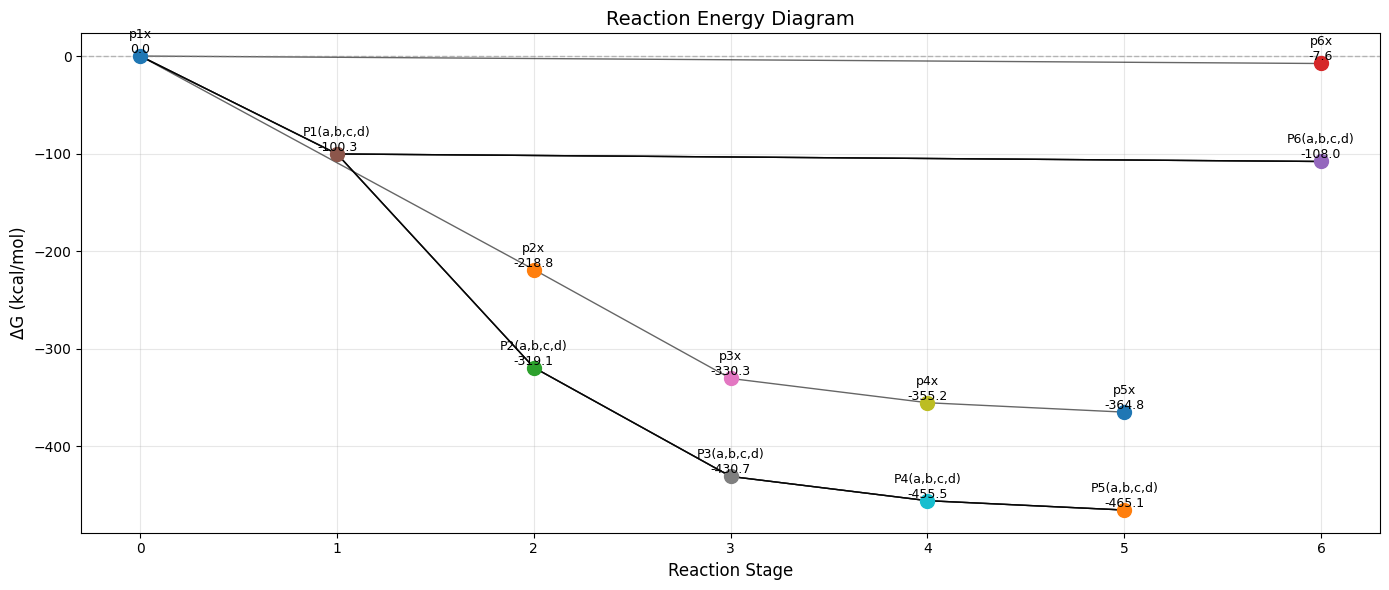

In [57]:
edges = [
    # backbone
    ("p1x", "p2x"), ("p2x", "p3x"), ("p3x", "p4x"), ("p4x", "p5x"),
    ("p1x", "p6x"),

    # branch A
    ("p1x", "p1a"), ("p1a", "p2a"), ("p2a", "p3a"),
    ("p3a", "p4a"), ("p4a", "p5a"), ("p1a", "p6a"),

    # branch B
    ("p1x", "p1b"), ("p1b", "p2b"), ("p2b", "p3b"),
    ("p3b", "p4b"), ("p4b", "p5b"), ("p1b", "p6b"),

    # branch C
    ("p1x", "p1c"), ("p1c", "p2c"), ("p2c", "p3c"),
    ("p3c", "p4c"), ("p4c", "p5c"), ("p1c", "p6c"),

    # branch D
    ("p1x", "p1d"), ("p1d", "p2d"), ("p2d", "p3d"),
    ("p3d", "p4d"), ("p4d", "p5d"), ("p1d", "p6d"),
]

reaction_rules = {
    ("p1", "p2"): {"add": {"OH": 4}, "remove": {"H2O": 3}},
    ("p2", "p3"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p3", "p4"): {"remove": {"CO2": 1}},
    ("p4", "p5"): {"add": {"OH": 1}, "remove": {"HCO3": 1}},
    ("p1", "p6"): {"add": {"OH": 1}, "remove": {"H2O": 1, "OMe": 1}},
}

step_corrections = {
    ("p1x", "p1a"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1b"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1c"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
    ("p1x", "p1d"): {"add": {"OH": 2}, "remove": {"H2O": 1}},
}

def base(name):
    return re.match(r"[a-z]+\d+", name).group()


def build_reaction_graph(edges, reaction_rules, step_corrections):
    G = nx.DiGraph()
    for u, v in edges:
        rule = None
        if (u, v) in step_corrections:
            rule = step_corrections[(u, v)]
        else:
            key = (base(u), base(v))
            if key in reaction_rules:
                rule = reaction_rules[key]
        G.add_edge(u, v, rxn=rule)
    return G

G = build_reaction_graph(
    edges=edges,
    reaction_rules=reaction_rules,
    step_corrections=step_corrections,
)

plot_energy_graph_auto_stage_spacing(
    df=df,
    G=G,
    start_node="p1x",
)
